# BizFlow360 — KNBS MSME Dataset Inspection

## Project
BizFlow360 – MSME Financial Distress Prediction

## Role
Data Engineering & Exploratory Data Analysis (EDA)

## Dataset
KNBS MSME Survey 2016

## Objective
To inspect, understand, and assess the KNBS MSME establishment
dataset before cleaning, transformation, and exploratory analysis.

## Data Handling Principle
The original raw dataset will remain unchanged.
All data preparation will be performed on working copies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
print("Current working directory:")
print(os.getcwd())

Current working directory:
/home/mikel/BizFlow360/data_eda/notebooks


In [3]:
file_path = "../raw/knbs/MSME_final_establishments_dataset_with_trainings.dta"

df = pd.read_stata(file_path)

print("Dataset loaded successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../raw/knbs/MSME_final_establishments_dataset_with_trainings.dta'

In [ ]:
df = pd.read_stata("../raw/knbs/MSME_final_establishments_dataset_with_trainings.dta")

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 24164
Number of columns: 479


In [ ]:
df.head()

,key3,key2,ls_index,a_41,county11,eb01_1,eb01_2,eb03,eb04,eb05,...,ee16,ee17,ee18,_merge_emp1,_merge_emp,total_employees,total_emply,total_males_emp,total_females_emp,tot_exp
0,uuid:00032f39-4a32-435a-9940-dd5749d8b41e/surv...,uuid:00032f39-4a32-435a-9940-dd5749d8b41e,1,603003174,MIGORI,"R - Arts, entertainment and recreation",95 - Repair of computers and personal and hous...,Commercial premises,Appropriate,"If rented, eviction by owner/landlord",...,NaN,Technical/Advice,N / A,matched (3),matched (3),3,Micro (1-9 employees),3,0,9630.0
1,uuid:0003d4b6-0c8d-4510-b4d1-c907d3a4e68a/surv...,uuid:0003d4b6-0c8d-4510-b4d1-c907d3a4e68a,1,205007266,KIAMBU,G - Wholesale and retail trade; repair of mot...,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Very Appropriate,"If rented, eviction by owner/landlord",...,NaN,N / A,NaN,matched (3),matched (3),2,Micro (1-9 employees),2,0,172600.0
2,uuid:000906d3-ef64-4b53-a85f-0a666797110a/surv...,uuid:000906d3-ef64-4b53-a85f-0a666797110a,1,205013250,KIAMBU,G - Wholesale and retail trade; repair of mot...,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,None,...,NaN,Marketing,N / A,matched (3),matched (3),2,Micro (1-9 employees),1,1,51560.0
3,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a/surv...,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,1,601004671,SIAYA,G - Wholesale and retail trade; repair of mot...,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,None,...,NaN,N / A,NaN,matched (3),matched (3),1,Micro (1-9 employees),1,0,10347.0
4,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a/surv...,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,2,601004671,SIAYA,G - Wholesale and retail trade; repair of mot...,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,None,...,NaN,Management,N / A,matched (3),matched (3),1,Micro (1-9 employees),1,0,10347.0


In [ ]:
print("Total variables:", len(df.columns))

for i, column in enumerate(df.columns, start=1):
    print(i, column)

Total variables: 479
1 key3
2 key2
3 ls_index
4 a_41
5 county11
6 eb01_1
7 eb01_2
8 eb03
9 eb04
10 eb05
11 eb06
12 eb07
13 eb08
14 eb09
15 eb10
16 eb11
17 eb12
18 eb13
19 eb14_1
20 eb14_2
21 eb15
22 eb16_1
23 eb17
24 eb18_1
25 eb18_2
26 eb19
27 ec01
28 ec02
29 hhe_fulltime
30 ec03
31 ec04
32 ec05
33 ec06
34 ec07
35 ec08
36 ec09
37 ec10
38 ec11
39 ec12
40 hhe_unpaid_fam
41 ec13
42 ec14
43 ec15
44 ec16
45 ec17
46 ec18
47 ec19
48 ec20
49 ec21
50 ec22
51 hhe_apprentice
52 ec23
53 ec24
54 ec25
55 ec26
56 ec27
57 ec28
58 ec29
59 ec30
60 ec31
61 ec32
62 hhe_parttime
63 ec33
64 ec34
65 ec35
66 ec36
67 ec37
68 ec38
69 ec39
70 ec40
71 ec41
72 ec42
73 ec43
74 ec44
75 ec45
76 ec46
77 ec47
78 ec48
79 ec49
80 ec50
81 ec51
82 ec52
83 hhe_casual
84 ec53
85 ec54
86 ec55
87 ec56
88 ec57
89 ec58
90 ec59
91 ec60
92 ec61
93 ec62
94 ec63
95 ec64
96 ec65
97 ec65_1
98 ec65_2
99 ec65_3
100 ec65_4
101 ec66
102 ec66_1
103 hhe_schoolhalf
104 ec67
105 ec68
106 ec69
107 ec70
108 ec71
109 ec72
110 ec73
111 ec74
112 

In [ ]:
# Search for variables related to finance, income, sales, costs, loans and business performance

keywords = [
    "income",
    "revenue",
    "sales",
    "profit",
    "expense",
    "expenditure",
    "cost",
    "loan",
    "credit",
    "debt",
    "finance",
    "financ",
    "capital",
    "asset",
    "investment",
    "bank",
    "saving"
]

financial_vars = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in keywords)
]

print("Number of potentially relevant variables:", len(financial_vars))

for i, col in enumerate(financial_vars, start=1):
    print(i, col)

Number of potentially relevant variables: 0


In [ ]:
employment_vars = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in [
        "emp",
        "employee",
        "employ",
        "worker",
        "staff",
        "wage",
        "salary"
    ])
]

print("Number of employment-related variables:", len(employment_vars))

for i, col in enumerate(employment_vars, start=1):
    print(i, col)

Number of employment-related variables: 7
1 emp_trained_i
2 _merge_emp1
3 _merge_emp
4 total_employees
5 total_emply
6 total_males_emp
7 total_females_emp


In [ ]:
print("Total rows:", len(df))
print("Unique key2:", df["key2"].nunique())
print("Duplicate key2 rows:", df["key2"].duplicated().sum())

Total rows: 24164
Unique key2: 20596
Duplicate key2 rows: 3568


In [ ]:
duplicate_key2 = df[df["key2"].duplicated(keep=False)].sort_values("key2")

duplicate_key2[[
    "key2",
    "county11",
    "eb03",
    "total_emply",
    "total_males_emp",
    "total_females_emp"
]].head(20)

,key2,county11,eb03,total_emply,total_males_emp,total_females_emp
3,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,SIAYA,Commercial premises,Micro (1-9 employees),1,0
4,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,SIAYA,Commercial premises,Micro (1-9 employees),1,0
9,uuid:001dd411-8d93-4fa4-baa1-a438135f6796,KITUI,Commercial premises,Micro (1-9 employees),1,3
10,uuid:001dd411-8d93-4fa4-baa1-a438135f6796,KITUI,Commercial premises,Micro (1-9 employees),1,3
16,uuid:0031938f-d0f9-4bcc-bffb-32921233f548,SAMBURU,Commercial premises,Micro (1-9 employees),7,2
17,uuid:0031938f-d0f9-4bcc-bffb-32921233f548,SAMBURU,Commercial premises,Micro (1-9 employees),7,2
18,uuid:0031938f-d0f9-4bcc-bffb-32921233f548,SAMBURU,Commercial premises,Micro (1-9 employees),7,2
21,uuid:003b7f90-9740-4f56-bad4-0e96798e5d41,MAKUENI,Commercial premises,Micro (1-9 employees),0,1
22,uuid:003b7f90-9740-4f56-bad4-0e96798e5d41,MAKUENI,Commercial premises,Micro (1-9 employees),0,1
25,uuid:0041b740-0423-457c-9366-bf1df8965d1e,MAKUENI,Commercial premises,Micro (1-9 employees),0,1


In [ ]:
# Get all variable names directly from the loaded dataset

variables = df.columns.tolist()

print("Number of variables:", len(variables))

for i, variable in enumerate(variables, start=1):
    print(f"{i}. {variable}")

Number of variables: 479
1. key3
2. key2
3. ls_index
4. a_41
5. county11
6. eb01_1
7. eb01_2
8. eb03
9. eb04
10. eb05
11. eb06
12. eb07
13. eb08
14. eb09
15. eb10
16. eb11
17. eb12
18. eb13
19. eb14_1
20. eb14_2
21. eb15
22. eb16_1
23. eb17
24. eb18_1
25. eb18_2
26. eb19
27. ec01
28. ec02
29. hhe_fulltime
30. ec03
31. ec04
32. ec05
33. ec06
34. ec07
35. ec08
36. ec09
37. ec10
38. ec11
39. ec12
40. hhe_unpaid_fam
41. ec13
42. ec14
43. ec15
44. ec16
45. ec17
46. ec18
47. ec19
48. ec20
49. ec21
50. ec22
51. hhe_apprentice
52. ec23
53. ec24
54. ec25
55. ec26
56. ec27
57. ec28
58. ec29
59. ec30
60. ec31
61. ec32
62. hhe_parttime
63. ec33
64. ec34
65. ec35
66. ec36
67. ec37
68. ec38
69. ec39
70. ec40
71. ec41
72. ec42
73. ec43
74. ec44
75. ec45
76. ec46
77. ec47
78. ec48
79. ec49
80. ec50
81. ec51
82. ec52
83. hhe_casual
84. ec53
85. ec54
86. ec55
87. ec56
88. ec57
89. ec58
90. ec59
91. ec60
92. ec61
93. ec62
94. ec63
95. ec64
96. ec65
97. ec65_1
98. ec65_2
99. ec65_3
100. ec65_4
101. ec66
1

## Dataset Overview

The KNBS Small and Medium Enterprises (MSME) Survey 2016
dataset contains 24,164 establishment-level observations
and 479 variables.

The dataset is stored in Stata (.dta) format and was obtained
from the Kenya National Data Archive (KeNADA).

The raw dataset is preserved without modification.

### Initial observations

- Number of observations: 24,164
- Number of variables: 479
- Dataset format: Stata (.dta)
- Main identifier examined: key2
- Unique key2 values: 20,596
- Repeated key2 observations: 3,568

Further investigation is required to determine the reason for
repeated key2 values before any duplicate records are removed.

In [ ]:
print("Dataset shape:", df.shape)
print("Unique key2 values:", df["key2"].nunique())
print("Repeated key2 observations:", df["key2"].duplicated().sum())

Dataset shape: (24164, 479)
Unique key2 values: 20596
Repeated key2 observations: 3568


In [ ]:
# Preliminary financial and business-health variables
selected_vars = [
    "county11",
    "eb01_2",
    "eb03",
    "eb04",
    "eb05",
    "eb16_1",
    "ec01",
    "ec02",
    "eg03_1",
    "eg04_1",
    "eg05_1",
    "eg06_1",
    "eg07_1",
    "eg08_1",
    "eg09_1",
    "eg10_1",
    "eg22_1",
    "eh01_1",
    "eh02_1",
    "eh03_1",
    "eh04_1",
    "eh09",
    "eh15_1",
    "eh22_1"
]

# Keep only variables that actually exist in our dataset
available_vars = [v for v in selected_vars if v in df.columns]

print("Available variables:", len(available_vars))
print("\nVariables found:")
for v in available_vars:
    print(v)

Available variables: 24

Variables found:
county11
eb01_2
eb03
eb04
eb05
eb16_1
ec01
ec02
eg03_1
eg04_1
eg05_1
eg06_1
eg07_1
eg08_1
eg09_1
eg10_1
eg22_1
eh01_1
eh02_1
eh03_1
eh04_1
eh09
eh15_1
eh22_1


## Preliminary Financial Distress Feature Set

The following 24 variables were identified from the KNBS MSME 2016
data dictionary as potentially relevant to business characteristics,
employment, operating costs, revenue, income, turnover and financial
conditions.

The variables will be profiled before any cleaning or transformation.

In [ ]:
selected_df = df[available_vars].copy()

print("Rows:", selected_df.shape[0])
print("Columns:", selected_df.shape[1])

Rows: 24164
Columns: 24


In [ ]:
selected_df.dtypes

county11    category
eb01_2      category
eb03        category
eb04        category
eb05        category
eb16_1      category
ec01           int16
ec02           int16
eg03_1       float64
eg04_1       float64
eg05_1       float64
eg06_1       float64
eg07_1       float64
eg08_1       float64
eg09_1       float64
eg10_1       float64
eg22_1       float64
eh01_1       float64
eh02_1       float64
eh03_1       float64
eh04_1       float64
eh09        category
eh15_1       float64
eh22_1       float64
dtype: object

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": selected_df.isna().sum(),
    "missing_percentage": selected_df.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
eh22_1,22257,92.108095
eh03_1,5880,24.333720
eh02_1,5462,22.603874
eh04_1,2320,9.601059
eh01_1,876,3.625228
eh15_1,871,3.604536
eg10_1,600,2.483033
eg09_1,571,2.363019
eb05,416,1.721569
eb04,416,1.721569


In [ ]:
selected_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ec01,24164.0,1.288115e+00,4.051566e+01,0.00,0.0,1.00,1.0,6.000000e+03
ec02,24164.0,8.841665e-01,1.051736e+01,0.00,0.0,0.00,1.0,1.500000e+03
eg03_1,23973.0,2.948643e+03,3.893456e+04,-74.25,0.0,682.50,1560.0,5.250000e+06
eg04_1,23813.0,6.640136e+02,1.202716e+04,-74.25,0.0,0.00,0.0,1.436775e+06
eg05_1,23973.0,3.276237e+03,1.277608e+05,-74.25,0.0,146.25,450.0,1.033500e+07
eg06_1,24004.0,4.538614e+02,7.729239e+03,-74.25,0.0,17.85,126.0,6.000000e+05
eg07_1,23828.0,4.407768e+02,3.445230e+03,-74.25,0.0,78.00,351.0,2.945471e+05
eg08_1,23944.0,3.609777e+02,6.785437e+03,-74.25,0.0,0.00,0.0,4.295811e+05
eg09_1,23593.0,1.178576e+03,2.493458e+04,-74.25,0.0,0.00,0.0,1.500000e+06
eg10_1,23564.0,7.105741e+03,2.731601e+05,-74.25,0.0,0.00,0.0,1.953900e+07


In [ ]:
for col in ["county11", "eb01_2", "eb03", "eb04", "eb05"]:
    print(f"\n===== {col} =====")
    print(selected_df[col].value_counts(dropna=False).head(15))


===== county11 =====
county11
NAIROBI            1546
MAKUENI             928
UASIN GISHU         924
NYERI               656
SAMBURU             645
KILIFI              641
MERU                631
NAKURU              622
KAJIADO             611
KIAMBU              607
NYANDARUA           594
BARINGO             589
ELGEYO MARAKWET     573
NYAMIRA             555
THARAKA             551
Name: count, dtype: int64

===== eb01_2 =====
eb01_2
47 - Retail trade, except of motor vehicles and motorcycles                         11349
56 - Food and beverage service activities                                            2208
96 - Other personal service activities                                               1255
85 - Education                                                                       1163
64 - Financial service activities, except insurance and pension funding              1066
14 - Manufacture of wearing apparel                                                   931
10 - Manufacture

In [ ]:
analysis_df = df[["key2"] + available_vars].copy()

print("Rows:", analysis_df.shape[0])
print("Columns:", analysis_df.shape[1])
print("Unique businesses/keys:", analysis_df["key2"].nunique())

Rows: 24164
Columns: 25
Unique businesses/keys: 20596


In [ ]:
financial_numeric = [
    "eg03_1", "eg04_1", "eg05_1", "eg06_1",
    "eg07_1", "eg08_1", "eg09_1", "eg10_1",
    "eg22_1", "eh01_1", "eh02_1", "eh03_1",
    "eh04_1", "eh15_1", "eh22_1"
]

for col in financial_numeric:
    print(f"\n===== {col} =====")
    print(
        selected_df[col]
        .value_counts(dropna=False)
        .head(10)
    )


===== eg03_1 =====
eg03_1
0.0       6078
975.0     1009
585.0      851
1950.0     674
390.0      631
780.0      612
1170.0     562
900.0      561
1500.0     497
600.0      420
Name: count, dtype: int64

===== eg04_1 =====
eg04_1
 0.00       19011
 97.50        751
 150.00       384
 NaN          351
-19.11        306
 195.00        81
 78.00         60
 300.00        56
 17.85         54
 1500.00       50
Name: count, dtype: int64

===== eg05_1 =====
eg05_1
0.0      5802
97.5     1535
195.0    1069
390.0     753
300.0     707
150.0     697
58.5      681
292.5     593
600.0     567
39.0      483
Name: count, dtype: int64

===== eg06_1 =====
eg06_1
0.0      11118
97.5       778
58.5       708
39.0       635
150.0      468
60.0       386
90.0       378
19.5       363
195.0      352
117.0      302
Name: count, dtype: int64

===== eg07_1 =====
eg07_1
0.0      9348
585.0    1090
292.5     964
195.0     886
97.5      846
300.0     629
900.0     611
450.0     568
150.0     561
390.0     548
N

In [ ]:
for col in financial_numeric:
    count = (selected_df[col] == -74.25).sum()
    if count > 0:
        print(f"{col}: {count} records contain -74.25")

eg03_1: 1 records contain -74.25
eg04_1: 3 records contain -74.25
eg05_1: 1 records contain -74.25
eg06_1: 1 records contain -74.25
eg07_1: 2 records contain -74.25
eg08_1: 1 records contain -74.25
eg09_1: 3 records contain -74.25
eg10_1: 2 records contain -74.25
eg22_1: 1 records contain -74.25
eh01_1: 4 records contain -74.25
eh15_1: 6 records contain -74.25


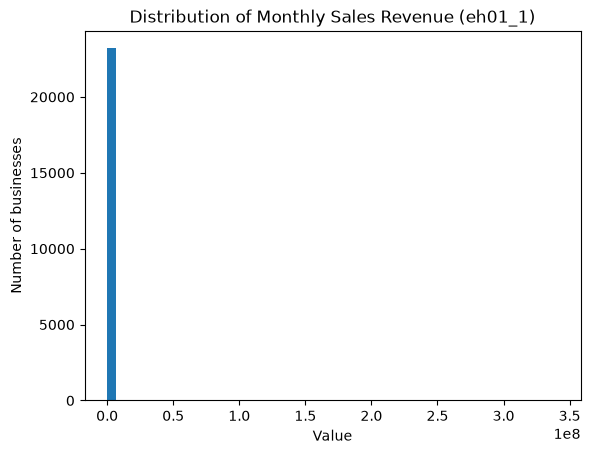

In [ ]:
import matplotlib.pyplot as plt

selected_df["eh01_1"].plot(kind="hist", bins=50)

plt.title("Distribution of Monthly Sales Revenue (eh01_1)")
plt.xlabel("Value")
plt.ylabel("Number of businesses")
plt.show()

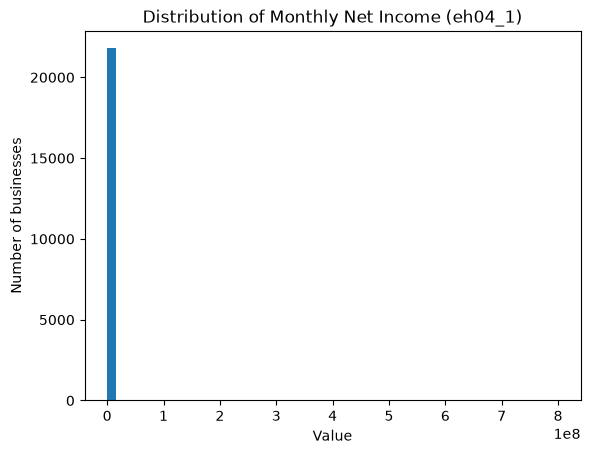

In [ ]:
selected_df["eh04_1"].plot(kind="hist", bins=50)

plt.title("Distribution of Monthly Net Income (eh04_1)")
plt.xlabel("Value")
plt.ylabel("Number of businesses")
plt.show()

In [ ]:
financial_numeric = [
    "eg03_1", "eg04_1", "eg05_1", "eg06_1",
    "eg07_1", "eg08_1", "eg09_1", "eg10_1",
    "eg22_1", "eh01_1", "eh02_1", "eh03_1",
    "eh04_1", "eh15_1", "eh22_1"
]

for col in financial_numeric:
    count = (selected_df[col] == -74.25).sum()
    if count > 0:
        print(f"{col}: {count} records contain -74.25")

eg03_1: 1 records contain -74.25
eg04_1: 3 records contain -74.25
eg05_1: 1 records contain -74.25
eg06_1: 1 records contain -74.25
eg07_1: 2 records contain -74.25
eg08_1: 1 records contain -74.25
eg09_1: 3 records contain -74.25
eg10_1: 2 records contain -74.25
eg22_1: 1 records contain -74.25
eh01_1: 4 records contain -74.25
eh15_1: 6 records contain -74.25


In [ ]:
for col in financial_numeric:
    print(f"\n===== {col} =====")
    print(
        selected_df[col]
        .value_counts(dropna=False)
        .head(10)
    )


===== eg03_1 =====
eg03_1
0.0       6078
975.0     1009
585.0      851
1950.0     674
390.0      631
780.0      612
1170.0     562
900.0      561
1500.0     497
600.0      420
Name: count, dtype: int64

===== eg04_1 =====
eg04_1
 0.00       19011
 97.50        751
 150.00       384
 NaN          351
-19.11        306
 195.00        81
 78.00         60
 300.00        56
 17.85         54
 1500.00       50
Name: count, dtype: int64

===== eg05_1 =====
eg05_1
0.0      5802
97.5     1535
195.0    1069
390.0     753
300.0     707
150.0     697
58.5      681
292.5     593
600.0     567
39.0      483
Name: count, dtype: int64

===== eg06_1 =====
eg06_1
0.0      11118
97.5       778
58.5       708
39.0       635
150.0      468
60.0       386
90.0       378
19.5       363
195.0      352
117.0      302
Name: count, dtype: int64

===== eg07_1 =====
eg07_1
0.0      9348
585.0    1090
292.5     964
195.0     886
97.5      846
300.0     629
900.0     611
450.0     568
150.0     561
390.0     548
N

In [ ]:
for col in financial_numeric:
    negative_count = (selected_df[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

eg03_1: 258 negative values
eg04_1: 451 negative values
eg05_1: 260 negative values
eg06_1: 232 negative values
eg07_1: 429 negative values
eg08_1: 231 negative values
eg09_1: 738 negative values
eg10_1: 801 negative values
eg22_1: 346 negative values
eh01_1: 1398 negative values
eh02_1: 0 negative values
eh03_1: 0 negative values
eh04_1: 0 negative values
eh15_1: 1313 negative values
eh22_1: 0 negative values


In [ ]:
categorical_vars = [
    "county11",
    "eb01_2",
    "eb03",
    "eb04",
    "eb05",
    "eb16_1",
    "eh09"
]

for col in categorical_vars:
    print(f"\n===== {col} =====")
    print(selected_df[col].value_counts(dropna=False).head(20))


===== county11 =====
county11
NAIROBI            1546
MAKUENI             928
UASIN GISHU         924
NYERI               656
SAMBURU             645
KILIFI              641
MERU                631
NAKURU              622
KAJIADO             611
KIAMBU              607
NYANDARUA           594
BARINGO             589
ELGEYO MARAKWET     573
NYAMIRA             555
THARAKA             551
BUSIA               548
KISUMU              537
BUNGOMA             537
TAITA TAVETA        521
KITUI               495
Name: count, dtype: int64

===== eb01_2 =====
eb01_2
47 - Retail trade, except of motor vehicles and motorcycles                                                                             11349
56 - Food and beverage service activities                                                                                                2208
96 - Other personal service activities                                                                                                   1255
85 - Educa

In [ ]:
for col in financial_numeric:
    negatives = selected_df.loc[
        selected_df[col] < 0, col
    ].value_counts().sort_index()

    if len(negatives) > 0:
        print(f"\n===== {col} =====")
        print(negatives)


===== eg03_1 =====
eg03_1
-74.2500      1
-73.5000     11
-20.7900      2
-20.5800      9
-19.3050     51
-19.1100    141
-13.2300      2
-8.9100       1
-8.8200       3
-5.0490       4
-4.9980      12
-3.5343       5
-3.4986      16
Name: count, dtype: int64

===== eg04_1 =====
eg04_1
-74.2500      3
-73.5000     16
-20.7900      1
-20.5800     21
-19.3050     35
-19.1100    306
-13.2300      2
-8.9100       1
-8.8200      14
-5.0490       1
-4.9980      21
-3.5343       5
-3.4986      25
Name: count, dtype: int64

===== eg05_1 =====
eg05_1
-74.2500      1
-73.5000     12
-20.7900      1
-20.5800     19
-19.3050     27
-19.1100    160
-13.2300      1
-8.9100       1
-8.8200       6
-5.0490       3
-4.9980      11
-3.5343       3
-3.4986      15
Name: count, dtype: int64

===== eg06_1 =====
eg06_1
-74.2500      1
-73.5000      9
-20.7900      1
-20.5800     15
-19.3050     28
-19.1100    141
-13.2300      3
-8.9100       1
-8.8200       9
-5.0490       1
-4.9980      12
-3.5343       

In [ ]:
print(selected_df["eh09"].value_counts(dropna=False))

eh09
Normal                                 12006
Bad                                     8550
Good                                    3370
N/A (business younger than 1 month)      238
Name: count, dtype: int64


In [ ]:
print(selected_df["eh09"].dtype)

category


In [ ]:
print(
    selected_df["eb16_1"]
    .value_counts(dropna=False)
)

eb16_1
Owner/Co-Owner               22268
Board / Committee members     1021
Managers                       761
Other (Specify)                114
Name: count, dtype: int64


In [ ]:
for col in ["eh01_1", "eh04_1", "eh15_1", "eh22_1"]:
    print(f"\n===== {col} =====")
    print("Missing:", selected_df[col].isna().sum())
    print("Zero:", (selected_df[col] == 0).sum())
    print("Negative:", (selected_df[col] < 0).sum())
    print("Positive:", (selected_df[col] > 0).sum())


===== eh01_1 =====
Missing: 876
Zero: 674
Negative: 1398
Positive: 21216

===== eh04_1 =====
Missing: 2320
Zero: 497
Negative: 0
Positive: 21347

===== eh15_1 =====
Missing: 871
Zero: 386
Negative: 1313
Positive: 21594

===== eh22_1 =====
Missing: 22257
Zero: 0
Negative: 0
Positive: 1907


In [ ]:
# Create a candidate dataset for financial distress analysis

candidate_vars = [
    "key2",
    "county11",
    "eb01_2",
    "eb03",
    "eb04",
    "eb05",
    "eb16_1",
    "ec01",
    "ec02",
    "eg03_1",
    "eg04_1",
    "eg05_1",
    "eg06_1",
    "eg07_1",
    "eg08_1",
    "eg09_1",
    "eg10_1",
    "eg22_1",
    "eh01_1",
    "eh02_1",
    "eh03_1",
    "eh04_1",
    "eh09",
    "eh15_1",
    "eh22_1"
]

analysis_df = df[candidate_vars].copy()

print("Analysis dataset shape:", analysis_df.shape)
print("\nVariables:")
print(analysis_df.columns.tolist())

Analysis dataset shape: (24164, 25)

Variables:
['key2', 'county11', 'eb01_2', 'eb03', 'eb04', 'eb05', 'eb16_1', 'ec01', 'ec02', 'eg03_1', 'eg04_1', 'eg05_1', 'eg06_1', 'eg07_1', 'eg08_1', 'eg09_1', 'eg10_1', 'eg22_1', 'eh01_1', 'eh02_1', 'eh03_1', 'eh04_1', 'eh09', 'eh15_1', 'eh22_1']


In [ ]:
variable_dictionary = {
    "county11": "County",
    "eb01_2": "ISIC Division",
    "eb03": "Business location",
    "eb04": "Site appropriateness for getting customers",
    "eb05": "Biggest tenancy risk",
    "eb16_1": "Main decision maker",
    "ec01": "Number of male working owners",
    "ec02": "Number of female working owners",
    "eg03_1": "Monthly rent expenditure",
    "eg04_1": "Monthly NSSF/Health Insurance expenditure",
    "eg05_1": "Monthly electricity expenditure",
    "eg06_1": "Monthly water expenditure",
    "eg07_1": "Monthly telephone expenditure",
    "eg08_1": "Monthly internet expenditure",
    "eg09_1": "Monthly business insurance expenditure",
    "eg10_1": "Monthly credit expenditure",
    "eg22_1": "Monthly social responsibility expenditure",
    "eh01_1": "Revenue from total sales last month",
    "eh02_1": "Beginning stock value",
    "eh03_1": "End-of-month stock value",
    "eh04_1": "Monthly net income",
    "eh09": "Business performance in the last month",
    "eh15_1": "Normal monthly revenue",
    "eh22_1": "Total turnover in 2015"
}

dictionary_df = pd.DataFrame(
    list(variable_dictionary.items()),
    columns=["variable", "description"]
)

dictionary_df

,variable,description
0,county11,County
1,eb01_2,ISIC Division
2,eb03,Business location
3,eb04,Site appropriateness for getting customers
4,eb05,Biggest tenancy risk
5,eb16_1,Main decision maker
6,ec01,Number of male working owners
7,ec02,Number of female working owners
8,eg03_1,Monthly rent expenditure
9,eg04_1,Monthly NSSF/Health Insurance expenditure


In [ ]:
analysis_df["eh09"].value_counts()

eh09
Normal                                 12006
Bad                                     8550
Good                                    3370
N/A (business younger than 1 month)      238
Name: count, dtype: int64

In [ ]:
# Financial performance by reported business performance

financial_vars = [
    "eh01_1",   # Sales revenue
    "eh02_1",   # Beginning stock
    "eh03_1",   # Ending stock
    "eh04_1",   # Net income
    "eh15_1",   # Normal revenue
    "eh22_1"    # 2015 turnover
]

performance_summary = analysis_df.groupby("eh09")[financial_vars].agg(
    ["count", "mean", "median"]
)

performance_summary

eh01_1                         eh02_1  \
                                     count           mean   median  count   
eh09                                                                        
N/A (business younger than 1 month)    229   10632.812306      0.0    206   
Good                                  3252  612340.898923  15600.0   2769   
Normal                               11543  187380.742058  11700.0   9134   
Bad                                   8264  110785.663160   7500.0   6593   

                                                            eh03_1  \
                                              mean   median  count   
eh09                                                                 
N/A (business younger than 1 month)    6443.689320      0.0    196   
Good                                 619147.954496  25000.0   2706   
Normal                               783686.066674  15000.0   8941   
Bad                                  345740.752161  15000.0   6441   

                                                            eh04_1  \
                                              mean   median  count   
eh09                                                                 
N/A (business younger than 1 month)    6586.734694      0.0    207   
Good                                 707965.563562  11750.0   3045   
Normal                               408903.068113   8000.0  10895   
Bad                                  315124.891942  10000.0   7697   

                                                            eh15_1  \
                                              mean   median  count   
eh09                                                                 
N/A (business younger than 1 month)   47701.932367      0.0    224   
Good                                 739912.776026  30000.0   3240   
Normal                               374952.608077  20000.0  11566   
Bad                                  915443.780044  14000.0   8263   

                                                            eh22_1  \
                                              mean   median  count   
eh09                                                                 
N/A (business younger than 1 month)   59843.611444      0.0      0   
Good                                 527657.925143  11700.0    380   
Normal                               145466.801871   9000.0    891   
Bad                                  336157.404312   6000.0    636   

                                                             
                                             mean    median  
eh09                                                         
N/A (business younger than 1 month)           NaN       NaN  
Good                                 2.905987e+07  500000.0  
Normal                               9.161990e+06  300000.0  
Bad                                  6.646293e+06  200000.0

In [ ]:
expense_vars = [
    "eg03_1",
    "eg04_1",
    "eg05_1",
    "eg06_1",
    "eg07_1",
    "eg08_1",
    "eg09_1",
    "eg10_1",
    "eg22_1"
]

analysis_df["total_selected_expenses"] = analysis_df[expense_vars].sum(
    axis=1,
    skipna=True
)

analysis_df[[
    "total_selected_expenses",
    "eh01_1",
    "eh04_1",
    "eh15_1"
]].describe()

,total_selected_expenses,eh01_1,eh04_1,eh15_1
count,2.416400e+04,2.328800e+04,2.184400e+04,2.329300e+04
mean,1.745126e+04,2.178047e+05,6.131747e+05,2.654512e+05
std,3.225682e+05,4.145922e+06,1.684836e+07,6.353415e+06
min,-6.682500e+02,-7.425000e+01,0.000000e+00,-7.425000e+01
25%,6.600000e+02,3.600000e+03,8.000000e+03,2.925000e+03
50%,1.575000e+03,9.750000e+03,1.900000e+04,7.800000e+03
75%,3.705000e+03,2.940000e+04,4.500000e+04,2.340000e+04
max,1.954421e+07,3.412500e+08,8.000000e+08,3.412500e+08


In [ ]:
analysis_df.groupby("eh09")["eh04_1"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
eh09,,,,,
N/A (business younger than 1 month),207,47701.932367,0.0,0.0,3200000.0
Good,3045,739912.776026,30000.0,0.0,450000000.0
Normal,10895,374952.608077,20000.0,0.0,300000000.0
Bad,7697,915443.780044,14000.0,0.0,800000000.0


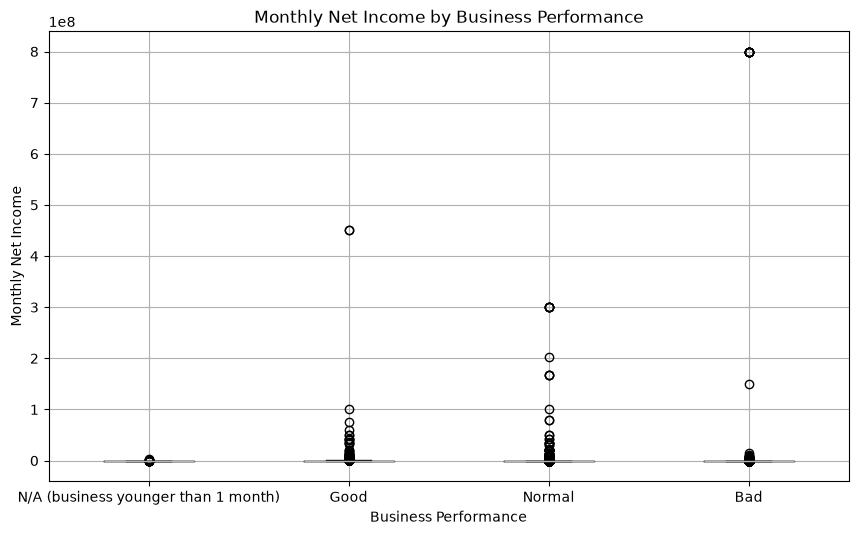

In [ ]:
import matplotlib.pyplot as plt

analysis_df.boxplot(
    column="eh04_1",
    by="eh09",
    figsize=(10, 6)
)

plt.title("Monthly Net Income by Business Performance")
plt.suptitle("")
plt.xlabel("Business Performance")
plt.ylabel("Monthly Net Income")
plt.show()

In [ ]:
duplicate_counts = analysis_df["key2"].value_counts()

print("Businesses with 1 row:",
      (duplicate_counts == 1).sum())

print("Businesses with 2 rows:",
      (duplicate_counts == 2).sum())

print("Businesses with 3 rows:",
      (duplicate_counts == 3).sum())

print("Businesses with more than 3 rows:",
      (duplicate_counts > 3).sum())

Businesses with 1 row: 17775
Businesses with 2 rows: 2511
Businesses with 3 rows: 197
Businesses with more than 3 rows: 113


In [ ]:
example_key = duplicate_counts[duplicate_counts > 1].index[0]

analysis_df[
    analysis_df["key2"] == example_key
].T

,7078,7079,7080,7081,7082,7083,7084,7085,7086,7087,...,7168,7169,7170,7171,7172,7173,7174,7175,7176,7177
key2,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,...,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a,uuid:4ab06ba5-3aee-4ce6-8962-270d5f0c9b7a
county11,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,...,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR,WAJIR
eb01_2,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,...,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities,86 - Human health activities
eb03,Open market,Open market,Open market,Open market,Open market,Open market,Open market,Open market,Open market,Open market,...,Open market,Open market,Open market,Open market,Open market,Open market,Open market,Open market,Open market,Open market
eb04,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,...,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate,Very Appropriate
eb05,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,...,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government,Eviction by County Government
eb16_1,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,...,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner,Owner/Co-Owner
ec01,20,20,20,20,20,20,20,20,20,20,...,20,20,20,20,20,20,20,20,20,20
ec02,50,50,50,50,50,50,50,50,50,50,...,50,50,50,50,50,50,50,50,50,50
eg03_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Check for completely identical rows in our analysis dataset

duplicate_rows = analysis_df.duplicated(keep=False)

print("Total duplicate rows:", duplicate_rows.sum())
print("Percentage duplicated:",
      round(duplicate_rows.mean() * 100, 2), "%")

Total duplicate rows: 6389
Percentage duplicated: 26.44 %


In [ ]:
# Remove the key2 identifier temporarily and check whether
# the remaining information is identical

data_columns = [col for col in analysis_df.columns if col != "key2"]

duplicate_business_records = analysis_df.duplicated(
    subset=data_columns,
    keep=False
)

print("Rows with identical business information:",
      duplicate_business_records.sum())

Rows with identical business information: 6391


In [ ]:
# Number of unique records before and after removing exact duplicates

print("Original rows:", len(analysis_df))

analysis_no_exact_duplicates = analysis_df.drop_duplicates()

print("After removing exact duplicates:",
      len(analysis_no_exact_duplicates))

print("Rows removed:",
      len(analysis_df) - len(analysis_no_exact_duplicates))

Original rows: 24164
After removing exact duplicates: 20596
Rows removed: 3568


In [ ]:
# Remove exact duplicate records
analysis_clean = analysis_df.drop_duplicates().copy()

print("Clean dataset shape:", analysis_clean.shape)
print("Unique businesses:", analysis_clean["key2"].nunique())
print("Remaining duplicate key2 values:",
      analysis_clean["key2"].duplicated().sum())

Clean dataset shape: (20596, 26)
Unique businesses: 20596
Remaining duplicate key2 values: 0


In [ ]:
analysis_clean.info()

<class 'pandas.DataFrame'>
Index: 20596 entries, 0 to 24163
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   key2                     20596 non-null  str     
 1   county11                 20596 non-null  category
 2   eb01_2                   20596 non-null  category
 3   eb03                     20596 non-null  category
 4   eb04                     20238 non-null  category
 5   eb05                     20238 non-null  category
 6   eb16_1                   20596 non-null  category
 7   ec01                     20596 non-null  int16   
 8   ec02                     20596 non-null  int16   
 9   eg03_1                   20435 non-null  float64 
 10  eg04_1                   20317 non-null  float64 
 11  eg05_1                   20435 non-null  float64 
 12  eg06_1                   20470 non-null  float64 
 13  eg07_1                   20357 non-null  float64 
 14  eg08_1                

In [ ]:
analysis_clean.head()

,key2,county11,eb01_2,eb03,eb04,eb05,eb16_1,ec01,ec02,eg03_1,...,eg10_1,eg22_1,eh01_1,eh02_1,eh03_1,eh04_1,eh09,eh15_1,eh22_1,total_selected_expenses
0,uuid:00032f39-4a32-435a-9940-dd5749d8b41e,MIGORI,95 - Repair of computers and personal and hous...,Commercial premises,Appropriate,"If rented, eviction by owner/landlord",Owner/Co-Owner,1,0,300.0,...,0.0,0.0,0.00,0.0,0.0,10000.0,Good,7500.00,NaN,570.00
1,uuid:0003d4b6-0c8d-4510-b4d1-c907d3a4e68a,KIAMBU,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Very Appropriate,"If rented, eviction by owner/landlord",Owner/Co-Owner,1,0,1950.0,...,0.0,0.0,39000.00,NaN,NaN,50000.0,Bad,9750.00,NaN,2242.50
2,uuid:000906d3-ef64-4b53-a85f-0a666797110a,KIAMBU,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,None,Owner/Co-Owner,0,1,1950.0,...,0.0,0.0,6825.00,NaN,NaN,NaN,Normal,6825.00,NaN,2254.20
3,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,SIAYA,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,None,Owner/Co-Owner,1,0,0.0,...,0.0,0.0,2925.00,30000.0,50000.0,5000.0,Normal,2925.00,NaN,5.85
5,uuid:000e121d-274d-42a0-9262-5cb817591225,VIHIGA,"47 - Retail trade, except of motor vehicles an...",Residential with special outfit,Very Appropriate,None,Owner/Co-Owner,1,0,0.0,...,0.0,0.0,-19.11,3000.0,NaN,1000.0,N/A (business younger than 1 month),-19.11,NaN,0.00


In [ ]:
analysis_clean.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
key2,20596,20596,uuid:00032f39-4a32-435a-9940-dd5749d8b41e,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county11,20596,47,NAIROBI,1167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eb01_2,20596,76,"47 - Retail trade, except of motor vehicles an...",9812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eb03,20596,14,Commercial premises,14180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eb04,20238,5,Appropriate,9334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eb05,20238,6,None,10375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eb16_1,20596,4,Owner/Co-Owner,19318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ec01,20596.0,NaN,NaN,NaN,1.152408,43.845809,0.0,0.0,1.0,1.0,6000.0
ec02,20596.0,NaN,NaN,NaN,0.592494,10.773775,0.0,0.0,0.0,1.0,1500.0
eg03_1,20435.0,NaN,NaN,NaN,2618.308119,39918.832923,-74.25,0.0,642.6,1500.0,5250000.0


In [ ]:
output_path = "../processed/msme_analysis_clean.csv"

analysis_clean.to_csv(output_path, index=False)

print("✅ Clean analytical dataset saved successfully!")
print("Location:", output_path)

✅ Clean analytical dataset saved successfully!
Location: ../processed/msme_analysis_clean.csv


## 03. Data Quality Cleaning

This stage focuses on identifying and treating invalid values, missing values,
and other data-quality issues in the deduplicated MSME analytical dataset.

In [ ]:
# Load the deduplicated analytical dataset

clean_df = pd.read_csv("../processed/msme_analysis_clean.csv")

print("Dataset loaded successfully!")
print("Shape:", clean_df.shape)

Dataset loaded successfully!
Shape: (20596, 26)


In [ ]:
# Financial variables
financial_vars = [
    "eg03_1", "eg04_1", "eg05_1", "eg06_1",
    "eg07_1", "eg08_1", "eg09_1", "eg10_1",
    "eg22_1", "eh01_1", "eh02_1", "eh03_1",
    "eh04_1", "eh15_1", "eh22_1"
]

# Count -74.25 values
special_value_counts = {}

for col in financial_vars:
    if col in clean_df.columns:
        special_value_counts[col] = (clean_df[col] == -74.25).sum()

special_value_counts

{'eg03_1': np.int64(1),
 'eg04_1': np.int64(3),
 'eg05_1': np.int64(1),
 'eg06_1': np.int64(1),
 'eg07_1': np.int64(2),
 'eg08_1': np.int64(1),
 'eg09_1': np.int64(3),
 'eg10_1': np.int64(2),
 'eg22_1': np.int64(1),
 'eh01_1': np.int64(4),
 'eh02_1': np.int64(0),
 'eh03_1': np.int64(0),
 'eh04_1': np.int64(0),
 'eh15_1': np.int64(6),
 'eh22_1': np.int64(0)}

In [ ]:
# Replace the special invalid value -74.25 with NaN
for col in financial_vars:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].replace(-74.25, np.nan)

print("✅ Special value -74.25 converted to NaN.")

✅ Special value -74.25 converted to NaN.


In [ ]:
remaining_special_values = {}

for col in financial_vars:
    if col in clean_df.columns:
        count = (clean_df[col] == -74.25).sum()
        if count > 0:
            remaining_special_values[col] = count

print("Remaining -74.25 values:", remaining_special_values)

Remaining -74.25 values: {}


In [ ]:
for col in financial_vars:
    if col in clean_df.columns:
        negative_count = (clean_df[col] < 0).sum()
        print(f"{col}: {negative_count} negative values")

eg03_1: 232 negative values
eg04_1: 360 negative values
eg05_1: 232 negative values
eg06_1: 202 negative values
eg07_1: 370 negative values
eg08_1: 202 negative values
eg09_1: 616 negative values
eg10_1: 697 negative values
eg22_1: 311 negative values
eh01_1: 1196 negative values
eh02_1: 0 negative values
eh03_1: 0 negative values
eh04_1: 0 negative values
eh15_1: 1118 negative values
eh22_1: 0 negative values


### 03.1 Investigation of Remaining Negative Financial Values

After removing the identified special value (-74.25), additional negative
values remain in several financial variables. These values will be investigated
before any further treatment is applied.

In [ ]:
# Examine all unique negative values and their frequencies

for col in financial_vars:
    if col in clean_df.columns:
        negatives = clean_df.loc[clean_df[col] < 0, col].value_counts().sort_index()

        if len(negatives) > 0:
            print(f"\n===== {col} =====")
            print(negatives.head(30))


===== eg03_1 =====
eg03_1
-73.5000      9
-20.7900      2
-20.5800      8
-19.3050     45
-19.1100    125
-13.2300      2
-8.9100       1
-8.8200       3
-5.0490       4
-4.9980      12
-3.5343       5
-3.4986      16
Name: count, dtype: int64

===== eg04_1 =====
eg04_1
-73.5000     13
-20.7900      1
-20.5800     17
-19.3050     29
-19.1100    243
-13.2300      2
-8.9100       1
-8.8200      10
-5.0490       1
-4.9980      18
-3.5343       5
-3.4986      20
Name: count, dtype: int64

===== eg05_1 =====
eg05_1
-73.5000     10
-20.7900      1
-20.5800     16
-19.3050     24
-19.1100    145
-13.2300      1
-8.9100       1
-8.8200       4
-5.0490       2
-4.9980      11
-3.5343       3
-3.4986      14
Name: count, dtype: int64

===== eg06_1 =====
eg06_1
-73.5000      7
-20.7900      1
-20.5800     13
-19.3050     25
-19.1100    125
-13.2300      1
-8.9100       1
-8.8200       7
-5.0490       1
-4.9980      11
-3.5343       2
-3.4986       8
Name: count, dtype: int64

===== eg07_1 =====


In [ ]:
# Count how many financial variables are negative in each row

negative_matrix = clean_df[financial_vars].lt(0)

clean_df["negative_financial_count"] = negative_matrix.sum(axis=1)

print(
    clean_df["negative_financial_count"]
    .value_counts()
    .sort_index()
)

negative_financial_count
0     18195
1      1063
2       736
3       243
4       114
5        69
6        33
7        40
8        26
9        21
10       20
11       36
Name: count, dtype: int64


In [ ]:
print(
    "Businesses with at least one negative financial value:",
    (clean_df["negative_financial_count"] > 0).sum()
)

print(
    "Businesses with 2 or more negative financial values:",
    (clean_df["negative_financial_count"] >= 2).sum()
)

Businesses with at least one negative financial value: 2401
Businesses with 2 or more negative financial values: 1338


In [ ]:
negative_businesses = clean_df[
    clean_df["negative_financial_count"] > 0
]

negative_businesses[
    [
        "key2",
        "county11",
        "eh09",
        "eh01_1",
        "eh04_1",
        "eh15_1",
        "eg03_1",
        "eg05_1",
        "eg10_1"
    ]
].head(20)

,key2,county11,eh09,eh01_1,eh04_1,eh15_1,eg03_1,eg05_1,eg10_1
4,uuid:000e121d-274d-42a0-9262-5cb817591225,VIHIGA,N/A (business younger than 1 month),-19.110,1000.0,-19.110,0.000,0.00,0.000
11,uuid:00251806-9e6a-4a38-83df-274f7fd4b0a0,NAIROBI,Bad,9750.000,15000.0,-19.110,1560.000,390.00,0.000
12,uuid:002b0441-a324-454d-bc06-62c631a02aa7,NAKURU,Bad,877500.000,700000.0,97500.000,23400.000,682.50,-19.110
18,uuid:003c61fe-a332-426f-ab6b-15ef8bfb0224,NAIROBI,Normal,48750.000,NaN,48750.000,39000.000,195.00,0.000
20,uuid:0041b740-0423-457c-9366-bf1df8965d1e,MAKUENI,Normal,4875.000,12000.0,4875.000,0.000,-19.11,0.000
21,uuid:0046fdcf-f0b3-45c8-b59d-6ca06e9be762,MIGORI,N/A (business younger than 1 month),0.000,40000.0,7800.000,97.500,29.25,4290.000
30,uuid:00671621-5ab5-4810-9a7a-b0f8941daea8,NYAMIRA,Bad,-19.110,2500.0,-19.110,390.000,195.00,0.000
45,uuid:00a2fde7-c744-4e07-bdc9-9a7bced94346,ISIOLO,Normal,-20.580,NaN,-20.580,12600.000,2100.00,0.000
60,uuid:00df06b3-c2b2-4afe-836b-5ca0fb692ef1,VIHIGA,Good,75000.000,100000.0,150000.000,15000.000,3750.00,0.000
71,uuid:00f6f083-66cc-466e-a677-31159af8f8e9,MIGORI,Normal,-19.305,NaN,-19.305,-19.305,0.00,-19.305


In [ ]:

# Monetary variables
monetary_cols = [
    'eg03_1',   # Monthly rent expenditure
    'eg04_1',   # NSSF/Health Insurance expenditure
    'eg05_1',   # Electricity expenditure
    'eg06_1',   # Water expenditure
    'eg07_1',   # Telephone expenditure
    'eg08_1',   # Internet expenditure
    'eg09_1',   # Business insurance expenditure
    'eg10_1',   # Credit expenditure
    'eg22_1',   # Social responsibility expenditure
    'eh01_1',   # Revenue from total sales
    'eh02_1',   # Beginning stock
    'eh03_1',   # End-of-month stock
    'eh04_1',   # Monthly net income
    'eh15_1',   # Normal monthly revenue
    'eh22_1'    # Total turnover
]

# Count invalid negative values before cleaning
print("Negative values before cleaning:")
for col in monetary_cols:
    if col in analysis_clean.columns:
        count = (analysis_clean[col] < 0).sum()
        print(f"{col}: {count}")

# Replace negative values with NaN
for col in monetary_cols:
    if col in analysis_clean.columns:
        analysis_clean.loc[analysis_clean[col] < 0, col] = np.nan

print("\n✅ Negative monetary values converted to NaN.")

# Verify
print("\nNegative values remaining:")
for col in monetary_cols:
    if col in analysis_clean.columns:
        count = (analysis_clean[col] < 0).sum()
        print(f"{col}: {count}")

Negative values before cleaning:
eg03_1: 233
eg04_1: 363
eg05_1: 233
eg06_1: 203
eg07_1: 372
eg08_1: 203
eg09_1: 619
eg10_1: 699
eg22_1: 312
eh01_1: 1200
eh02_1: 0
eh03_1: 0
eh04_1: 0
eh15_1: 1124
eh22_1: 0

✅ Negative monetary values converted to NaN.

Negative values remaining:
eg03_1: 0
eg04_1: 0
eg05_1: 0
eg06_1: 0
eg07_1: 0
eg08_1: 0
eg09_1: 0
eg10_1: 0
eg22_1: 0
eh01_1: 0
eh02_1: 0
eh03_1: 0
eh04_1: 0
eh15_1: 0
eh22_1: 0


In [ ]:
# ============================================================
# Recheck Missing Values After Cleaning
# ============================================================

missing_after_negative_cleaning = pd.DataFrame({
    'missing_count': analysis_clean.isna().sum(),
    'missing_percentage': (analysis_clean.isna().sum() / len(analysis_clean)) * 100
})

missing_after_negative_cleaning = (
    missing_after_negative_cleaning
    .sort_values('missing_percentage', ascending=False)
)

display(missing_after_negative_cleaning)

,missing_count,missing_percentage
eh22_1,19098,92.726743
eh03_1,5128,24.898038
eh02_1,4771,23.164692
eh04_1,1980,9.613517
eh01_1,1955,9.492134
eh15_1,1873,9.093999
eg10_1,1186,5.758400
eg09_1,1065,5.170907
eg04_1,642,3.117110
eg07_1,611,2.966595


In [ ]:
# ============================================================
# Classify Missing Values
# ============================================================

# Define monetary variables
monetary_cols = [
    'eg03_1',
    'eg04_1',
    'eg05_1',
    'eg06_1',
    'eg07_1',
    'eg08_1',
    'eg09_1',
    'eg10_1',
    'eg22_1',
    'eh01_1',
    'eh02_1',
    'eh03_1',
    'eh04_1',
    'eh15_1',
    'eh22_1'
]

# Define categorical variables
categorical_cols = [
    'county11',
    'eb01_2',
    'eb03',
    'eb04',
    'eb05',
    'eb16_1',
    'eh09'
]

print("MONETARY VARIABLES")
print("=" * 60)

for col in monetary_cols:
    missing = analysis_clean[col].isna().sum()
    percentage = analysis_clean[col].isna().mean() * 100
    print(f"{col:10} | Missing: {missing:5} | {percentage:6.2f}%")

print("\nCATEGORICAL VARIABLES")
print("=" * 60)

for col in categorical_cols:
    missing = analysis_clean[col].isna().sum()
    percentage = analysis_clean[col].isna().mean() * 100
    print(f"{col:10} | Missing: {missing:5} | {percentage:6.2f}%")

MONETARY VARIABLES
eg03_1     | Missing:   394 |   1.91%
eg04_1     | Missing:   642 |   3.12%
eg05_1     | Missing:   394 |   1.91%
eg06_1     | Missing:   329 |   1.60%
eg07_1     | Missing:   611 |   2.97%
eg08_1     | Missing:   378 |   1.84%
eg09_1     | Missing:  1065 |   5.17%
eg10_1     | Missing:  1186 |   5.76%
eg22_1     | Missing:   553 |   2.68%
eh01_1     | Missing:  1955 |   9.49%
eh02_1     | Missing:  4771 |  23.16%
eh03_1     | Missing:  5128 |  24.90%
eh04_1     | Missing:  1980 |   9.61%
eh15_1     | Missing:  1873 |   9.09%
eh22_1     | Missing: 19098 |  92.73%

CATEGORICAL VARIABLES
county11   | Missing:     0 |   0.00%
eb01_2     | Missing:     0 |   0.00%
eb03       | Missing:     0 |   0.00%
eb04       | Missing:   358 |   1.74%
eb05       | Missing:   358 |   1.74%
eb16_1     | Missing:     0 |   0.00%
eh09       | Missing:     0 |   0.00%


In [ ]:
# ============================================================
# Handle Missing Values
# ============================================================

# Monetary variables to retain for modelling
monetary_impute_cols = [
    'eg03_1',
    'eg04_1',
    'eg05_1',
    'eg06_1',
    'eg07_1',
    'eg08_1',
    'eg09_1',
    'eg10_1',
    'eg22_1',
    'eh01_1',
    'eh02_1',
    'eh03_1',
    'eh04_1',
    'eh15_1'
]

# Median imputation for monetary variables
for col in monetary_impute_cols:
    median_value = analysis_clean[col].median()
    analysis_clean[col] = analysis_clean[col].fillna(median_value)

# Mode imputation for categorical variables
for col in ['eb04', 'eb05']:
    mode_value = analysis_clean[col].mode()[0]
    analysis_clean[col] = analysis_clean[col].fillna(mode_value)

print("✅ Missing values imputed successfully.")

✅ Missing values imputed successfully.


In [ ]:
# ============================================================
#  Verify Missing Values After Imputation
# ============================================================

missing_check = pd.DataFrame({
    'missing_count': analysis_clean.isna().sum(),
    'missing_percentage': (
        analysis_clean.isna().sum() / len(analysis_clean)
    ) * 100
})

missing_check = missing_check.sort_values(
    'missing_percentage',
    ascending=False
)

display(missing_check)

,missing_count,missing_percentage
eh22_1,19098,92.726743
key2,0,0.000000
eb01_2,0,0.000000
eb03,0,0.000000
eb04,0,0.000000
eb05,0,0.000000
eb16_1,0,0.000000
ec01,0,0.000000
ec02,0,0.000000
county11,0,0.000000


In [ ]:
# ============================================================
# Outlier Analysis - Financial Variables
# ============================================================

# Financial variables to examine
financial_vars = [
    'eg03_1',
    'eg04_1',
    'eg05_1',
    'eg06_1',
    'eg07_1',
    'eg08_1',
    'eg09_1',
    'eg10_1',
    'eg22_1',
    'eh01_1',
    'eh02_1',
    'eh03_1',
    'eh04_1',
    'eh15_1'
]

# Calculate quartiles and IQR
outlier_summary = []

for col in financial_vars:
    Q1 = analysis_clean[col].quantile(0.25)
    Q3 = analysis_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (analysis_clean[col] < lower_bound) |
        (analysis_clean[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        'variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outliers,
        'outlier_percentage': (outliers / len(analysis_clean)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,eg03_1,71.40,1500.0,1428.60,-2071.500,3642.900,1924,9.341620
1,eg04_1,0.00,0.0,0.00,0.000,0.000,3382,16.420664
2,eg05_1,17.85,390.0,372.15,-540.375,948.225,2326,11.293455
3,eg06_1,0.00,117.0,117.00,-175.500,292.500,2810,13.643426
4,eg07_1,0.00,300.0,300.00,-450.000,750.000,1947,9.453292
5,eg08_1,0.00,0.0,0.00,0.000,0.000,2172,10.545737
6,eg09_1,0.00,0.0,0.00,0.000,0.000,1269,6.161391
7,eg10_1,0.00,0.0,0.00,0.000,0.000,3528,17.129540
8,eg22_1,0.00,0.0,0.00,0.000,0.000,2917,14.162944
9,eh01_1,4680.00,27000.0,22320.00,-28800.000,60480.000,2461,11.948922


In [ ]:

for col in financial_vars:
    print(f"\n===== {col} =====")
    print(
        analysis_clean[col]
        .sort_values(ascending=False)
        .head(10)
        .to_string(index=False)
    )


===== eg03_1 =====
5250000.0
1200000.0
 663000.0
 566100.0
 399999.9
 396000.0
 375000.0
 360000.0
 360000.0
 360000.0

===== eg04_1 =====
1436775.00
 450000.00
 387000.00
 300000.00
 293776.86
 270000.00
 240000.00
 187500.00
 180000.00
 180000.00

===== eg05_1 =====
10335000.0
 7500000.0
 1200000.0
 1200000.0
  900000.0
  780000.0
  600000.0
  540000.0
  540000.0
  455957.4

===== eg06_1 =====
600000.0
562500.0
300000.0
195000.0
135000.0
120000.0
120000.0
115500.0
 75000.0
 75000.0

===== eg07_1 =====
294547.11
225000.00
150000.00
140136.75
 90000.00
 84000.00
 75000.00
 75000.00
 60000.00
 45000.00

===== eg08_1 =====
429581.100
300000.000
300000.000
300000.000
225000.000
180000.000
170939.925
150000.000
150000.000
150000.000

===== eg09_1 =====
1.500000e+06
9.408890e+05
8.831575e+05
5.894113e+05
5.809921e+05
5.512980e+05
5.471122e+05
5.310475e+05
4.008028e+05
3.900000e+05

===== eg10_1 =====
19539000.0
15021000.0
 6000000.0
 5250000.0
 4252173.9
 4200000.0
 3315000.0
 2100000.0
 1

In [ ]:

log_financial_vars = [
    'eg03_1',
    'eg04_1',
    'eg05_1',
    'eg06_1',
    'eg07_1',
    'eg08_1',
    'eg09_1',
    'eg10_1',
    'eg22_1',
    'eh01_1',
    'eh02_1',
    'eh03_1',
    'eh04_1',
    'eh15_1'
]

for col in log_financial_vars:
    analysis_clean[f'{col}_log'] = np.log1p(
        analysis_clean[col]
    )

print("✅ Log-transformed financial variables created.")

print("\nNew variables:")
for col in log_financial_vars:
    print(f"{col}_log")

✅ Log-transformed financial variables created.

New variables:
eg03_1_log
eg04_1_log
eg05_1_log
eg06_1_log
eg07_1_log
eg08_1_log
eg09_1_log
eg10_1_log
eg22_1_log
eh01_1_log
eh02_1_log
eh03_1_log
eh04_1_log
eh15_1_log


In [ ]:
# ============================================================
#Compare Original and Log-Transformed Variables
# ============================================================

comparison = pd.DataFrame({
    'original_mean': analysis_clean[log_financial_vars].mean(),
    'original_median': analysis_clean[log_financial_vars].median(),
    'original_max': analysis_clean[log_financial_vars].max(),
    'log_mean': analysis_clean[
        [f'{col}_log' for col in log_financial_vars]
    ].mean().values,
    'log_median': analysis_clean[
        [f'{col}_log' for col in log_financial_vars]
    ].median().values,
    'log_max': analysis_clean[
        [f'{col}_log' for col in log_financial_vars]
    ].max().values
})

display(comparison)

,original_mean,original_median,original_max,log_mean,log_median,log_max
eg03_1,2611.111211,682.50,5.250000e+06,5.285305,6.527227,15.473739
eg04_1,516.149464,0.00,1.436775e+06,0.930260,0.000000,14.177912
eg05_1,2059.714410,136.50,1.033500e+07,4.215892,4.923624,16.151047
eg06_1,364.871834,17.85,6.000000e+05,2.589178,2.936513,13.304687
eg07_1,382.330169,68.25,2.945471e+05,3.289530,4.237723,12.593198
eg08_1,272.361127,0.00,4.295811e+05,0.650237,0.000000,12.970568
eg09_1,672.713167,0.00,1.500000e+06,0.415336,0.000000,14.220976
eg10_1,4528.262736,0.00,1.953900e+07,1.237122,0.000000,16.787923
eg22_1,650.170341,0.00,2.100000e+06,0.842539,0.000000,14.557448
eh01_1,166918.599175,10500.00,3.412500e+08,9.238464,9.259226,19.648126


In [ ]:
# ============================================================
# CHECKPOINT — CURRENT CLEAN DATASET
# ============================================================

print("Current dataset shape:", df.shape)

print("\nCurrent columns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nData types:")
print(df.dtypes)

print("\nTarget variable:")
print(df["eh09"].value_counts(dropna=False))

Current dataset shape: (24164, 479)

Current columns:
01. key3
02. key2
03. ls_index
04. a_41
05. county11
06. eb01_1
07. eb01_2
08. eb03
09. eb04
10. eb05
11. eb06
12. eb07
13. eb08
14. eb09
15. eb10
16. eb11
17. eb12
18. eb13
19. eb14_1
20. eb14_2
21. eb15
22. eb16_1
23. eb17
24. eb18_1
25. eb18_2
26. eb19
27. ec01
28. ec02
29. hhe_fulltime
30. ec03
31. ec04
32. ec05
33. ec06
34. ec07
35. ec08
36. ec09
37. ec10
38. ec11
39. ec12
40. hhe_unpaid_fam
41. ec13
42. ec14
43. ec15
44. ec16
45. ec17
46. ec18
47. ec19
48. ec20
49. ec21
50. ec22
51. hhe_apprentice
52. ec23
53. ec24
54. ec25
55. ec26
56. ec27
57. ec28
58. ec29
59. ec30
60. ec31
61. ec32
62. hhe_parttime
63. ec33
64. ec34
65. ec35
66. ec36
67. ec37
68. ec38
69. ec39
70. ec40
71. ec41
72. ec42
73. ec43
74. ec44
75. ec45
76. ec46
77. ec47
78. ec48
79. ec49
80. ec50
81. ec51
82. ec52
83. hhe_casual
84. ec53
85. ec54
86. ec55
87. ec56
88. ec57
89. ec58
90. ec59
91. ec60
92. ec61
93. ec62
94. ec63
95. ec64
96. ec65
97. ec65_1
98. ec6

In [ ]:
# ============================================================
# CREATE FINAL ANALYSIS DATASET
# ============================================================

analysis_columns = [
    'key2',
    'county11',
    'eb01_2',
    'eb03',
    'eb04',
    'eb05',
    'eb16_1',
    'ec01',
    'ec02',
    'eg03_1',
    'eg04_1',
    'eg05_1',
    'eg06_1',
    'eg07_1',
    'eg08_1',
    'eg09_1',
    'eg10_1',
    'eg22_1',
    'eh01_1',
    'eh02_1',
    'eh03_1',
    'eh04_1',
    'eh09',
    'eh15_1',
    'eh22_1'
]

df_analysis = df[analysis_columns].copy()

print("✅ Analysis dataset created")
print("Shape:", df_analysis.shape)

print("\nColumns:")
print(df_analysis.columns.tolist())

✅ Analysis dataset created
Shape: (24164, 25)

Columns:
['key2', 'county11', 'eb01_2', 'eb03', 'eb04', 'eb05', 'eb16_1', 'ec01', 'ec02', 'eg03_1', 'eg04_1', 'eg05_1', 'eg06_1', 'eg07_1', 'eg08_1', 'eg09_1', 'eg10_1', 'eg22_1', 'eh01_1', 'eh02_1', 'eh03_1', 'eh04_1', 'eh09', 'eh15_1', 'eh22_1']


In [ ]:
# ============================================================
# TARGET VARIABLE CHECK
# ============================================================

print("Target variable: eh09")
print("\nBusiness performance distribution:")
print(df_analysis['eh09'].value_counts())

print("\nTarget percentages:")
print(
    df_analysis['eh09']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target variable: eh09

Business performance distribution:
eh09
Normal                                 12006
Bad                                     8550
Good                                    3370
N/A (business younger than 1 month)      238
Name: count, dtype: int64

Target percentages:
eh09
Normal                                 49.69
Bad                                    35.38
Good                                   13.95
N/A (business younger than 1 month)     0.98
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# FINAL ANALYSIS DATASET CHECK
# ============================================================

print("Rows:", len(df_analysis))
print("Columns:", len(df_analysis.columns))

print("\nMissing values:")
display(
    df_analysis.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

print("\nData types:")
display(df_analysis.dtypes.to_frame("dtype"))

Rows: 24164
Columns: 25

Missing values:


,missing_count
eh22_1,22257
eh03_1,5880
eh02_1,5462
eh04_1,2320
eh01_1,876
eh15_1,871
eg10_1,600
eg09_1,571
eb04,416
eb05,416



Data types:


,dtype
key2,str
county11,category
eb01_2,category
eb03,category
eb04,category
eb05,category
eb16_1,category
ec01,int16
ec02,int16
eg03_1,float64


In [ ]:
# ============================================================
# FINAL DATA CLEANING — MONETARY VARIABLES
# ============================================================

df_clean = df_analysis.copy()

monetary_vars = [
    'eg03_1',
    'eg04_1',
    'eg05_1',
    'eg06_1',
    'eg07_1',
    'eg08_1',
    'eg09_1',
    'eg10_1',
    'eg22_1',
    'eh01_1',
    'eh02_1',
    'eh03_1',
    'eh04_1',
    'eh15_1',
    'eh22_1'
]

# Count negative values BEFORE cleaning
print("Negative values before cleaning:")

for col in monetary_vars:
    count = (df_clean[col] < 0).sum()
    print(f"{col}: {count}")

# Convert negative monetary values to NaN
for col in monetary_vars:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

print("\n✅ Negative monetary values converted to NaN.")

# Verify
print("\nNegative values remaining:")

for col in monetary_vars:
    count = (df_clean[col] < 0).sum()
    print(f"{col}: {count}")

Negative values before cleaning:
eg03_1: 258
eg04_1: 451
eg05_1: 260
eg06_1: 232
eg07_1: 429
eg08_1: 231
eg09_1: 738
eg10_1: 801
eg22_1: 346
eh01_1: 1398
eh02_1: 0
eh03_1: 0
eh04_1: 0
eh15_1: 1313
eh22_1: 0

✅ Negative monetary values converted to NaN.

Negative values remaining:
eg03_1: 0
eg04_1: 0
eg05_1: 0
eg06_1: 0
eg07_1: 0
eg08_1: 0
eg09_1: 0
eg10_1: 0
eg22_1: 0
eh01_1: 0
eh02_1: 0
eh03_1: 0
eh04_1: 0
eh15_1: 0
eh22_1: 0


In [ ]:
# ============================================================
# MISSING VALUES AFTER NEGATIVE-VALUE CLEANING
# ============================================================

missing_summary = pd.DataFrame({
    'missing_count': df_clean.isna().sum(),
    'missing_percentage': (
        df_clean.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    'missing_count',
    ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
eh22_1,22257,92.11
eh03_1,5880,24.33
eh02_1,5462,22.60
eh04_1,2320,9.60
eh01_1,2274,9.41
eh15_1,2184,9.04
eg10_1,1401,5.80
eg09_1,1309,5.42
eg04_1,802,3.32
eg07_1,765,3.17


In [ ]:
# ============================================================
# REMOVE VARIABLE WITH EXTREME MISSINGNESS
# ============================================================

print("Before removing eh22_1:", df_clean.shape)

print(
    f"eh22_1 missing: "
    f"{df_clean['eh22_1'].isna().sum():,} "
    f"({df_clean['eh22_1'].isna().mean()*100:.2f}%)"
)

# Remove eh22_1 because of extreme missingness
df_clean = df_clean.drop(columns=['eh22_1'])

print("\n✅ eh22_1 removed due to extreme missingness.")
print("After removing eh22_1:", df_clean.shape)

Before removing eh22_1: (24164, 25)
eh22_1 missing: 22,257 (92.11%)

✅ eh22_1 removed due to extreme missingness.
After removing eh22_1: (24164, 24)


In [ ]:
# ============================================================
# DUPLICATE CHECK
# ============================================================

print("Dataset shape before duplicate removal:", df_clean.shape)

duplicate_count = df_clean.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round((duplicate_count / len(df_clean)) * 100, 2),
    "%"
)

Dataset shape before duplicate removal: (24164, 24)
Exact duplicate rows: 3568
Duplicate percentage: 14.77 %


In [ ]:
# ============================================================
# REMOVE EXACT DUPLICATE ROWS
# ============================================================

before_rows = len(df_clean)

print("Rows before duplicate removal:", before_rows)

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

after_rows = len(df_clean)
rows_removed = before_rows - after_rows

print("\n✅ Exact duplicates removed.")
print("Rows after duplicate removal:", after_rows)
print("Rows removed:", rows_removed)

print(
    "Final duplicate count:",
    df_clean.duplicated().sum()
)

Rows before duplicate removal: 24164

✅ Exact duplicates removed.
Rows after duplicate removal: 20596
Rows removed: 3568
Final duplicate count: 0


In [ ]:
# ============================================
# CLEANING STAGE: MISSING VALUE IMPUTATION
# ============================================

# Identify numerical and categorical variables
numerical_cols = [
    'ec01', 'ec02',
    'eg03_1', 'eg04_1', 'eg05_1', 'eg06_1',
    'eg07_1', 'eg08_1', 'eg09_1', 'eg10_1',
    'eg22_1',
    'eh01_1', 'eh02_1', 'eh03_1', 'eh04_1',
    'eh15_1'
]

categorical_cols = [
    'county11',
    'eb01_2',
    'eb03',
    'eb04',
    'eb05',
    'eb16_1'
]

# Numerical varia# Check remaining missing values
remaining_missing = analysis_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining missing values:")
print(remaining_missing)bles: median imputation
for col in numerical_cols:
    if col in analysis_df.columns:
        analysis_df[col] = analysis_df[col].fillna(
            analysis_df[col].median()
        )

# Categorical variables: mode imputation
for col in categorical_cols:
    if col in analysis_df.columns:
        analysis_df[col] = analysis_df[col].fillna(
            analysis_df[col].mode()[0]
        )

print("✅ Missing values imputed successfully.")

✅ Missing values imputed successfully.


In [ ]:
# ============================================
# VERIFY MISSING VALUES AFTER IMPUTATION
# ============================================

missing_after = analysis_df.isnull().sum()
missing_after = missing_after[missing_after > 0]

if len(missing_after) == 0:
    print("✅ No missing values remain in the analysis dataset.")
else:
    print(" Remaining missing values:")
    print(missing_after)

 Remaining missing values:
eh22_1    22257
dtype: int64


In [ ]:
# Remove eh22_1 permanently from the analysis dataset
analysis_df = analysis_df.drop(columns=['eh22_1'], errors='ignore')

print("✅ eh22_1 removed successfully.")
print("Current dataset shape:", analysis_df.shape)
print("eh22_1 present:", 'eh22_1' in analysis_df.columns)

✅ eh22_1 removed successfully.
Current dataset shape: (24164, 25)
eh22_1 present: False


In [ ]:
# Check remaining missing values
remaining_missing = analysis_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
Series([], dtype: int64)


In [ ]:

import pandas as pd

print("DataFrames currently available in the notebook:\n")

# Make a snapshot before iterating
current_objects = list(globals().items())

found = False

for name, obj in current_objects:
    if isinstance(obj, pd.DataFrame):
        print(f"✅ {name}: {obj.shape}")
        found = True

if not found:
    print("No DataFrame is currently loaded.")

DataFrames currently available in the notebook:

No DataFrame is currently loaded.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# Path from the notebooks folder to the processed dataset
file_path = Path("../processed/msme_analysis_clean.csv")

analysis_df = pd.read_csv(file_path)

print("Clean analytical dataset loaded successfully!")

print("\nDataset shape:")
print(analysis_df.shape)

print("\nColumns:")
print(list(analysis_df.columns))

Clean analytical dataset loaded successfully!

Dataset shape:
(20596, 26)

Columns:
['key2', 'county11', 'eb01_2', 'eb03', 'eb04', 'eb05', 'eb16_1', 'ec01', 'ec02', 'eg03_1', 'eg04_1', 'eg05_1', 'eg06_1', 'eg07_1', 'eg08_1', 'eg09_1', 'eg10_1', 'eg22_1', 'eh01_1', 'eh02_1', 'eh03_1', 'eh04_1', 'eh09', 'eh15_1', 'eh22_1', 'total_selected_expenses']


In [ ]:
print("Missing values:")
missing = analysis_df.isna().sum()
print(missing[missing > 0])

print("\nDuplicate rows:")
print(analysis_df.duplicated().sum())

print("\nData types:")
print(analysis_df.dtypes)

print("\nFirst 5 rows:")
display(analysis_df.head())

Missing values:
eb04        358
eb05      10733
eg03_1      161
eg04_1      279
eg05_1      161
eg06_1      126
eg07_1      239
eg08_1      175
eg09_1      446
eg10_1      487
eg22_1      241
eh01_1      755
eh02_1     4771
eh03_1     5128
eh04_1     1980
eh15_1      749
eh22_1    19098
dtype: int64

Duplicate rows:
0

Data types:
key2                           str
county11                       str
eb01_2                         str
eb03                           str
eb04                           str
eb05                           str
eb16_1                         str
ec01                         int64
ec02                         int64
eg03_1                     float64
eg04_1                     float64
eg05_1                     float64
eg06_1                     float64
eg07_1                     float64
eg08_1                     float64
eg09_1                     float64
eg10_1                     float64
eg22_1                     float64
eh01_1                     float64
eh

,key2,county11,eb01_2,eb03,eb04,eb05,eb16_1,ec01,ec02,eg03_1,...,eg10_1,eg22_1,eh01_1,eh02_1,eh03_1,eh04_1,eh09,eh15_1,eh22_1,total_selected_expenses
0,uuid:00032f39-4a32-435a-9940-dd5749d8b41e,MIGORI,95 - Repair of computers and personal and hous...,Commercial premises,Appropriate,"If rented, eviction by owner/landlord",Owner/Co-Owner,1,0,300.0,...,0.0,0.0,0.00,0.0,0.0,10000.0,Good,7500.00,NaN,570.00
1,uuid:0003d4b6-0c8d-4510-b4d1-c907d3a4e68a,KIAMBU,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Very Appropriate,"If rented, eviction by owner/landlord",Owner/Co-Owner,1,0,1950.0,...,0.0,0.0,39000.00,NaN,NaN,50000.0,Bad,9750.00,NaN,2242.50
2,uuid:000906d3-ef64-4b53-a85f-0a666797110a,KIAMBU,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,NaN,Owner/Co-Owner,0,1,1950.0,...,0.0,0.0,6825.00,NaN,NaN,NaN,Normal,6825.00,NaN,2254.20
3,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,SIAYA,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,NaN,Owner/Co-Owner,1,0,0.0,...,0.0,0.0,2925.00,30000.0,50000.0,5000.0,Normal,2925.00,NaN,5.85
4,uuid:000e121d-274d-42a0-9262-5cb817591225,VIHIGA,"47 - Retail trade, except of motor vehicles an...",Residential with special outfit,Very Appropriate,NaN,Owner/Co-Owner,1,0,0.0,...,0.0,0.0,-19.11,3000.0,NaN,1000.0,N/A (business younger than 1 month),-19.11,NaN,0.00


In [ ]:
print("========== FINAL DATASET VERIFICATION ==========")

print("\nDataset shape:")
print(analysis_df.shape)

print("\nColumns:")
for i, col in enumerate(analysis_df.columns, start=1):
    print(f"{i}. {col}")

print("\nTarget variable distribution (eh09):")
print(analysis_df["eh09"].value_counts())

print("\nTarget variable percentages:")
print(
    analysis_df["eh09"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nMissing values:")
missing = analysis_df.isnull().sum()
print(missing[missing > 0])

print("\nDuplicate rows:")
print(analysis_df.duplicated().sum())

print("\n========== VERIFICATION COMPLETE ==========")

========== FINAL DATASET VERIFICATION ==========

Dataset shape:
(20596, 26)

Columns:
1. key2
2. county11
3. eb01_2
4. eb03
5. eb04
6. eb05
7. eb16_1
8. ec01
9. ec02
10. eg03_1
11. eg04_1
12. eg05_1
13. eg06_1
14. eg07_1
15. eg08_1
16. eg09_1
17. eg10_1
18. eg22_1
19. eh01_1
20. eh02_1
21. eh03_1
22. eh04_1
23. eh09
24. eh15_1
25. eh22_1
26. total_selected_expenses

Target variable distribution (eh09):
eh09
Normal                                 10351
Bad                                     7271
Good                                    2852
N/A (business younger than 1 month)      122
Name: count, dtype: int64

Target variable percentages:
eh09
Normal                                 50.26
Bad                                    35.30
Good                                   13.85
N/A (business younger than 1 month)     0.59
Name: proportion, dtype: float64

Missing values:
eb04        358
eb05      10733
eg03_1      161
eg04_1      279
eg05_1      161
eg06_1      126
eg07_1      239
eg08_

In [ ]:
print("========== TARGET VARIABLE ==========")

print("\nTarget: eh09")
print("Description: Business performance in the last month")

print("\nTarget counts:")
print(analysis_df["eh09"].value_counts())

print("\nTarget percentages:")
print(
    analysis_df["eh09"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n========== MISSINGNESS CHECK ==========")

missing_summary = (
    analysis_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary[missing_summary > 0])

print("\n========== HIGH-MISSINGNESS VARIABLES ==========")

missing_percentage = (
    analysis_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(missing_percentage[missing_percentage >= 50])

========== TARGET VARIABLE ==========

Target: eh09
Description: Business performance in the last month

Target counts:
eh09
Normal                                 10351
Bad                                     7271
Good                                    2852
N/A (business younger than 1 month)      122
Name: count, dtype: int64

Target percentages:
eh09
Normal                                 50.26
Bad                                    35.30
Good                                   13.85
N/A (business younger than 1 month)     0.59
Name: proportion, dtype: float64

========== MISSINGNESS CHECK ==========
eh22_1    19098
eb05      10733
eh03_1     5128
eh02_1     4771
eh04_1     1980
eh01_1      755
eh15_1      749
eg10_1      487
eg09_1      446
eb04        358
eg04_1      279
eg22_1      241
eg07_1      239
eg08_1      175
eg05_1      161
eg03_1      161
eg06_1      126
dtype: int64

========== HIGH-MISSINGNESS VARIABLES ==========
eh22_1    92.726743
eb05      52.112061
dtype: float64

In [ ]:

print("========== eb05: BIGGEST TENANCY RISK ==========")

print("\nMissing values:")
print(analysis_df["eb05"].isna().sum())

print("\nNon-missing values:")
print(analysis_df["eb05"].notna().sum())

print("\nExisting categories:")
print(analysis_df["eb05"].value_counts(dropna=False))


print("\n\n========== eh22_1: TOTAL TURNOVER IN 2015 ==========")

print("\nMissing values:")
print(analysis_df["eh22_1"].isna().sum())

print("\nNon-missing values:")
print(analysis_df["eh22_1"].notna().sum())

print("\nSummary of available values:")
print(analysis_df["eh22_1"].describe())


print("\n\n========== TARGET ==========")

print(analysis_df["eh09"].value_counts(dropna=False))

========== eb05: BIGGEST TENANCY RISK ==========

Missing values:
10733

Non-missing values:
9863

Existing categories:
eb05
NaN                                      10733
If rented, eviction by owner/landlord     7270
Eviction by County Government             1484
Expiry of tenancy                          553
Others (Specify)                           286
Eviction by National Government            270
Name: count, dtype: int64


========== eh22_1: TOTAL TURNOVER IN 2015 ==========

Missing values:
19098

Non-missing values:
1498

Summary of available values:
count    1.498000e+03
mean     9.339004e+06
std      5.722191e+07
min      1.000000e+00
25%      5.000000e+04
50%      2.400000e+05
75%      1.200000e+06
max      9.200000e+08
Name: eh22_1, dtype: float64


========== TARGET ==========
eh09
Normal                                 10351
Bad                                     7271
Good                                    2852
N/A (business younger than 1 month)      122
Name: count,

In [ ]:

# Make a separate copy for modeling
model_df = analysis_df.copy()

print("Original analytical dataset:", analysis_df.shape)
print("Modeling copy created:", model_df.shape)

# ------------------------------------------------------------
# 1. Handle eb05 missing category
# ------------------------------------------------------------

model_df["eb05"] = model_df["eb05"].fillna(
    "Not reported / Not applicable"
)

# ------------------------------------------------------------
# 2. Remove eh22_1 from modeling features
# ------------------------------------------------------------

model_df = model_df.drop(columns=["eh22_1"])

print("\n✅ eb05 missing values handled.")
print("✅ eh22_1 excluded from modeling dataset.")

print("\nNew modeling dataset shape:")
print(model_df.shape)

print("\nRemaining missing values:")
missing = model_df.isna().sum()
print(missing[missing > 0])

print("\nRemaining columns:")
print(list(model_df.columns))

Original analytical dataset: (20596, 26)
Modeling copy created: (20596, 26)

✅ eb05 missing values handled.
✅ eh22_1 excluded from modeling dataset.

New modeling dataset shape:
(20596, 25)

Remaining missing values:
eb04       358
eg03_1     161
eg04_1     279
eg05_1     161
eg06_1     126
eg07_1     239
eg08_1     175
eg09_1     446
eg10_1     487
eg22_1     241
eh01_1     755
eh02_1    4771
eh03_1    5128
eh04_1    1980
eh15_1     749
dtype: int64

Remaining columns:
['key2', 'county11', 'eb01_2', 'eb03', 'eb04', 'eb05', 'eb16_1', 'ec01', 'ec02', 'eg03_1', 'eg04_1', 'eg05_1', 'eg06_1', 'eg07_1', 'eg08_1', 'eg09_1', 'eg10_1', 'eg22_1', 'eh01_1', 'eh02_1', 'eh03_1', 'eh04_1', 'eh09', 'eh15_1', 'total_selected_expenses']


In [ ]:

print("========== TARGET VARIABLE CHECK ==========")

print("\nTarget distribution:")
print(model_df["eh09"].value_counts())

print("\nTarget percentages:")
print(
    model_df["eh09"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTarget data type:")
print(model_df["eh09"].dtype)

print("\nUnique target values:")
print(model_df["eh09"].unique())

========== TARGET VARIABLE CHECK ==========

Target distribution:
eh09
Normal                                 10351
Bad                                     7271
Good                                    2852
N/A (business younger than 1 month)      122
Name: count, dtype: int64

Target percentages:
eh09
Normal                                 50.26
Bad                                    35.30
Good                                   13.85
N/A (business younger than 1 month)     0.59
Name: proportion, dtype: float64

Target data type:
str

Unique target values:
<StringArray>
['Good', 'Bad', 'Normal', 'N/A (business younger than 1 month)']
Length: 4, dtype: str


In [ ]:

# FIND CURRENT DATAFRAME

import pandas as pd

dataframes = {
    name: obj
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
}

print("========== DATAFRAMES AVAILABLE ==========")

if dataframes:
    for name, df in dataframes.items():
        print(f"{name}: {df.shape}")
else:
    print(" No DataFrame is currently loaded.")

========== DATAFRAMES AVAILABLE ==========
analysis_df: (20596, 26)
model_df: (20596, 25)


In [ ]:
# ============================================================
# HANDLE REMAINING MISSING VALUES IN MODELING DATASET
# ============================================================

import numpy as np
import pandas as pd

# Work on a copy
model_ready_df = model_df.copy()

# ------------------------------------------------------------
# 1. CATEGORICAL VARIABLE
# ------------------------------------------------------------

model_ready_df['eb04'] = model_ready_df['eb04'].fillna('Unknown')


# ------------------------------------------------------------
# 2. NUMERICAL VARIABLES
# ------------------------------------------------------------

numerical_cols = [
    'eg03_1',
    'eg04_1',
    'eg05_1',
    'eg06_1',
    'eg07_1',
    'eg08_1',
    'eg09_1',
    'eg10_1',
    'eg22_1',
    'eh01_1',
    'eh02_1',
    'eh03_1',
    'eh04_1',
    'eh15_1'
]

# Replace missing numerical values with their median
for col in numerical_cols:
    model_ready_df[col] = model_ready_df[col].fillna(
        model_ready_df[col].median()
    )


# ------------------------------------------------------------
# 3. VERIFY MISSING VALUES
# ------------------------------------------------------------

missing_after = model_ready_df.isnull().sum()

print("========== MISSING VALUES AFTER IMPUTATION ==========")

remaining_missing = missing_after[missing_after > 0]

if len(remaining_missing) == 0:
    print("✅ No missing values remain.")
else:
    print(remaining_missing)

print("\nDataset shape:", model_ready_df.shape)

========== MISSING VALUES AFTER IMPUTATION ==========
✅ No missing values remain.

Dataset shape: (20596, 25)


In [ ]:
# ============================================================
# SEPARATE FEATURES (X) AND TARGET (y)
# ============================================================

# Target variable
target_col = 'eh09'

# Separate predictors from target
X = model_ready_df.drop(columns=[target_col])
y = model_ready_df[target_col].copy()

print("========== FEATURES AND TARGET ==========")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget variable:", target_col)

print("\nTarget distribution:")
print(y.value_counts())

print("\nFeature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

========== FEATURES AND TARGET ==========
X shape: (20596, 24)
y shape: (20596,)

Target variable: eh09

Target distribution:
eh09
Normal                                 10351
Bad                                     7271
Good                                    2852
N/A (business younger than 1 month)      122
Name: count, dtype: int64

Feature columns:
1. key2
2. county11
3. eb01_2
4. eb03
5. eb04
6. eb05
7. eb16_1
8. ec01
9. ec02
10. eg03_1
11. eg04_1
12. eg05_1
13. eg06_1
14. eg07_1
15. eg08_1
16. eg09_1
17. eg10_1
18. eg22_1
19. eh01_1
20. eh02_1
21. eh03_1
22. eh04_1
23. eh15_1
24. total_selected_expenses


In [ ]:
# ============================================================
# REMOVE IDENTIFIER AND IDENTIFY FEATURE TYPES
# ============================================================

# Remove business identifier
X_model = X.drop(columns=['key2'])

# Identify categorical features
categorical_cols = X_model.select_dtypes(
    include=['object', 'string', 'category']
).columns.tolist()

# Identify numerical features
numerical_cols = X_model.select_dtypes(
    include=['number']
).columns.tolist()

print("========== FEATURE PREPARATION ==========")

print("Original X shape:", X.shape)
print("X_model shape after removing key2:", X_model.shape)

print("\nIdentifier removed:")
print("key2")

print("\nCategorical features:", len(categorical_cols))
for i, col in enumerate(categorical_cols, 1):
    print(f"{i}. {col}")

print("\nNumerical features:", len(numerical_cols))
for i, col in enumerate(numerical_cols, 1):
    print(f"{i}. {col}")

print("\nTotal features:",
      len(categorical_cols) + len(numerical_cols))

========== FEATURE PREPARATION ==========
Original X shape: (20596, 24)
X_model shape after removing key2: (20596, 23)

Identifier removed:
key2

Categorical features: 6
1. county11
2. eb01_2
3. eb03
4. eb04
5. eb05
6. eb16_1

Numerical features: 17
1. ec01
2. ec02
3. eg03_1
4. eg04_1
5. eg05_1
6. eg06_1
7. eg07_1
8. eg08_1
9. eg09_1
10. eg10_1
11. eg22_1
12. eh01_1
13. eh02_1
14. eh03_1
15. eh04_1
16. eh15_1
17. total_selected_expenses

Total features: 23


In [ ]:
# ============================================================
# CHECK PYTHON ENVIRONMENT
# ============================================================

import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\Intel\OneDrive\Desktop\data_eda\.venv\Scripts\python.exe

Python version:
3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [ ]:
%pip install -U scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------

In [ ]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)
print("Scikit-learn location:", sklearn.__file__)

Scikit-learn version: 1.9.0
Scikit-learn location: c:\Users\Intel\OneDrive\Desktop\data_eda\.venv\Lib\site-packages\sklearn\__init__.py


In [ ]:
# ============================================================
# RECREATE FEATURE LISTS
# ============================================================

categorical_features = [
    'county11',
    'eb01_2',
    'eb03',
    'eb04',
    'eb05',
    'eb16_1'
]

numerical_features = [
    'ec01',
    'ec02',
    'eg03_1',
    'eg04_1',
    'eg05_1',
    'eg06_1',
    'eg07_1',
    'eg08_1',
    'eg09_1',
    'eg10_1',
    'eg22_1',
    'eh01_1',
    'eh02_1',
    'eh03_1',
    'eh04_1',
    'eh15_1',
    'total_selected_expenses'
]

print("========== FEATURE LISTS RESTORED ==========")

print("\nCategorical features:", len(categorical_features))
for i, col in enumerate(categorical_features, 1):
    print(f"{i}. {col}")

print("\nNumerical features:", len(numerical_features))
for i, col in enumerate(numerical_features, 1):
    print(f"{i}. {col}")

print("\nTotal features:", 
      len(categorical_features) + len(numerical_features))

========== FEATURE LISTS RESTORED ==========

Categorical features: 6
1. county11
2. eb01_2
3. eb03
4. eb04
5. eb05
6. eb16_1

Numerical features: 17
1. ec01
2. ec02
3. eg03_1
4. eg04_1
5. eg05_1
6. eg06_1
7. eg07_1
8. eg08_1
9. eg09_1
10. eg10_1
11. eg22_1
12. eh01_1
13. eh02_1
14. eh03_1
15. eh04_1
16. eh15_1
17. total_selected_expenses

Total features: 23


In [ ]:
# ============================================================
# ENCODE CATEGORICAL FEATURES
# ============================================================

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_categorical_encoded = encoder.fit_transform(
    X_model[categorical_features]
)

print("========== CATEGORICAL ENCODING ==========")

print("Original categorical shape:",
      X_model[categorical_features].shape)

print("Encoded categorical shape:",
      X_categorical_encoded.shape)

print("Number of encoded features:",
      X_categorical_encoded.shape[1])

========== CATEGORICAL ENCODING ==========
Original categorical shape: (20596, 6)
Encoded categorical shape: (20596, 153)
Number of encoded features: 153


In [ ]:
# ============================================================
# PREPARE NUMERICAL FEATURES
# ============================================================

from sklearn.preprocessing import StandardScaler

# Select numerical features
X_numerical = X_model[numerical_features].copy()

print("========== NUMERICAL FEATURES ==========")
print("Numerical data shape:", X_numerical.shape)
print("Number of numerical features:", len(numerical_features))

# Create scaler
scaler = StandardScaler()

# Scale numerical features
X_numerical_scaled = scaler.fit_transform(X_numerical)

print("\nNumerical features scaled successfully.")
print("Scaled numerical shape:", X_numerical_scaled.shape)

========== NUMERICAL FEATURES ==========
Numerical data shape: (20596, 17)
Number of numerical features: 17

Numerical features scaled successfully.
Scaled numerical shape: (20596, 17)


In [ ]:
# ============================================================
# COMBINE ENCODED CATEGORICAL + NUMERICAL FEATURES
# ============================================================

import numpy as np

X_final = np.hstack([
    X_categorical_encoded,
    X_numerical_scaled
])

print("========== FINAL FEATURE MATRIX ==========")

print("Categorical encoded features:", X_categorical_encoded.shape[1])
print("Numerical features:", X_numerical_scaled.shape[1])

print("\nFinal X shape:", X_final.shape)
print("Target y shape:", y.shape)

print("\nExpected number of features:",
      X_categorical_encoded.shape[1] + X_numerical_scaled.shape[1])

========== FINAL FEATURE MATRIX ==========
Categorical encoded features: 153
Numerical features: 17

Final X shape: (20596, 170)
Target y shape: (20596,)

Expected number of features: 170


In [ ]:
# ============================================================
# ENCODE TARGET VARIABLE
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Create target encoder
target_encoder = LabelEncoder()

# Encode target
y_encoded = target_encoder.fit_transform(y)

print("========== TARGET ENCODING ==========")

print("Original target values:")
print(y.unique())

print("\nEncoded target classes:")
for number, class_name in enumerate(target_encoder.classes_):
    print(f"{number} = {class_name}")

print("\nEncoded target distribution:")
print(pd.Series(y_encoded).value_counts().sort_index())

print("\nTarget shape:", y_encoded.shape)

========== TARGET ENCODING ==========
Original target values:
<StringArray>
['Good', 'Bad', 'Normal', 'N/A (business younger than 1 month)']
Length: 4, dtype: str

Encoded target classes:
0 = Bad
1 = Good
2 = N/A (business younger than 1 month)
3 = Normal

Encoded target distribution:
0     7271
1     2852
2      122
3    10351
Name: count, dtype: int64

Target shape: (20596,)


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("========== TRAIN / TEST SPLIT ==========")

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

========== TRAIN / TEST SPLIT ==========
Training features: (16476, 170)
Testing features: (4120, 170)

Training target: (16476,)
Testing target: (4120,)

Training samples: 16476
Testing samples: 4120


In [ ]:

print("========== CLASS DISTRIBUTION ==========")

train_distribution = pd.Series(y_train).value_counts().sort_index()
test_distribution = pd.Series(y_test).value_counts().sort_index()

distribution_check = pd.DataFrame({
    "Class": target_encoder.classes_,
    "Training Count": train_distribution.values,
    "Testing Count": test_distribution.values
})

distribution_check["Training %"] = (
    distribution_check["Training Count"] /
    len(y_train) * 100
).round(2)

distribution_check["Testing %"] = (
    distribution_check["Testing Count"] /
    len(y_test) * 100
).round(2)

print(distribution_check.to_string(index=False))

========== CLASS DISTRIBUTION ==========
                              Class  Training Count  Testing Count  Training %  Testing %
                                Bad            5817           1454       35.31      35.29
                               Good            2281            571       13.84      13.86
N/A (business younger than 1 month)              98             24        0.59       0.58
                             Normal            8280           2071       50.25      50.27


In [ ]:

print("========== FINAL MODELING DATA ==========")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTotal training samples:", len(X_train))
print("Total testing samples :", len(X_test))
print("Total samples         :", len(X_train) + len(X_test))

print("\nTotal modeling features:", X_train.shape[1])
print("Number of target classes:", len(target_encoder.classes_))

print("\nTarget classes:")
for i, class_name in enumerate(target_encoder.classes_):
    print(f"{i} = {class_name}")

print("\n========== READY FOR MODELING ==========")

========== FINAL MODELING DATA ==========
X_train: (16476, 170)
X_test : (4120, 170)
y_train: (16476,)
y_test : (4120,)

Total training samples: 16476
Total testing samples : 4120
Total samples         : 20596

Total modeling features: 170
Number of target classes: 4

Target classes:
0 = Bad
1 = Good
2 = N/A (business younger than 1 month)
3 = Normal

========== READY FOR MODELING ==========


In [ ]:

# CREATE FINAL FEATURE NAMES

encoded_categorical_names = encoder.get_feature_names_out(
    categorical_features
)

final_feature_names = list(encoded_categorical_names) + numerical_features

print("========== FINAL FEATURE NAMES ==========")

print("Categorical encoded names:", len(encoded_categorical_names))
print("Numerical names:", len(numerical_features))
print("Total feature names:", len(final_feature_names))

print("\nFirst 10 feature names:")
for i, name in enumerate(final_feature_names[:10], 1):
    print(f"{i}. {name}")

print("\nLast 10 feature names:")
for i, name in enumerate(final_feature_names[-10:], 
                          len(final_feature_names)-9):
    print(f"{i}. {name}")

========== FINAL FEATURE NAMES ==========
Categorical encoded names: 153
Numerical names: 17
Total feature names: 170

First 10 feature names:
1. county11_BARINGO
2. county11_BOMET
3. county11_BUNGOMA
4. county11_BUSIA
5. county11_ELGEYO MARAKWET
6. county11_EMBU
7. county11_GARISSA
8. county11_HOMA BAY
9. county11_ISIOLO
10. county11_KAJIADO

Last 10 feature names:
161. eg08_1
162. eg09_1
163. eg10_1
164. eg22_1
165. eh01_1
166. eh02_1
167. eh03_1
168. eh04_1
169. eh15_1
170. total_selected_expenses


In [ ]:
# ============================================================
# SAVE PREPARED MODELING DATA
# ============================================================

import os
import joblib
import numpy as np

# Create output directory
os.makedirs("model_artifacts", exist_ok=True)

# Save datasets
np.save("model_artifacts/X_train.npy", X_train)
np.save("model_artifacts/X_test.npy", X_test)
np.save("model_artifacts/y_train.npy", y_train)
np.save("model_artifacts/y_test.npy", y_test)

# Save feature names
joblib.dump(
    final_feature_names,
    "model_artifacts/final_feature_names.pkl"
)

# Save preprocessing objects
joblib.dump(
    encoder,
    "model_artifacts/onehot_encoder.pkl"
)

joblib.dump(
    scaler,
    "model_artifacts/scaler.pkl"
)

joblib.dump(
    target_encoder,
    "model_artifacts/target_encoder.pkl"
)

print("========== MODEL ARTIFACTS SAVED ==========")

print("✓ X_train.npy")
print("✓ X_test.npy")
print("✓ y_train.npy")
print("✓ y_test.npy")
print("✓ final_feature_names.pkl")
print("✓ onehot_encoder.pkl")
print("✓ scaler.pkl")
print("✓ target_encoder.pkl")

print("\nAll preprocessing and modeling artifacts saved successfully.")

========== MODEL ARTIFACTS SAVED ==========
✓ X_train.npy
✓ X_test.npy
✓ y_train.npy
✓ y_test.npy
✓ final_feature_names.pkl
✓ onehot_encoder.pkl
✓ scaler.pkl
✓ target_encoder.pkl

All preprocessing and modeling artifacts saved successfully.


In [ ]:
# ============================================================
# VERIFY SAVED MODEL ARTIFACTS
# ============================================================

import os
import numpy as np
import joblib

artifact_dir = "model_artifacts"

required_files = [
    "X_train.npy",
    "X_test.npy",
    "y_train.npy",
    "y_test.npy",
    "final_feature_names.pkl",
    "onehot_encoder.pkl",
    "scaler.pkl",
    "target_encoder.pkl"
]

print("========== ARTIFACT VERIFICATION ==========\n")

all_found = True

for file_name in required_files:
    file_path = os.path.join(artifact_dir, file_name)

    if os.path.exists(file_path):
        size = os.path.getsize(file_path) / 1024
        print(f"✓ {file_name:<30} {size:.2f} KB")
    else:
        print(f"❌ {file_name:<30} NOT FOUND")
        all_found = False

print("\n========== VERIFICATION RESULT ==========")

if all_found:
    print("✅ All required artifacts are present.")
else:
    print("❌ Some artifacts are missing.")

========== ARTIFACT VERIFICATION ==========

✓ X_train.npy                    21882.31 KB
✓ X_test.npy                     5472.00 KB
✓ y_train.npy                    128.84 KB
✓ y_test.npy                     32.31 KB
✓ final_feature_names.pkl        6.09 KB
✓ onehot_encoder.pkl             6.76 KB
✓ scaler.pkl                     1.36 KB
✓ target_encoder.pkl             0.52 KB

========== VERIFICATION RESULT ==========
✅ All required artifacts are present.


In [ ]:
# ============================================================
# RELOAD AND VERIFY DATA
# ============================================================

X_train_check = np.load("model_artifacts/X_train.npy")
X_test_check = np.load("model_artifacts/X_test.npy")
y_train_check = np.load("model_artifacts/y_train.npy")
y_test_check = np.load("model_artifacts/y_test.npy")

feature_names_check = joblib.load(
    "model_artifacts/final_feature_names.pkl"
)

print("\n========== RELOADED DATA CHECK ==========")

print("X_train:", X_train_check.shape)
print("X_test :", X_test_check.shape)
print("y_train:", y_train_check.shape)
print("y_test :", y_test_check.shape)

print("Feature names:", len(feature_names_check))

print("\n========== FINAL CHECK ==========")

if (
    X_train_check.shape == (16476, 170)
    and X_test_check.shape == (4120, 170)
    and y_train_check.shape == (16476,)
    and y_test_check.shape == (4120,)
    and len(feature_names_check) == 170
):
    print(" ALL MODELING ARTIFACTS VERIFIED SUCCESSFULLY.")
else:
    print(" Verification failed. Check the shapes above.")


========== RELOADED DATA CHECK ==========
X_train: (16476, 170)
X_test : (4120, 170)
y_train: (16476,)
y_test : (4120,)
Feature names: 170

========== FINAL CHECK ==========
 ALL MODELING ARTIFACTS VERIFIED SUCCESSFULLY.


In [ ]:
# ============================================================
# FINAL HANDOFF TO MODEL TRAINING
# ============================================================

print("=" * 60)
print("MODELING DATA HANDOFF")
print("=" * 60)

print(f"Training features : {X_train_check.shape}")
print(f"Testing features  : {X_test_check.shape}")
print(f"Training target   : {y_train_check.shape}")
print(f"Testing target    : {y_test_check.shape}")
print(f"Total features    : {len(feature_names_check)}")
print(f"Target classes    : 4")

print("\nTarget encoding:")
print("0 = Bad")
print("1 = Good")
print("2 = N/A (business younger than 1 month)")
print("3 = Normal")

print("\nSaved artifacts:")
print("✓ X_train.npy")
print("✓ X_test.npy")
print("✓ y_train.npy")
print("✓ y_test.npy")
print("✓ final_feature_names.pkl")
print("✓ onehot_encoder.pkl")
print("✓ scaler.pkl")
print("✓ target_encoder.pkl")

print("\n" + "=" * 60)
print("DATA PREPROCESSING COMPLETE")
print("READY FOR XGBOOST MODEL TRAINING")
print("=" * 60)

MODELING DATA HANDOFF
Training features : (16476, 170)
Testing features  : (4120, 170)
Training target   : (16476,)
Testing target    : (4120,)
Total features    : 170
Target classes    : 4

Target encoding:
0 = Bad
1 = Good
2 = N/A (business younger than 1 month)
3 = Normal

Saved artifacts:
✓ X_train.npy
✓ X_test.npy
✓ y_train.npy
✓ y_test.npy
✓ final_feature_names.pkl
✓ onehot_encoder.pkl
✓ scaler.pkl
✓ target_encoder.pkl

DATA PREPROCESSING COMPLETE
READY FOR XGBOOST MODEL TRAINING


In [ ]:
import pandas as pd
from pathlib import Path

print("=" * 70)
print("KNBS PROCESSED DATASET VERIFICATION")
print("=" * 70)

# Project root
project_root = Path(r"C:\Users\Intel\OneDrive\Desktop\data_eda")

# Existing processed KNBS dataset
knbs_processed_path = (
    project_root / "processed" / "msme_analysis_clean.csv"
)

print("\nKNBS processed dataset:")
print(knbs_processed_path)
print("File exists:", knbs_processed_path.exists())

if not knbs_processed_path.exists():
    raise FileNotFoundError(
        f"KNBS processed dataset not found:\n{knbs_processed_path}"
    )

# Load
knbs_processed = pd.read_csv(knbs_processed_path)

print("\n" + "=" * 70)
print("DATASET SHAPE")
print("=" * 70)

print("Shape:", knbs_processed.shape)
print("Rows:", len(knbs_processed))
print("Columns:", len(knbs_processed.columns))

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for i, col in enumerate(knbs_processed.columns, 1):
    print(f"{i}. {col}")

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)

display(knbs_processed.head())

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(knbs_processed.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = knbs_processed.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values.")
else:
    print(missing)

print("\n" + "=" * 70)
print("DUPLICATE CHECK")
print("=" * 70)

print("Duplicate rows:", knbs_processed.duplicated().sum())

print("\n" + "=" * 70)
print("KNBS PROCESSED DATASET VERIFICATION COMPLETE")
print("=" * 70)

KNBS PROCESSED DATASET VERIFICATION

KNBS processed dataset:
C:\Users\Intel\OneDrive\Desktop\data_eda\processed\msme_analysis_clean.csv
File exists: True

DATASET SHAPE
Shape: (20596, 26)
Rows: 20596
Columns: 26

COLUMN NAMES
1. key2
2. county11
3. eb01_2
4. eb03
5. eb04
6. eb05
7. eb16_1
8. ec01
9. ec02
10. eg03_1
11. eg04_1
12. eg05_1
13. eg06_1
14. eg07_1
15. eg08_1
16. eg09_1
17. eg10_1
18. eg22_1
19. eh01_1
20. eh02_1
21. eh03_1
22. eh04_1
23. eh09
24. eh15_1
25. eh22_1
26. total_selected_expenses

FIRST 5 ROWS


,key2,county11,eb01_2,eb03,eb04,eb05,eb16_1,ec01,ec02,eg03_1,...,eg10_1,eg22_1,eh01_1,eh02_1,eh03_1,eh04_1,eh09,eh15_1,eh22_1,total_selected_expenses
0,uuid:00032f39-4a32-435a-9940-dd5749d8b41e,MIGORI,95 - Repair of computers and personal and hous...,Commercial premises,Appropriate,"If rented, eviction by owner/landlord",Owner/Co-Owner,1,0,300.0,...,0.0,0.0,0.00,0.0,0.0,10000.0,Good,7500.00,NaN,570.00
1,uuid:0003d4b6-0c8d-4510-b4d1-c907d3a4e68a,KIAMBU,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Very Appropriate,"If rented, eviction by owner/landlord",Owner/Co-Owner,1,0,1950.0,...,0.0,0.0,39000.00,NaN,NaN,50000.0,Bad,9750.00,NaN,2242.50
2,uuid:000906d3-ef64-4b53-a85f-0a666797110a,KIAMBU,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,NaN,Owner/Co-Owner,0,1,1950.0,...,0.0,0.0,6825.00,NaN,NaN,NaN,Normal,6825.00,NaN,2254.20
3,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,SIAYA,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,NaN,Owner/Co-Owner,1,0,0.0,...,0.0,0.0,2925.00,30000.0,50000.0,5000.0,Normal,2925.00,NaN,5.85
4,uuid:000e121d-274d-42a0-9262-5cb817591225,VIHIGA,"47 - Retail trade, except of motor vehicles an...",Residential with special outfit,Very Appropriate,NaN,Owner/Co-Owner,1,0,0.0,...,0.0,0.0,-19.11,3000.0,NaN,1000.0,N/A (business younger than 1 month),-19.11,NaN,0.00



DATA TYPES
key2                           str
county11                       str
eb01_2                         str
eb03                           str
eb04                           str
eb05                           str
eb16_1                         str
ec01                         int64
ec02                         int64
eg03_1                     float64
eg04_1                     float64
eg05_1                     float64
eg06_1                     float64
eg07_1                     float64
eg08_1                     float64
eg09_1                     float64
eg10_1                     float64
eg22_1                     float64
eh01_1                     float64
eh02_1                     float64
eh03_1                     float64
eh04_1                     float64
eh09                           str
eh15_1                     float64
eh22_1                     float64
total_selected_expenses    float64
dtype: object

MISSING VALUES
eh22_1    19098
eb05      10733
eh03_1     5128


In [ ]:
print("=" * 70)
print("KNBS INTEGRATION KEY CHECK")
print("=" * 70)

print("\nKNBS columns:")
for i, col in enumerate(knbs_processed.columns, 1):
    print(f"{i}. {col}")

print("\n" + "=" * 70)
print("POTENTIAL LOCATION / TIME COLUMNS")
print("=" * 70)

keywords = [
    "country", "county", "year", "date", "time",
    "region", "location", "survey"
]

potential_columns = [
    col for col in knbs_processed.columns
    if any(keyword in col.lower() for keyword in keywords)
]

if potential_columns:
    for col in potential_columns:
        print(f"\n--- {col} ---")
        print("dtype:", knbs_processed[col].dtype)
        print("unique values:", knbs_processed[col].nunique(dropna=True))
        print(knbs_processed[col].dropna().unique()[:20])
else:
    print("No obvious country/year/location columns found.")

print("\n" + "=" * 70)
print("TARGET CHECK")
print("=" * 70)

# Find likely target/status columns
target_candidates = [
    col for col in knbs_processed.columns
    if any(
        keyword in col.lower()
        for keyword in ["target", "status", "distress", "class", "label", "category"]
    )
]

print("Potential target columns:")
for col in target_candidates:
    print(f"\n{col}")
    print(knbs_processed[col].value_counts(dropna=False))

print("\n" + "=" * 70)
print("KNBS INTEGRATION KEY CHECK COMPLETE")
print("=" * 70)

KNBS INTEGRATION KEY CHECK

KNBS columns:
1. key2
2. county11
3. eb01_2
4. eb03
5. eb04
6. eb05
7. eb16_1
8. ec01
9. ec02
10. eg03_1
11. eg04_1
12. eg05_1
13. eg06_1
14. eg07_1
15. eg08_1
16. eg09_1
17. eg10_1
18. eg22_1
19. eh01_1
20. eh02_1
21. eh03_1
22. eh04_1
23. eh09
24. eh15_1
25. eh22_1
26. total_selected_expenses

POTENTIAL LOCATION / TIME COLUMNS

--- county11 ---
dtype: str
unique values: 47
<StringArray>
[      'MIGORI',       'KIAMBU',        'SIAYA',       'VIHIGA',
      'KAJIADO',      'MANDERA',      'MOMBASA',        'KITUI',
  'UASIN GISHU',      'NAIROBI',       'NAKURU',       'KISUMU',
      'SAMBURU',      'GARISSA',      'MAKUENI',   'WEST POKOT',
        'NANDI', 'TAITA TAVETA',         'MERU',    'KIRINYAGA']
Length: 20, dtype: str

TARGET CHECK
Potential target columns:

KNBS INTEGRATION KEY CHECK COMPLETE


In [ ]:
print("=" * 70)
print("KNBS REMAINING COLUMNS")
print("=" * 70)

for i, col in enumerate(knbs_processed.columns, 1):
    if i > 20:
        print(f"{i}. {col}")

print("\n" + "=" * 70)
print("UNIQUE VALUES OF FINAL COLUMNS")
print("=" * 70)

for col in knbs_processed.columns[20:]:
    print(f"\n--- {col} ---")
    print("dtype:", knbs_processed[col].dtype)
    print("unique:", knbs_processed[col].nunique(dropna=True))
    print(knbs_processed[col].dropna().unique()[:15])

KNBS REMAINING COLUMNS
21. eh03_1
22. eh04_1
23. eh09
24. eh15_1
25. eh22_1
26. total_selected_expenses

UNIQUE VALUES OF FINAL COLUMNS

--- eh03_1 ---
dtype: float64
unique: 553
[0.0e+00 5.0e+04 5.0e+05 2.5e+04 4.5e+03 7.0e+04 1.5e+06 3.0e+04 8.8e+05
 2.0e+05 2.0e+04 1.1e+03 1.5e+04 1.0e+04 5.5e+04]

--- eh04_1 ---
dtype: float64
unique: 844
[ 10000.  50000.   5000.   1000. 120000.   3500.  25000. 100000.  80000.
  15000. 700000.  14000.   8000.  30000.  12000.]

--- eh09 ---
dtype: str
unique: 4
<StringArray>
['Good', 'Bad', 'Normal', 'N/A (business younger than 1 month)']
Length: 4, dtype: str

--- eh15_1 ---
dtype: float64
unique: 1205
[ 7.5000e+03  9.7500e+03  6.8250e+03  2.9250e+03 -1.9110e+01  1.2675e+05
  2.3400e+03  4.5630e+04  2.9250e+04  9.7500e+04  9.0000e+03  2.6250e+04
  1.5600e+04  3.1200e+03  1.9500e+03]

--- eh22_1 ---
dtype: float64
unique: 342
[1.0e+03 1.0e+06 2.0e+04 2.0e+03 3.0e+05 1.2e+06 2.4e+06 1.0e+04 2.7e+06
 5.4e+06 9.6e+05 5.0e+03 3.0e+04 1.8e+05 3.8e+05]

-

In [ ]:
from pathlib import Path

# Project directory
project_dir = Path(r"C:\Users\Intel\OneDrive\Desktop\data_eda")

print("Project exists:", project_dir.exists())
print("Project path:", project_dir)

# Show folders inside the project
print("\nFolders:")
for item in project_dir.iterdir():
    if item.is_dir():
        print("📁", item.name)

# Search for the World Bank CSV anywhere inside the project
print("\nWorld Bank CSV files found:")

for file in project_dir.rglob("*.csv"):
    if "world" in file.name.lower() or "bank" in file.name.lower():
        print("📄", file)

Project exists: True
Project path: C:\Users\Intel\OneDrive\Desktop\data_eda

Folders:
📁 .venv
📁 metadata
📁 notebooks
📁 processed
📁 raw
📁 scripts
📁 synthetic

World Bank CSV files found:
📄 C:\Users\Intel\OneDrive\Desktop\data_eda\processed\world_bank\world_bank_modeling_ready.csv


In [ ]:
from pathlib import Path
import pandas as pd

# Correct World Bank file path
world_bank_path = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\processed\world_bank\world_bank_modeling_ready.csv"
)

# Check that the file exists
print("File exists:", world_bank_path.exists())
print("File path:", world_bank_path)

# Load the dataset
world_bank_wide = pd.read_csv(world_bank_path)

# Basic inspection
print("\nShape:", world_bank_wide.shape)
print("Columns:", len(world_bank_wide.columns))

print("\nFirst 5 rows:")
display(world_bank_wide.head())

File exists: True
File path: C:\Users\Intel\OneDrive\Desktop\data_eda\processed\world_bank\world_bank_modeling_ready.csv

Shape: (159, 55)
Columns: 55

First 5 rows:


,Country Name,Country Code,Year,IC.FRM.BRIB.GRAFT2,IC.FRM.CORR.CORR1,IC.FRM.CORR.CORR11,IC.FRM.CORR.CRIME9,IC.FRM.CRM.CRIME1,IC.FRM.CRM.CRIME2_C,IC.FRM.CRM.CRIME3_C,...,IC.FRM.REG.REG4,IC.FRM.REG.REG5,IC.FRM.REG.REG6,IC.FRM.SLS.GROW.PEFT1,IC.FRM.TRD.TR16,IC.FRM.TRD.TR17,IC.FRM.TRD.TR5,IC.FRM.TRD.TR9,IC.FRM.WRKF.WK10,IC.FRM.WRKF.WK9
0,Afghanistan,AFG,2014,34.6,34.0,62.6,40.8,29.5,6.2,24.2,...,45.9,39.1,80.5,3.0,2.3,5.9,1.3,46.5,52.5,11.0
1,Albania,ALB,2013,17.6,18.4,20.1,1.3,53.9,4.2,1.3,...,14.5,13.4,92.2,-3.5,8.7,12.0,5.2,3.1,6.0,1.7
2,Albania,ALB,2019,30.0,34.6,43.4,40.0,67.4,2.3,4.5,...,48.8,29.0,93.2,3.1,14.9,16.4,10.1,7.7,24.8,7.7
3,Argentina,ARG,2017,7.1,6.0,50.0,39.5,61.9,1.4,1.8,...,79.0,59.8,41.1,-6.6,6.8,8.4,2.3,20.0,39.7,49.0
4,Armenia,ARM,2013,7.0,6.1,15.0,1.9,44.8,2.5,5.3,...,37.1,28.3,76.0,0.7,7.3,9.1,4.1,21.5,7.7,2.3


In [ ]:
print("Column names:")
for i, col in enumerate(world_bank_wide.columns):
    print(i, ":", col)

Column names:
0 : Country Name
1 : Country Code
2 : Year
3 : IC.FRM.BRIB.GRAFT2
4 : IC.FRM.CORR.CORR1
5 : IC.FRM.CORR.CORR11
6 : IC.FRM.CORR.CRIME9
7 : IC.FRM.CRM.CRIME1
8 : IC.FRM.CRM.CRIME2_C
9 : IC.FRM.CRM.CRIME3_C
10 : IC.FRM.CRM.CRIME8
11 : IC.FRM.EMP.GROW.PEFT2
12 : IC.FRM.FCHAR.CAR2
13 : IC.FRM.FCHAR.CAR7
14 : IC.FRM.FCHAR.CAR8
15 : IC.FRM.FIAS.PEFT4
16 : IC.FRM.FIN.FIN1
17 : IC.FRM.FIN.FIN10
18 : IC.FRM.FIN.FIN11
19 : IC.FRM.FIN.FIN12
20 : IC.FRM.FIN.FIN13
21 : IC.FRM.FIN.FIN14
22 : IC.FRM.FIN.FIN16
23 : IC.FRM.FIN.FIN2
24 : IC.FRM.FIN.FIN20
25 : IC.FRM.FIN.FIN21
26 : IC.FRM.FIN.FIN22
27 : IC.FRM.FIN.FIN7
28 : IC.FRM.GEN.GEND1
29 : IC.FRM.GEN.GEND6
30 : IC.FRM.INFOR.INFOR1
31 : IC.FRM.INFOR.INFOR2
32 : IC.FRM.INFRA.IN10_C
33 : IC.FRM.INFRA.IN11
34 : IC.FRM.INFRA.IN12
35 : IC.FRM.INFRA.IN4_C
36 : IC.FRM.OBS.OBST1
37 : IC.FRM.OBS.OBST12
38 : IC.FRM.OBS.OBST13
39 : IC.FRM.OBS.OBST14
40 : IC.FRM.OBS.OBST4
41 : IC.FRM.OBS.OBST8
42 : IC.FRM.PROD.GROW.PEFT3
43 : IC.FRM.REG.BUS5
44 : I

In [ ]:
kenya_wb = world_bank_wide[
    world_bank_wide["Country Code"].eq("KEN")
].copy()

print("Kenya observations:", kenya_wb.shape)

display(kenya_wb.head())

Kenya observations: (2, 55)


,Country Name,Country Code,Year,IC.FRM.BRIB.GRAFT2,IC.FRM.CORR.CORR1,IC.FRM.CORR.CORR11,IC.FRM.CORR.CRIME9,IC.FRM.CRM.CRIME1,IC.FRM.CRM.CRIME2_C,IC.FRM.CRM.CRIME3_C,...,IC.FRM.REG.REG4,IC.FRM.REG.REG5,IC.FRM.REG.REG6,IC.FRM.SLS.GROW.PEFT1,IC.FRM.TRD.TR16,IC.FRM.TRD.TR17,IC.FRM.TRD.TR5,IC.FRM.TRD.TR9,IC.FRM.WRKF.WK10,IC.FRM.WRKF.WK9
65,Kenya,KEN,2013,16.7,17.4,21.3,30.3,82.3,4.5,5.0,...,18.1,13.8,70.6,-21.5,21.2,32.8,10.9,22.8,29.7,20.8
66,Kenya,KEN,2018,15.8,20.9,41.6,9.4,79.6,4.4,4.9,...,36.1,22.1,60.1,-1.1,12.2,16.3,5.5,17.4,8.2,4.0


In [ ]:
print("Kenya data shape:", kenya_wb.shape)

print("\nActual columns:")
for i, col in enumerate(kenya_wb.columns):
    print(i, repr(col))

Kenya data shape: (2, 55)

Actual columns:
0 'Country Name'
1 'Country Code'
2 'Year'
3 'IC.FRM.BRIB.GRAFT2'
4 'IC.FRM.CORR.CORR1'
5 'IC.FRM.CORR.CORR11'
6 'IC.FRM.CORR.CRIME9'
7 'IC.FRM.CRM.CRIME1'
8 'IC.FRM.CRM.CRIME2_C'
9 'IC.FRM.CRM.CRIME3_C'
10 'IC.FRM.CRM.CRIME8'
11 'IC.FRM.EMP.GROW.PEFT2'
12 'IC.FRM.FCHAR.CAR2'
13 'IC.FRM.FCHAR.CAR7'
14 'IC.FRM.FCHAR.CAR8'
15 'IC.FRM.FIAS.PEFT4'
16 'IC.FRM.FIN.FIN1'
17 'IC.FRM.FIN.FIN10'
18 'IC.FRM.FIN.FIN11'
19 'IC.FRM.FIN.FIN12'
20 'IC.FRM.FIN.FIN13'
21 'IC.FRM.FIN.FIN14'
22 'IC.FRM.FIN.FIN16'
23 'IC.FRM.FIN.FIN2'
24 'IC.FRM.FIN.FIN20'
25 'IC.FRM.FIN.FIN21'
26 'IC.FRM.FIN.FIN22'
27 'IC.FRM.FIN.FIN7'
28 'IC.FRM.GEN.GEND1'
29 'IC.FRM.GEN.GEND6'
30 'IC.FRM.INFOR.INFOR1'
31 'IC.FRM.INFOR.INFOR2'
32 'IC.FRM.INFRA.IN10_C'
33 'IC.FRM.INFRA.IN11'
34 'IC.FRM.INFRA.IN12'
35 'IC.FRM.INFRA.IN4_C'
36 'IC.FRM.OBS.OBST1'
37 'IC.FRM.OBS.OBST12'
38 'IC.FRM.OBS.OBST13'
39 'IC.FRM.OBS.OBST14'
40 'IC.FRM.OBS.OBST4'
41 'IC.FRM.OBS.OBST8'
42 'IC.FRM.PROD.GROW.PEFT3

In [ ]:
display(kenya_wb.head())

,Country Name,Country Code,Year,IC.FRM.BRIB.GRAFT2,IC.FRM.CORR.CORR1,IC.FRM.CORR.CORR11,IC.FRM.CORR.CRIME9,IC.FRM.CRM.CRIME1,IC.FRM.CRM.CRIME2_C,IC.FRM.CRM.CRIME3_C,...,IC.FRM.REG.REG4,IC.FRM.REG.REG5,IC.FRM.REG.REG6,IC.FRM.SLS.GROW.PEFT1,IC.FRM.TRD.TR16,IC.FRM.TRD.TR17,IC.FRM.TRD.TR5,IC.FRM.TRD.TR9,IC.FRM.WRKF.WK10,IC.FRM.WRKF.WK9
65,Kenya,KEN,2013,16.7,17.4,21.3,30.3,82.3,4.5,5.0,...,18.1,13.8,70.6,-21.5,21.2,32.8,10.9,22.8,29.7,20.8
66,Kenya,KEN,2018,15.8,20.9,41.6,9.4,79.6,4.4,4.9,...,36.1,22.1,60.1,-1.1,12.2,16.3,5.5,17.4,8.2,4.0


In [ ]:
print("Kenya data shape:", kenya_wb.shape)

print("\nKenya columns:")
for i, col in enumerate(kenya_wb.columns):
    print(f"{i}: {col}")

Kenya data shape: (2, 55)

Kenya columns:
0: Country Name
1: Country Code
2: Year
3: IC.FRM.BRIB.GRAFT2
4: IC.FRM.CORR.CORR1
5: IC.FRM.CORR.CORR11
6: IC.FRM.CORR.CRIME9
7: IC.FRM.CRM.CRIME1
8: IC.FRM.CRM.CRIME2_C
9: IC.FRM.CRM.CRIME3_C
10: IC.FRM.CRM.CRIME8
11: IC.FRM.EMP.GROW.PEFT2
12: IC.FRM.FCHAR.CAR2
13: IC.FRM.FCHAR.CAR7
14: IC.FRM.FCHAR.CAR8
15: IC.FRM.FIAS.PEFT4
16: IC.FRM.FIN.FIN1
17: IC.FRM.FIN.FIN10
18: IC.FRM.FIN.FIN11
19: IC.FRM.FIN.FIN12
20: IC.FRM.FIN.FIN13
21: IC.FRM.FIN.FIN14
22: IC.FRM.FIN.FIN16
23: IC.FRM.FIN.FIN2
24: IC.FRM.FIN.FIN20
25: IC.FRM.FIN.FIN21
26: IC.FRM.FIN.FIN22
27: IC.FRM.FIN.FIN7
28: IC.FRM.GEN.GEND1
29: IC.FRM.GEN.GEND6
30: IC.FRM.INFOR.INFOR1
31: IC.FRM.INFOR.INFOR2
32: IC.FRM.INFRA.IN10_C
33: IC.FRM.INFRA.IN11
34: IC.FRM.INFRA.IN12
35: IC.FRM.INFRA.IN4_C
36: IC.FRM.OBS.OBST1
37: IC.FRM.OBS.OBST12
38: IC.FRM.OBS.OBST13
39: IC.FRM.OBS.OBST14
40: IC.FRM.OBS.OBST4
41: IC.FRM.OBS.OBST8
42: IC.FRM.PROD.GROW.PEFT3
43: IC.FRM.REG.BUS5
44: IC.FRM.REG.REG2_C


In [ ]:
id_columns = [
    "Country Name",
    "Country Code",
    "Year"
]

indicator_columns = [
    col for col in kenya_wb.columns
    if col not in id_columns
]

print("Identification columns:", id_columns)
print("Number of indicators:", len(indicator_columns))

print("\nIndicators:")
for col in indicator_columns:
    print(col)

Identification columns: ['Country Name', 'Country Code', 'Year']
Number of indicators: 52

Indicators:
IC.FRM.BRIB.GRAFT2
IC.FRM.CORR.CORR1
IC.FRM.CORR.CORR11
IC.FRM.CORR.CRIME9
IC.FRM.CRM.CRIME1
IC.FRM.CRM.CRIME2_C
IC.FRM.CRM.CRIME3_C
IC.FRM.CRM.CRIME8
IC.FRM.EMP.GROW.PEFT2
IC.FRM.FCHAR.CAR2
IC.FRM.FCHAR.CAR7
IC.FRM.FCHAR.CAR8
IC.FRM.FIAS.PEFT4
IC.FRM.FIN.FIN1
IC.FRM.FIN.FIN10
IC.FRM.FIN.FIN11
IC.FRM.FIN.FIN12
IC.FRM.FIN.FIN13
IC.FRM.FIN.FIN14
IC.FRM.FIN.FIN16
IC.FRM.FIN.FIN2
IC.FRM.FIN.FIN20
IC.FRM.FIN.FIN21
IC.FRM.FIN.FIN22
IC.FRM.FIN.FIN7
IC.FRM.GEN.GEND1
IC.FRM.GEN.GEND6
IC.FRM.INFOR.INFOR1
IC.FRM.INFOR.INFOR2
IC.FRM.INFRA.IN10_C
IC.FRM.INFRA.IN11
IC.FRM.INFRA.IN12
IC.FRM.INFRA.IN4_C
IC.FRM.OBS.OBST1
IC.FRM.OBS.OBST12
IC.FRM.OBS.OBST13
IC.FRM.OBS.OBST14
IC.FRM.OBS.OBST4
IC.FRM.OBS.OBST8
IC.FRM.PROD.GROW.PEFT3
IC.FRM.REG.BUS5
IC.FRM.REG.REG2_C
IC.FRM.REG.REG4
IC.FRM.REG.REG5
IC.FRM.REG.REG6
IC.FRM.SLS.GROW.PEFT1
IC.FRM.TRD.TR16
IC.FRM.TRD.TR17
IC.FRM.TRD.TR5
IC.FRM.TRD.TR9
IC.FRM.W

In [ ]:
kenya_indicators = kenya_wb[
    ["Country Name", "Country Code", "Year"] + indicator_columns
].copy()

display(kenya_indicators)

,Country Name,Country Code,Year,IC.FRM.BRIB.GRAFT2,IC.FRM.CORR.CORR1,IC.FRM.CORR.CORR11,IC.FRM.CORR.CRIME9,IC.FRM.CRM.CRIME1,IC.FRM.CRM.CRIME2_C,IC.FRM.CRM.CRIME3_C,...,IC.FRM.REG.REG4,IC.FRM.REG.REG5,IC.FRM.REG.REG6,IC.FRM.SLS.GROW.PEFT1,IC.FRM.TRD.TR16,IC.FRM.TRD.TR17,IC.FRM.TRD.TR5,IC.FRM.TRD.TR9,IC.FRM.WRKF.WK10,IC.FRM.WRKF.WK9
65,Kenya,KEN,2013,16.7,17.4,21.3,30.3,82.3,4.5,5.0,...,18.1,13.8,70.6,-21.5,21.2,32.8,10.9,22.8,29.7,20.8
66,Kenya,KEN,2018,15.8,20.9,41.6,9.4,79.6,4.4,4.9,...,36.1,22.1,60.1,-1.1,12.2,16.3,5.5,17.4,8.2,4.0


In [ ]:
# Check missing values
missing = kenya_wb.isnull().sum()

print("Missing values by column:")
display(
    missing[missing > 0]
    .sort_values(ascending=False)
    .to_frame("Missing Count")
)

Missing values by column:


,Missing Count


In [ ]:
total_missing = kenya_wb.isna().sum().sum()

print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing values found in the Kenya World Bank dataset.")
else:
    print("Missing values were found.")

Total missing values: 0
No missing values found in the Kenya World Bank dataset.


In [ ]:
display(kenya_wb)

,Country Name,Country Code,Year,IC.FRM.BRIB.GRAFT2,IC.FRM.CORR.CORR1,IC.FRM.CORR.CORR11,IC.FRM.CORR.CRIME9,IC.FRM.CRM.CRIME1,IC.FRM.CRM.CRIME2_C,IC.FRM.CRM.CRIME3_C,...,IC.FRM.REG.REG4,IC.FRM.REG.REG5,IC.FRM.REG.REG6,IC.FRM.SLS.GROW.PEFT1,IC.FRM.TRD.TR16,IC.FRM.TRD.TR17,IC.FRM.TRD.TR5,IC.FRM.TRD.TR9,IC.FRM.WRKF.WK10,IC.FRM.WRKF.WK9
65,Kenya,KEN,2013,16.7,17.4,21.3,30.3,82.3,4.5,5.0,...,18.1,13.8,70.6,-21.5,21.2,32.8,10.9,22.8,29.7,20.8
66,Kenya,KEN,2018,15.8,20.9,41.6,9.4,79.6,4.4,4.9,...,36.1,22.1,60.1,-1.1,12.2,16.3,5.5,17.4,8.2,4.0


In [ ]:
print("Years available:", kenya_wb["Year"].tolist())
print("Number of observations:", len(kenya_wb))
print("Number of features:", len(kenya_wb.columns) - 3)

Years available: [2013, 2018]
Number of observations: 2
Number of features: 52


In [ ]:
print("All years in World Bank dataset:")
print(sorted(world_bank_wide["Year"].dropna().unique()))

print("\nNumber of countries:")
print(world_bank_wide["Country Code"].nunique())

print("\nWorld Bank dataset shape:")
print(world_bank_wide.shape)

All years in World Bank dataset:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

Number of countries:
113

World Bank dataset shape:
(159, 55)


In [ ]:
country_counts = (
    world_bank_wide["Country Code"]
    .value_counts()
    .sort_values(ascending=False)
)

display(country_counts.head(20))

Country Code
EGY    3
LAO    3
ALB    2
ARM    2
AZE    2
BLR    2
BIH    2
BGR    2
KHM    2
HRV    2
CZE    2
EST    2
ETH    2
GEO    2
HUN    2
JOR    2
KAZ    2
KEN    2
XKX    2
KGZ    2
Name: count, dtype: int64

In [ ]:
print("Countries with more than one observation:")
display(country_counts[country_counts > 1])

Countries with more than one observation:


Country Code
EGY    3
LAO    3
ALB    2
ARM    2
AZE    2
BLR    2
BIH    2
BGR    2
KHM    2
HRV    2
CZE    2
EST    2
ETH    2
GEO    2
HUN    2
JOR    2
KAZ    2
KEN    2
XKX    2
KGZ    2
LVA    2
LBN    2
LTU    2
MDA    2
MNG    2
MNE    2
MAR    2
MMR    2
MKD    2
POL    2
ROU    2
RUS    2
RWA    2
SRB    2
SVK    2
SVN    2
TJK    2
TUN    2
TUR    2
UKR    2
UZB    2
PSE    2
ZMB    2
ZWE    2
Name: count, dtype: int64

In [ ]:
kenya_wb = world_bank_wide[
    world_bank_wide["Country Code"] == "KEN"
].copy()

print("Kenya observations:", len(kenya_wb))
print("Kenya years:", kenya_wb["Year"].tolist())

display(kenya_wb)

Kenya observations: 2
Kenya years: [2013, 2018]


,Country Name,Country Code,Year,IC.FRM.BRIB.GRAFT2,IC.FRM.CORR.CORR1,IC.FRM.CORR.CORR11,IC.FRM.CORR.CRIME9,IC.FRM.CRM.CRIME1,IC.FRM.CRM.CRIME2_C,IC.FRM.CRM.CRIME3_C,...,IC.FRM.REG.REG4,IC.FRM.REG.REG5,IC.FRM.REG.REG6,IC.FRM.SLS.GROW.PEFT1,IC.FRM.TRD.TR16,IC.FRM.TRD.TR17,IC.FRM.TRD.TR5,IC.FRM.TRD.TR9,IC.FRM.WRKF.WK10,IC.FRM.WRKF.WK9
65,Kenya,KEN,2013,16.7,17.4,21.3,30.3,82.3,4.5,5.0,...,18.1,13.8,70.6,-21.5,21.2,32.8,10.9,22.8,29.7,20.8
66,Kenya,KEN,2018,15.8,20.9,41.6,9.4,79.6,4.4,4.9,...,36.1,22.1,60.1,-1.1,12.2,16.3,5.5,17.4,8.2,4.0


In [ ]:
from pathlib import Path

project_dir = Path(r"C:\Users\Intel\OneDrive\Desktop\data_eda")

print("Metadata files:")

for file in project_dir.joinpath("metadata").rglob("*"):
    if file.is_file():
        print(file)

Metadata files:


In [ ]:
from pathlib import Path

raw_dir = Path(r"C:\Users\Intel\OneDrive\Desktop\data_eda\raw")

print("Raw World Bank files:")

for file in raw_dir.rglob("*"):
    if file.is_file():
        print(file)

Raw World Bank files:
C:\Users\Intel\OneDrive\Desktop\data_eda\raw\kaggle\b23ed973-2503-460a-bdd9-8c998125c5f1_Data.csv
C:\Users\Intel\OneDrive\Desktop\data_eda\raw\kaggle\b23ed973-2503-460a-bdd9-8c998125c5f1_Series - Metadata.csv
C:\Users\Intel\OneDrive\Desktop\data_eda\raw\knbs\2016-Micro-Small-and-Medium-Enterprises-Basic-Report.pdf
C:\Users\Intel\OneDrive\Desktop\data_eda\raw\knbs\ddi-documentation-english-130.pdf
C:\Users\Intel\OneDrive\Desktop\data_eda\raw\knbs\MSME_final_establishments_dataset_with_trainings.dta
C:\Users\Intel\OneDrive\Desktop\data_eda\raw\world_bank\DataDetails.xlsx


In [ ]:
import pandas as pd
from pathlib import Path

metadata_path = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\raw\world_bank\DataDetails.xlsx"
)

print("File exists:", metadata_path.exists())

# See available sheets
excel_file = pd.ExcelFile(metadata_path)

print("\nAvailable sheets:")
print(excel_file.sheet_names)

File exists: True

Available sheets:
['MAIN', 'www.enterprisesurveys.org', 'Details for Sector and Location', 'Details for Informal Sector ES']


In [ ]:
# Load the first sheet
wb_metadata = pd.read_excel(
    metadata_path,
    sheet_name=excel_file.sheet_names[0]
)

print("Shape:", wb_metadata.shape)

print("\nColumns:")
print(wb_metadata.columns.tolist())

display(wb_metadata.head(10))

Shape: (28, 2)

Columns:
['Unnamed: 0', 'Unnamed: 1']


,Unnamed: 0,Unnamed: 1
0,NaN,Enterprise Surveys
1,NaN,http://www.enterprisesurveys.org
2,NaN,NaN
3,NaN,Questions? Email
4,NaN,enterprisesurveys@worldbank.org
5,NaN,NaN
6,NaN,Notes for Stratification Variables
7,NaN,NaN
8,NaN,The sampling methodology for Enterprise Survey...
9,NaN,NaN


In [ ]:
series_metadata = pd.read_csv(
    series_metadata_path,
    engine="python",
    on_bad_lines="warn"
)

print("Shape:", series_metadata.shape)

print("\nColumns:")
print(series_metadata.columns.tolist())

display(series_metadata.head(10))

Shape: (121, 8)

Columns:
['Code', 'License Type', 'Indicator Name', 'Long definition', 'Source', 'Topic', 'Periodicity', 'License URL']


C:\Users\Intel\AppData\Local\Temp\ipykernel_17428\2647278869.py:1: ParserWarning: Skipping line 48: ',' expected after '"'

  series_metadata = pd.read_csv(
C:\Users\Intel\AppData\Local\Temp\ipykernel_17428\2647278869.py:1: ParserWarning: Skipping line 62: ',' expected after '"'

  series_metadata = pd.read_csv(


,Code,License Type,Indicator Name,Long definition,Source,Topic,Periodicity,License URL
0,IC.FRM.FCHAR.CAR1,CC BY-4.0,Age of the establishment (years),Age of the firm based on the year in which the...,"World Bank, Enterprise Surveys (http://www.ent...",Firm Characteristics,Annual,https://datacatalog.worldbank.org/public-licen...
1,IC.FRM.EMP.GROW.PEFT2,CC BY-4.0,Annual employment growth (%),Annualized growth of permanent full-time worke...,"World Bank, Enterprise Surveys (http://www.ent...",Performance,Annual,https://datacatalog.worldbank.org/public-licen...
2,IC.FRM.BRIB.GRAFT2,CC BY-4.0,Bribery depth (% of public transactions where ...,The depth of Bribery is the percentage of inst...,"World Bank, Enterprise Surveys (http://www.ent...",Corruption,Annual,https://datacatalog.worldbank.org/public-licen...
3,IC.FRM.BRIB.GRAFT3,CC BY-4.0,Bribery incidence (percent of firms experienci...,The percent of firms experiencing at least one...,"World Bank, Enterprise Surveys (http://www.ent...",Corruption,Annual,https://datacatalog.worldbank.org/public-licen...
4,IC.FRM.INNOV.T3,CC BY-4.0,Capacity utilization (%)*,Capacity utilization based on comparison of th...,NaN,NaN,NaN,NaN
5,current inputs.,"World Bank, Enterprise Surveys (http://www.ent...",Performance,Annual,https://datacatalog.worldbank.org/public-licen...,NaN,NaN,NaN
6,IC.FRM.TRD.TR1,CC BY-4.0,Days to clear direct exports through customs,Average number of days to clear direct exports...,"World Bank, Enterprise Surveys (http://www.ent...",Trade,Annual,https://datacatalog.worldbank.org/public-licen...
7,IC.FRM.TRD.TR2,CC BY-4.0,Days to clear imports from customs*,Average number of days to clear imports from c...,"World Bank, Enterprise Surveys (http://www.ent...",Trade,Annual,https://datacatalog.worldbank.org/public-licen...
8,IC.FRM.REG.BUS3,CC BY-4.0,Days to obtain a construction-related permit,"Average wait, in days, to obtain construction-...","World Bank, Enterprise Surveys (http://www.ent...",Regulations and Taxes,Annual,https://datacatalog.worldbank.org/public-licen...
9,IC.FRM.INFRA.IN1,CC BY-4.0,Days to obtain an electrical connection (upon ...,"Average wait, in days, experienced to obtain e...","World Bank, Enterprise Surveys (http://www.ent...",Infrastructure,Annual,https://datacatalog.worldbank.org/public-licen...


In [ ]:
print(excel_file.sheet_names)

['MAIN', 'www.enterprisesurveys.org', 'Details for Sector and Location', 'Details for Informal Sector ES']


In [ ]:
print(wb_metadata.columns.tolist())
display(wb_metadata.head(10))

['Unnamed: 0', 'Unnamed: 1']


,Unnamed: 0,Unnamed: 1
0,NaN,Enterprise Surveys
1,NaN,http://www.enterprisesurveys.org
2,NaN,NaN
3,NaN,Questions? Email
4,NaN,enterprisesurveys@worldbank.org
5,NaN,NaN
6,NaN,Notes for Stratification Variables
7,NaN,NaN
8,NaN,The sampling methodology for Enterprise Survey...
9,NaN,NaN


In [ ]:
from pathlib import Path

series_metadata_path = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\raw\kaggle\b23ed973-2503-460a-bdd9-8c998125c5f1_Series - Metadata.csv"
)

with open(series_metadata_path, "r", encoding="utf-8-sig", errors="replace") as f:
    lines = f.readlines()

print("Total lines:", len(lines))

print("\nFirst 10 lines:")
for i, line in enumerate(lines[:10], start=1):
    print(f"{i}: {line.rstrip()}")

Total lines: 127

First 10 lines:
1: Code,License Type,Indicator Name,Long definition,Source,Topic,Periodicity,License URL
2: IC.FRM.FCHAR.CAR1,CC BY-4.0,Age of the establishment (years),Age of the firm based on the year in which the firm began operations.,"World Bank, Enterprise Surveys (http://www.enterprisesurveys.org/).",Firm Characteristics,Annual,https://datacatalog.worldbank.org/public-licenses#cc-by
3: IC.FRM.EMP.GROW.PEFT2,CC BY-4.0,Annual employment growth (%),"Annualized growth of permanent full-time workers expressed as a percentage. Annual employment growth is the change in full-time employment reported in the current fiscal year from a previous period. For most countries the difference between the two fiscal year periods is two years. However, for some countries the interval is three years. Hence, an annualized measure is used.","World Bank, Enterprise Surveys (http://www.enterprisesurveys.org/).",Performance,Annual,https://datacatalog.worldbank.org/public-licenses#cc-by


In [ ]:
print("\nLines around the reported error:")

for i in range(43, 53):
    print(f"\nLINE {i + 1}:")
    print(lines[i].rstrip())


Lines around the reported error:

LINE 44:
IC.FRM.CORR.CORR1,CC BY-4.0,Percent of firms expected to give gifts in meetings with tax officials,Percentage of firms expected to give gifts or informal payments during meetings with tax officials.,"World Bank, Enterprise Surveys (http://www.enterprisesurveys.org/).",Corruption,Annual,https://datacatalog.worldbank.org/public-licenses#cc-by

LINE 45:
IC.FRM.CORR.CORR8,CC BY-4.0,Percent of firms expected to give gifts to get a construction permit,Percentage of firms expected to give gifts or informal payments to get a construction permit.,"World Bank, Enterprise Surveys (http://www.enterprisesurveys.org/).",Corruption,Annual,https://datacatalog.worldbank.org/public-licenses#cc-by

LINE 46:
IC.FRM.CORR.CORR7,CC BY-4.0,Percent of firms expected to give gifts to get a water connection,Percentage of firms expected to give gifts or informal payments to get a water connection.,"World Bank, Enterprise Surveys (http://www.enterprisesurveys.org/).",Cor

In [ ]:
import csv

with open(series_metadata_path, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
    reader = csv.reader(f)

    for i, row in enumerate(reader, start=1):
        if i <= 10 or 40 <= i <= 55:
            print(f"Line {i}: {len(row)} fields")

Line 1: 8 fields
Line 2: 8 fields
Line 3: 8 fields
Line 4: 8 fields
Line 5: 8 fields
Line 6: 4 fields
Line 7: 5 fields
Line 8: 8 fields
Line 9: 8 fields
Line 10: 8 fields
Line 40: 8 fields
Line 41: 8 fields
Line 42: 8 fields
Line 43: 8 fields
Line 44: 8 fields
Line 45: 8 fields
Line 46: 4 fields
Line 47: 5 fields
Line 48: 12 fields
Line 49: 8 fields
Line 50: 8 fields
Line 51: 8 fields
Line 52: 8 fields
Line 53: 8 fields
Line 54: 8 fields
Line 55: 8 fields


In [ ]:
with open(series_metadata_path, "r", encoding="utf-8-sig", errors="replace") as f:
    for i in range(15):
        print(f"{i + 1}: {f.readline().rstrip()}")

1: Code,License Type,Indicator Name,Long definition,Source,Topic,Periodicity,License URL
2: IC.FRM.FCHAR.CAR1,CC BY-4.0,Age of the establishment (years),Age of the firm based on the year in which the firm began operations.,"World Bank, Enterprise Surveys (http://www.enterprisesurveys.org/).",Firm Characteristics,Annual,https://datacatalog.worldbank.org/public-licenses#cc-by
3: IC.FRM.EMP.GROW.PEFT2,CC BY-4.0,Annual employment growth (%),"Annualized growth of permanent full-time workers expressed as a percentage. Annual employment growth is the change in full-time employment reported in the current fiscal year from a previous period. For most countries the difference between the two fiscal year periods is two years. However, for some countries the interval is three years. Hence, an annualized measure is used.","World Bank, Enterprise Surveys (http://www.enterprisesurveys.org/).",Performance,Annual,https://datacatalog.worldbank.org/public-licenses#cc-by
4: IC.FRM.BRIB.GRAFT2,CC BY-4.0,Br

In [ ]:
import csv
import pandas as pd
from pathlib import Path

series_metadata_path = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\raw\kaggle\b23ed973-2503-460a-bdd9-8c998125c5f1_Series - Metadata.csv"
)

# Read all lines
with open(
    series_metadata_path,
    "r",
    encoding="utf-8-sig",
    errors="replace"
) as f:
    lines = f.readlines()

# First line is the header
header = next(
    csv.reader([lines[0].strip()])
)

print("Header:")
print(header)

# Reconstruct records whose definitions span multiple lines
records = []
current_record = ""

for line in lines[1:]:
    line = line.rstrip("\n\r")

    # Every new indicator record starts with IC.
    if line.startswith("IC."):
        if current_record:
            records.append(current_record)

        current_record = line
    else:
        # Continuation of the previous record
        current_record += " " + line.strip()

# Add final record
if current_record:
    records.append(current_record)

print("\nReconstructed records:", len(records))

# Parse reconstructed CSV records
parsed_records = []

for record in records:
    try:
        row = next(csv.reader([record]))

        # Keep only properly structured records
        if len(row) == len(header):
            parsed_records.append(row)

    except Exception:
        pass

# Create DataFrame
series_metadata = pd.DataFrame(
    parsed_records,
    columns=header
)

print("\nClean metadata shape:", series_metadata.shape)

print("\nMetadata columns:")
print(series_metadata.columns.tolist())

display(series_metadata.head(10))

Header:
['Code', 'License Type', 'Indicator Name', 'Long definition', 'Source', 'Topic', 'Periodicity', 'License URL']

Reconstructed records: 115

Clean metadata shape: (114, 8)

Metadata columns:
['Code', 'License Type', 'Indicator Name', 'Long definition', 'Source', 'Topic', 'Periodicity', 'License URL']


,Code,License Type,Indicator Name,Long definition,Source,Topic,Periodicity,License URL
0,IC.FRM.FCHAR.CAR1,CC BY-4.0,Age of the establishment (years),Age of the firm based on the year in which the...,"World Bank, Enterprise Surveys (http://www.ent...",Firm Characteristics,Annual,https://datacatalog.worldbank.org/public-licen...
1,IC.FRM.EMP.GROW.PEFT2,CC BY-4.0,Annual employment growth (%),Annualized growth of permanent full-time worke...,"World Bank, Enterprise Surveys (http://www.ent...",Performance,Annual,https://datacatalog.worldbank.org/public-licen...
2,IC.FRM.BRIB.GRAFT2,CC BY-4.0,Bribery depth (% of public transactions where ...,The depth of Bribery is the percentage of inst...,"World Bank, Enterprise Surveys (http://www.ent...",Corruption,Annual,https://datacatalog.worldbank.org/public-licen...
3,IC.FRM.BRIB.GRAFT3,CC BY-4.0,Bribery incidence (percent of firms experienci...,The percent of firms experiencing at least one...,"World Bank, Enterprise Surveys (http://www.ent...",Corruption,Annual,https://datacatalog.worldbank.org/public-licen...
4,IC.FRM.INNOV.T3,CC BY-4.0,Capacity utilization (%)*,Capacity utilization based on comparison of th...,"World Bank, Enterprise Surveys (http://www.ent...",Performance,Annual,https://datacatalog.worldbank.org/public-licen...
5,IC.FRM.TRD.TR1,CC BY-4.0,Days to clear direct exports through customs,Average number of days to clear direct exports...,"World Bank, Enterprise Surveys (http://www.ent...",Trade,Annual,https://datacatalog.worldbank.org/public-licen...
6,IC.FRM.TRD.TR2,CC BY-4.0,Days to clear imports from customs*,Average number of days to clear imports from c...,"World Bank, Enterprise Surveys (http://www.ent...",Trade,Annual,https://datacatalog.worldbank.org/public-licen...
7,IC.FRM.REG.BUS3,CC BY-4.0,Days to obtain a construction-related permit,"Average wait, in days, to obtain construction-...","World Bank, Enterprise Surveys (http://www.ent...",Regulations and Taxes,Annual,https://datacatalog.worldbank.org/public-licen...
8,IC.FRM.INFRA.IN1,CC BY-4.0,Days to obtain an electrical connection (upon ...,"Average wait, in days, experienced to obtain e...","World Bank, Enterprise Surveys (http://www.ent...",Infrastructure,Annual,https://datacatalog.worldbank.org/public-licen...
9,IC.FRM.REG.BUS1,CC BY-4.0,Days to obtain an import license,"Average wait, in days, to obtain import license.","World Bank, Enterprise Surveys (http://www.ent...",Regulations and Taxes,Annual,https://datacatalog.worldbank.org/public-licen...


In [ ]:
codes_to_check = [
    "IC.FRM.BRIB.GRAFT2",
    "IC.FRM.CORR.CORR1",
    "IC.FRM.CORR.CORR8",
    "IC.FRM.CRM.CRIME1"
]

indicator_info = series_metadata[
    series_metadata["Code"].isin(codes_to_check)
][
    ["Code", "Indicator Name", "Long definition", "Topic", "Periodicity"]
]

display(indicator_info)

,Code,Indicator Name,Long definition,Topic,Periodicity
2,IC.FRM.BRIB.GRAFT2,Bribery depth (% of public transactions where ...,The depth of Bribery is the percentage of inst...,Corruption,Annual
38,IC.FRM.CORR.CORR1,Percent of firms expected to give gifts in mee...,Percentage of firms expected to give gifts or ...,Corruption,Annual
39,IC.FRM.CORR.CORR8,Percent of firms expected to give gifts to get...,Percentage of firms expected to give gifts or ...,Corruption,Annual
68,IC.FRM.CRM.CRIME1,Percent of firms paying for security,"Percentage of firms paying for security, for e...",Crime,Annual


In [ ]:
indicator_dictionary = series_metadata[
    [
        "Code",
        "Indicator Name",
        "Long definition",
        "Topic",
        "Periodicity"
    ]
].copy()

indicator_dictionary = indicator_dictionary.rename(
    columns={
        "Code": "Indicator Code",
        "Indicator Name": "Indicator Name",
        "Long definition": "Definition",
        "Topic": "Topic",
        "Periodicity": "Periodicity"
    }
)

print("Indicator dictionary shape:", indicator_dictionary.shape)

display(indicator_dictionary.head(20))

Indicator dictionary shape: (114, 5)


,Indicator Code,Indicator Name,Definition,Topic,Periodicity
0,IC.FRM.FCHAR.CAR1,Age of the establishment (years),Age of the firm based on the year in which the...,Firm Characteristics,Annual
1,IC.FRM.EMP.GROW.PEFT2,Annual employment growth (%),Annualized growth of permanent full-time worke...,Performance,Annual
2,IC.FRM.BRIB.GRAFT2,Bribery depth (% of public transactions where ...,The depth of Bribery is the percentage of inst...,Corruption,Annual
3,IC.FRM.BRIB.GRAFT3,Bribery incidence (percent of firms experienci...,The percent of firms experiencing at least one...,Corruption,Annual
4,IC.FRM.INNOV.T3,Capacity utilization (%)*,Capacity utilization based on comparison of th...,Performance,Annual
5,IC.FRM.TRD.TR1,Days to clear direct exports through customs,Average number of days to clear direct exports...,Trade,Annual
6,IC.FRM.TRD.TR2,Days to clear imports from customs*,Average number of days to clear imports from c...,Trade,Annual
7,IC.FRM.REG.BUS3,Days to obtain a construction-related permit,"Average wait, in days, to obtain construction-...",Regulations and Taxes,Annual
8,IC.FRM.INFRA.IN1,Days to obtain an electrical connection (upon ...,"Average wait, in days, experienced to obtain e...",Infrastructure,Annual
9,IC.FRM.REG.BUS1,Days to obtain an import license,"Average wait, in days, to obtain import license.",Regulations and Taxes,Annual


In [ ]:
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# 1. Load the modeling-ready World Bank dataset
# ---------------------------------------------------------

world_bank_path = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\processed\world_bank\world_bank_modeling_ready.csv"
)

world_bank_wide = pd.read_csv(world_bank_path)

print("World Bank dataset loaded:", world_bank_wide.shape)


# ---------------------------------------------------------
# 2. Define identification columns
# ---------------------------------------------------------

id_columns = [
    "Country Name",
    "Country Code",
    "Year"
]


# ---------------------------------------------------------
# 3. Identify World Bank feature columns
# ---------------------------------------------------------

world_bank_features = [
    col
    for col in world_bank_wide.columns
    if col not in id_columns
]

print("World Bank features:", len(world_bank_features))


# ---------------------------------------------------------
# 4. Load cleaned indicator metadata
# ---------------------------------------------------------

series_metadata_path = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\raw\kaggle\b23ed973-2503-460a-bdd9-8c998125c5f1_Series - Metadata.csv"
)

# Read metadata lines
with open(
    series_metadata_path,
    "r",
    encoding="utf-8-sig",
    errors="replace"
) as f:
    lines = f.readlines()


# ---------------------------------------------------------
# 5. Reconstruct multi-line metadata records
# ---------------------------------------------------------

import csv

header = next(
    csv.reader([lines[0].strip()])
)

records = []
current_record = ""

for line in lines[1:]:
    line = line.rstrip("\n\r")

    if line.startswith("IC."):
        if current_record:
            records.append(current_record)

        current_record = line

    else:
        current_record += " " + line.strip()

if current_record:
    records.append(current_record)


# ---------------------------------------------------------
# 6. Parse the reconstructed records
# ---------------------------------------------------------

parsed_records = []

for record in records:
    try:
        row = next(csv.reader([record]))

        if len(row) == len(header):
            parsed_records.append(row)

    except Exception:
        continue


series_metadata = pd.DataFrame(
    parsed_records,
    columns=header
)

print("Metadata records:", series_metadata.shape)


# ---------------------------------------------------------
# 7. Create indicator dictionary
# ---------------------------------------------------------

indicator_dictionary = series_metadata[
    [
        "Code",
        "Indicator Name",
        "Long definition",
        "Topic",
        "Periodicity"
    ]
].copy()

indicator_dictionary = indicator_dictionary.rename(
    columns={
        "Code": "Indicator Code",
        "Long definition": "Definition"
    }
)


# ---------------------------------------------------------
# 8. Match World Bank features to metadata
# ---------------------------------------------------------

feature_dictionary = indicator_dictionary[
    indicator_dictionary["Indicator Code"].isin(world_bank_features)
].copy()

print("Features with metadata:", len(feature_dictionary))


# ---------------------------------------------------------
# 9. Check for missing metadata
# ---------------------------------------------------------

metadata_codes = set(
    feature_dictionary["Indicator Code"]
)

missing_metadata = [
    feature
    for feature in world_bank_features
    if feature not in metadata_codes
]

print("Features without metadata:", len(missing_metadata))

if missing_metadata:
    print("\n⚠️ Missing metadata:")
    for feature in missing_metadata:
        print(feature)
else:
    print("\n✅ Every World Bank feature has metadata.")


# ---------------------------------------------------------
# 10. Display complete feature dictionary
# ---------------------------------------------------------

print("\nComplete World Bank feature dictionary:")

display(
    feature_dictionary[
        ["Indicator Code", "Indicator Name", "Topic"]
    ]
)

World Bank dataset loaded: (159, 55)
World Bank features: 52
Metadata records: (114, 8)
Features with metadata: 52
Features without metadata: 0

✅ Every World Bank feature has metadata.

Complete World Bank feature dictionary:


,Indicator Code,Indicator Name,Topic
1,IC.FRM.EMP.GROW.PEFT2,Annual employment growth (%),Performance
2,IC.FRM.BRIB.GRAFT2,Bribery depth (% of public transactions where ...,Corruption
11,IC.FRM.INFRA.IN10_C,"If a generator is used, average proportion of ...",Infrastructure
12,IC.FRM.CRM.CRIME2_C,"If the establishment pays for security, averag...",Crime
13,IC.FRM.CRM.CRIME3_C,"If there were losses, average losses due to th...",Crime
15,IC.FRM.INFRA.IN4_C,"If there were outages, average losses due to e...",Infrastructure
16,IC.FRM.REG.REG2_C,"If there were visits, average number of visits...",Regulations and Taxes
21,IC.FRM.FIAS.PEFT4,Percent of firms buying fixed assets,Performance
22,IC.FRM.OBS.OBST1,Percent of firms choosing access to finance as...,Biggest Obstacle
25,IC.FRM.OBS.OBST4,Percent of firms choosing corruption as their ...,Biggest Obstacle


In [ ]:
duplicates = (
    feature_dictionary["Indicator Code"]
    .value_counts()
)

print("Duplicate indicator codes:")
display(duplicates[duplicates > 1])

Duplicate indicator codes:


Series([], Name: count, dtype: int64)

In [ ]:
print("======================================")
print("WORLD BANK FEATURE VERIFICATION")
print("======================================")

print("Total World Bank features:", len(world_bank_features))
print("Features with metadata:", len(feature_dictionary))

metadata_codes = set(feature_dictionary["Indicator Code"])

missing_metadata = [
    feature
    for feature in world_bank_features
    if feature not in metadata_codes
]

print("Features without metadata:", len(missing_metadata))

if len(missing_metadata) == 0:
    print("\n COMPLETE: All World Bank features have metadata.")
else:
    print("\nMissing metadata:")
    for feature in missing_metadata:
        print(" -", feature)

WORLD BANK FEATURE VERIFICATION
Total World Bank features: 52
Features with metadata: 52
Features without metadata: 0

 COMPLETE: All World Bank features have metadata.


In [ ]:
print("Number of unique metadata codes:",
      feature_dictionary["Indicator Code"].nunique())

print("Number of rows in feature dictionary:",
      len(feature_dictionary))

Number of unique metadata codes: 52
Number of rows in feature dictionary: 52


In [ ]:
msme_path = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\raw\knbs\MSME_final_establishments_dataset_with_trainings.dta"
)

print("File exists:", msme_path.exists())

msme = pd.read_stata(msme_path)

print("MSME dataset shape:", msme.shape)
print("Number of columns:", len(msme.columns))

display(msme.head())

File exists: True
MSME dataset shape: (24164, 479)
Number of columns: 479


,key3,key2,ls_index,a_41,county11,eb01_1,eb01_2,eb03,eb04,eb05,...,ee16,ee17,ee18,_merge_emp1,_merge_emp,total_employees,total_emply,total_males_emp,total_females_emp,tot_exp
0,uuid:00032f39-4a32-435a-9940-dd5749d8b41e/surv...,uuid:00032f39-4a32-435a-9940-dd5749d8b41e,1,603003174,MIGORI,"R - Arts, entertainment and recreation",95 - Repair of computers and personal and hous...,Commercial premises,Appropriate,"If rented, eviction by owner/landlord",...,NaN,Technical/Advice,N / A,matched (3),matched (3),3,Micro (1-9 employees),3,0,9630.0
1,uuid:0003d4b6-0c8d-4510-b4d1-c907d3a4e68a/surv...,uuid:0003d4b6-0c8d-4510-b4d1-c907d3a4e68a,1,205007266,KIAMBU,G - Wholesale and retail trade; repair of mot...,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Very Appropriate,"If rented, eviction by owner/landlord",...,NaN,N / A,NaN,matched (3),matched (3),2,Micro (1-9 employees),2,0,172600.0
2,uuid:000906d3-ef64-4b53-a85f-0a666797110a/surv...,uuid:000906d3-ef64-4b53-a85f-0a666797110a,1,205013250,KIAMBU,G - Wholesale and retail trade; repair of mot...,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,None,...,NaN,Marketing,N / A,matched (3),matched (3),2,Micro (1-9 employees),1,1,51560.0
3,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a/surv...,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,1,601004671,SIAYA,G - Wholesale and retail trade; repair of mot...,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,None,...,NaN,N / A,NaN,matched (3),matched (3),1,Micro (1-9 employees),1,0,10347.0
4,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a/surv...,uuid:000c8dc1-cd6b-4bdc-9714-19966d97da7a,2,601004671,SIAYA,G - Wholesale and retail trade; repair of mot...,"47 - Retail trade, except of motor vehicles an...",Commercial premises,Appropriate,None,...,NaN,Management,N / A,matched (3),matched (3),1,Micro (1-9 employees),1,0,10347.0


In [ ]:
print("MSME columns:")

for i, col in enumerate(msme.columns):
    print(f"{i}: {col}")

MSME columns:
0: key3
1: key2
2: ls_index
3: a_41
4: county11
5: eb01_1
6: eb01_2
7: eb03
8: eb04
9: eb05
10: eb06
11: eb07
12: eb08
13: eb09
14: eb10
15: eb11
16: eb12
17: eb13
18: eb14_1
19: eb14_2
20: eb15
21: eb16_1
22: eb17
23: eb18_1
24: eb18_2
25: eb19
26: ec01
27: ec02
28: hhe_fulltime
29: ec03
30: ec04
31: ec05
32: ec06
33: ec07
34: ec08
35: ec09
36: ec10
37: ec11
38: ec12
39: hhe_unpaid_fam
40: ec13
41: ec14
42: ec15
43: ec16
44: ec17
45: ec18
46: ec19
47: ec20
48: ec21
49: ec22
50: hhe_apprentice
51: ec23
52: ec24
53: ec25
54: ec26
55: ec27
56: ec28
57: ec29
58: ec30
59: ec31
60: ec32
61: hhe_parttime
62: ec33
63: ec34
64: ec35
65: ec36
66: ec37
67: ec38
68: ec39
69: ec40
70: ec41
71: ec42
72: ec43
73: ec44
74: ec45
75: ec46
76: ec47
77: ec48
78: ec49
79: ec50
80: ec51
81: ec52
82: hhe_casual
83: ec53
84: ec54
85: ec55
86: ec56
87: ec57
88: ec58
89: ec59
90: ec60
91: ec61
92: ec62
93: ec63
94: ec64
95: ec65
96: ec65_1
97: ec65_2
98: ec65_3
99: ec65_4
100: ec66
101: ec66_1
10

In [ ]:
# Keywords relevant to financial distress
keywords = [
    "sales", "revenue", "income", "profit", "loss",
    "expense", "expenditure", "cost",
    "loan", "credit", "debt", "borrow",
    "asset", "capital", "cash", "bank",
    "finance", "payment", "rent", "wage",
    "employment", "emply", "turnover"
]

financial_columns = [
    col for col in msme.columns
    if any(keyword in col.lower() for keyword in keywords)
]

print("Potential financial/distress-related columns:", len(financial_columns))

for i, col in enumerate(financial_columns):
    print(f"{i}: {col}")

Potential financial/distress-related columns: 2
0: hhe_apprentice
1: total_emply


In [ ]:
financial_preview = msme[financial_columns].head(10)

display(financial_preview)

,hhe_apprentice,total_emply
0,None,Micro (1-9 employees)
1,None,Micro (1-9 employees)
2,None,Micro (1-9 employees)
3,None,Micro (1-9 employees)
4,None,Micro (1-9 employees)
5,None,Micro (1-9 employees)
6,None,Micro (1-9 employees)
7,None,Micro (1-9 employees)
8,None,Micro (1-9 employees)
9,None,Micro (1-9 employees)


In [ ]:
print("Data types:")

display(
    msme[financial_columns]
    .dtypes
    .to_frame("Data Type")
)

Data types:


,Data Type
hhe_apprentice,category
total_emply,category


In [ ]:
msme_labeled = pd.read_stata(
    msme_path,
    convert_categoricals=False,
    preserve_dtypes=True
)

print("Dataset loaded:", msme_labeled.shape)

Dataset loaded: (24164, 479)


In [ ]:
print("Available dataset attributes:")

print(msme_labeled.attrs)

Available dataset attributes:
{}


In [ ]:
print("Number of variables:", len(msme.columns))

print("\nFirst 30 variable names:")
for i, col in enumerate(msme.columns[:30]):
    print(f"{i}: {col}")

Number of variables: 479

First 30 variable names:
0: key3
1: key2
2: ls_index
3: a_41
4: county11
5: eb01_1
6: eb01_2
7: eb03
8: eb04
9: eb05
10: eb06
11: eb07
12: eb08
13: eb09
14: eb10
15: eb11
16: eb12
17: eb13
18: eb14_1
19: eb14_2
20: eb15
21: eb16_1
22: eb17
23: eb18_1
24: eb18_2
25: eb19
26: ec01
27: ec02
28: hhe_fulltime
29: ec03


In [ ]:
keywords = [
    "sales", "revenue", "income", "profit", "loss",
    "expense", "expenditure", "cost",
    "loan", "credit", "debt", "borrow",
    "asset", "capital", "cash", "bank",
    "finance", "payment", "rent", "wage",
    "employment", "emply", "turnover"
]

financial_columns = [
    col for col in msme.columns
    if any(keyword in col.lower() for keyword in keywords)
]

print("Potential financial/distress-related columns:",
      len(financial_columns))

for i, col in enumerate(financial_columns):
    print(f"{i}: {col}")

Potential financial/distress-related columns: 2
0: hhe_apprentice
1: total_emply


In [ ]:
display(
    msme[financial_columns].head(10)
)

,hhe_apprentice,total_emply
0,None,Micro (1-9 employees)
1,None,Micro (1-9 employees)
2,None,Micro (1-9 employees)
3,None,Micro (1-9 employees)
4,None,Micro (1-9 employees)
5,None,Micro (1-9 employees)
6,None,Micro (1-9 employees)
7,None,Micro (1-9 employees)
8,None,Micro (1-9 employees)
9,None,Micro (1-9 employees)


In [ ]:
stata_reader = pd.io.stata.StataReader(msme_path)

print("Variable labels:")
labels = stata_reader.variable_labels()

print("Number of labels:", len(labels))

for i, (variable, label) in enumerate(labels.items()):
    print(f"{i}: {variable} → {label}")

    if i >= 100:
        print("... showing first 101 labels")
        break

Variable labels:
Number of labels: 479
0: key3 → Business owner id(to identify the owner/s training section 'ee'
1: key2 → Unique Submission ID for the Establishment
2: ls_index → Business owner line number
3: a_41 → Please enter the Business ID.
4: county11 → 
5: eb01_1 → Section 
6: eb01_2 → EB01_2 Please select the ISIC Division.
7: eb03 → EB03 Where is the business located?
8: eb04 → EB04 How appropriate is the site with regards to getting customers?
9: eb05 → EB05 What is the biggest risk of tenancy to this business site?
10: eb06 → EB06 Who provides security for your business?
11: eb07 → EB07 What is the type of the main structure?
12: eb08 → EB08 What is the nature of ownership of this business site?
13: eb09 → EB09 What is the nature of Occupancy of this business?
14: eb10 → EB10 Please enter the number of months per year
15: eb11 → EB11 Please enter the number of days per week
16: eb12 → EB12 Please enter the number of hours per day
17: eb13 → EB13 Please enter the number of b

In [ ]:
# Get all Stata variable labels
stata_reader = pd.io.stata.StataReader(msme_path)
variable_labels = stata_reader.variable_labels()

# Keywords related to financial health and business distress
financial_keywords = [
    "sales",
    "revenue",
    "income",
    "profit",
    "loss",
    "expense",
    "expenditure",
    "cost",
    "loan",
    "credit",
    "debt",
    "borrow",
    "borrowing",
    "asset",
    "capital",
    "cash",
    "bank",
    "finance",
    "financial",
    "payment",
    "rent",
    "wage",
    "salary",
    "turnover",
    "investment",
    "working capital",
    "tax",
    "closure",
    "close",
    "survive",
    "survival",
    "difficulty",
    "financial problem"
]

# Find variables whose labels contain any keyword
financial_variables = []

for variable, label in variable_labels.items():
    label_lower = str(label).lower()

    matched_keywords = [
        keyword
        for keyword in financial_keywords
        if keyword in label_lower
    ]

    if matched_keywords:
        financial_variables.append({
            "Variable": variable,
            "Label": label,
            "Matched Keywords": ", ".join(matched_keywords)
        })

financial_variables_df = pd.DataFrame(financial_variables)

print(
    "Potential financial/distress-related variables:",
    len(financial_variables_df)
)

display(financial_variables_df)

Potential financial/distress-related variables: 77


,Variable,Label,Matched Keywords
0,hhe_apprentice,"Does the business employ any ATTACHEES, INTERN...",rent
1,ec23,EC23 Number of apprentices - Male- 5 - 12 years,rent
2,ec24,EC24 Number of apprentices - Female- 5 - 12 years,rent
3,ec25,EC25 Number of apprentices - Male-13 - 15 years,rent
4,ec26,EC26 Number of apprentices - Female-13 - 15 years,rent
...,...,...,...
72,em10_3,EM10_3 What was the 3rd MOST important reason ...,borrow
73,en01,"Over the past five years, HAVE YOU closed any ...","income, close"
74,en01b,EN01b How many income-generating establishment...,"income, close"
75,setofclosed_enterprise1,SET-OF-closed_enterprise1,close


In [ ]:
target_keywords = [
    "profit",
    "loss",
    "sales",
    "revenue",
    "income",
    "turnover",
    "financial difficulty",
    "closure",
    "closed",
    "survive"
]

target_candidates = []

for variable, label in variable_labels.items():
    label_lower = str(label).lower()

    if any(keyword in label_lower for keyword in target_keywords):
        target_candidates.append({
            "Variable": variable,
            "Label": label
        })

target_candidates_df = pd.DataFrame(target_candidates)

print(
    "Potential target-related variables:",
    len(target_candidates_df)
)

display(target_candidates_df)

Potential target-related variables: 12


,Variable,Label
0,eh01_1,EH01 What was the revenue from total sales of ...
1,eh04_1,EH04 In your opinion what is the net income fr...
2,eh06,EH06 What is the MOST important use of net inc...
3,eh07,EH07 What is the 2nd MOST important use of net...
4,eh08,EH08 What is the 3rd MOST important use of net...
5,eh15_1,EH15 How much is normal monthly revenue from t...
6,eh22_1,EH22 Please estimate the total turnover of goo...
7,ej06x_1,Cash sales and receipts
8,ej06x_2,Sales day book and monthly sales ledger
9,en01,"Over the past five years, HAVE YOU closed any ..."


In [ ]:
loan_keywords = [
    "loan",
    "credit",
    "borrowing",
    "borrow",
    "bank",
    "working capital",
    "finance",
    "financial"
]

loan_variables = []

for variable, label in variable_labels.items():
    label_lower = str(label).lower()

    if any(keyword in label_lower for keyword in loan_keywords):
        loan_variables.append({
            "Variable": variable,
            "Label": label
        })

loan_variables_df = pd.DataFrame(loan_variables)

print("Loan/finance-related variables:", len(loan_variables_df))

display(loan_variables_df)

Loan/finance-related variables: 22


,Variable,Label
0,ef03_8,EF03_8 Finance & Accounting
1,ef04_8,EF04_8 Finance & Accounting
2,ef05_8,EF05_8 Finance & Accounting
3,eg10_1,EG10 What is the establishment's monthly expen...
4,ej03_1,EJ03 What is the MOST important Non-financial ...
5,ej03_2,EJ03 What is the 2nd MOST important Non-financ...
6,ej04_1,EJ04 What is the MOST important Kind of non-fi...
7,ej04_2,EJ04 What is the 2nd MOST important Kind of no...
8,ej06x_6,Bank reconciliation statements
9,ej09,EJ09 What type of bank account (s) do you have...


In [ ]:
key_financial_vars = [
    "eh01_1",
    "eh04_1",
    "eh15_1",
    "eg10_1",
    "en01",
    "en01b",
    "em01",
    "em06a",
    "em08a",
    "em08b"
]

print("Key variables available:")

for col in key_financial_vars:
    print(
        f"{col}:",
        col in msme.columns,
        " | Label:",
        variable_labels.get(col, "No label")
    )

Key variables available:
eh01_1: True  | Label: EH01 What was the revenue from total sales of goods and services last month (KSh
eh04_1: True  | Label: EH04 In your opinion what is the net income from the business per month?
eh15_1: True  | Label: EH15 How much is normal monthly revenue from the business. (KShs.)
eg10_1: True  | Label: EG10 What is the establishment's monthly expenditure on Credit (interest and oth
en01: True  | Label: Over the past five years, HAVE YOU closed any income-generating establishments t
en01b: True  | Label: EN01b How many income-generating establishments have you closed in the past 5 ye
em01: True  | Label: EM01 Did you apply for credit in the last three years?
em06a: True  | Label: EM06a Was the credit adequate ?
em08a: True  | Label: EM08a During the last 12 months, did you attempt to borrow some money?
em08b: True  | Label: EM08b Was your credit application turned down?


In [ ]:
for col in key_financial_vars:
    if col in msme.columns:
        print("\n" + "=" * 70)
        print(col)
        print(variable_labels.get(col))
        print("=" * 70)

        print("Data type:", msme[col].dtype)
        print("Unique values:", msme[col].nunique(dropna=True))
        print("Missing values:", msme[col].isna().sum())

        display(msme[col].value_counts(dropna=False).head(20))


eh01_1
EH01 What was the revenue from total sales of goods and services last month (KSh
Data type: float64
Unique values: 1719
Missing values: 876


eh01_1
 NaN          876
-19.110       798
 0.000        674
 5850.000     636
 11700.000    542
 3900.000     502
 9750.000     490
 29250.000    462
 9000.000     448
 19500.000    408
 4500.000     406
 7800.000     393
 6000.000     366
 2925.000     358
 39000.000    324
 23400.000    306
 58500.000    295
-19.305       292
 15600.000    290
 3000.000     283
Name: count, dtype: int64


eh04_1
EH04 In your opinion what is the net income from the business per month?
Data type: float64
Unique values: 844
Missing values: 2320


eh04_1
NaN         2320
10000.0     1822
20000.0     1765
15000.0     1606
30000.0     1361
5000.0      1270
50000.0      976
8000.0       620
40000.0      613
25000.0      587
6000.0       573
100000.0     541
3000.0       517
0.0          497
12000.0      464
60000.0      446
2000.0       446
4000.0       423
7000.0       375
80000.0      299
Name: count, dtype: int64


eh15_1
EH15 How much is normal monthly revenue from the business. (KShs.)
Data type: float64
Unique values: 1206
Missing values: 871


...

em06a
NaN                   17139
Yes                    4438
No                     2470
Don't Know              113
Refused To Respond        4
Name: count, dtype: int64


em08a
EM08a During the last 12 months, did you attempt to borrow some money?
Data type: category
Unique values: 2
Missing values: 17139


em08a
NaN    17139
No      3682
Yes     3343
Name: count, dtype: int64


em08b
EM08b Was your credit application turned down?
Data type: category
Unique values: 4
Missing values: 20821


em08b
NaN                   20821
No                     3031
Yes                     265
Don't Know               43
Refused To Respond        4
Name: count, dtype: int64

In [ ]:
eh_variables = []

for variable, label in variable_labels.items():
    if str(variable).lower().startswith("eh"):
        eh_variables.append({
            "Variable": variable,
            "Label": label
        })

eh_df = pd.DataFrame(eh_variables)

print("EH variables:", len(eh_df))

display(eh_df)

EH variables: 21


,Variable,Label
0,eh01_1,EH01 What was the revenue from total sales of ...
1,eh02_1,EH02 What was the value of stocks (For non-ser...
2,eh03_1,EH03 What was the value of stocks (For non-ser...
3,eh04_1,EH04 In your opinion what is the net income fr...
4,eh06,EH06 What is the MOST important use of net inc...
5,eh07,EH07 What is the 2nd MOST important use of net...
6,eh08,EH08 What is the 3rd MOST important use of net...
7,eh09,EH09 How do you rank your business performance...
8,eh10,EH10 Good (above average)
9,eh11,EH11 Normal


In [ ]:
eg_variables = []

for variable, label in variable_labels.items():
    if str(variable).lower().startswith("eg"):
        eg_variables.append({
            "Variable": variable,
            "Label": label
        })

eg_df = pd.DataFrame(eg_variables)

print("EG variables:", len(eg_df))

display(eg_df)

EG variables: 25


,Variable,Label
0,eg01_1,EG01 What has been the establishment's expendi...
1,eg02_2,EG02 In which year did the business pay goodwill?
2,eg03_1,EG03 What is the establishment's monthly expen...
3,eg04_1,EG04 What is the establishment's monthly expen...
4,eg05_1,EG05 What is the establishment's monthly expen...
5,eg06_1,EG06 What is the establishment's monthly expen...
6,eg07_1,EG07 What is the establishment's monthly expen...
7,eg08_1,EG08 What is the establishment's monthly expen...
8,eg09_1,EG09 What is the establishment's monthly expen...
9,eg10_1,EG10 What is the establishment's monthly expen...


In [ ]:
en_variables = []

for variable, label in variable_labels.items():
    if str(variable).lower().startswith("en"):
        en_variables.append({
            "Variable": variable,
            "Label": label
        })

en_df = pd.DataFrame(en_variables)

print("EN variables:", len(en_df))

display(en_df)

EN variables: 2


,Variable,Label
0,en01,"Over the past five years, HAVE YOU closed any ..."
1,en01b,EN01b How many income-generating establishment...


In [ ]:
key_financial_vars = [
    "eh01_1",
    "eh02_1",
    "eh03_1",
    "eh04_1",
    "eh15_1",
    "eh22_1",
    "en01",
    "en01b"
]

for col in key_financial_vars:

    print("\n" + "=" * 80)
    print(f"VARIABLE: {col}")
    print(f"LABEL: {variable_labels.get(col, 'No label')}")
    print("=" * 80)

    print("Data type:", msme[col].dtype)
    print("Missing:", msme[col].isna().sum())
    print("Non-missing:", msme[col].notna().sum())
    print("Unique values:", msme[col].nunique())

    display(
        msme[col]
        .value_counts(dropna=False)
        .head(20)
    )


VARIABLE: eh01_1
LABEL: EH01 What was the revenue from total sales of goods and services last month (KSh
Data type: float64
Missing: 876
Non-missing: 23288
Unique values: 1719


eh01_1
 NaN          876
-19.110       798
 0.000        674
 5850.000     636
 11700.000    542
 3900.000     502
 9750.000     490
 29250.000    462
 9000.000     448
 19500.000    408
 4500.000     406
 7800.000     393
 6000.000     366
 2925.000     358
 39000.000    324
 23400.000    306
 58500.000    295
-19.305       292
 15600.000    290
 3000.000     283
Name: count, dtype: int64


VARIABLE: eh02_1
LABEL: EH02 What was the value of stocks (For non-service enterprises) at the beginning
Data type: float64
Missing: 5462
Non-missing: 18702
Unique values: 546


eh02_1
0.0         6978
NaN         5462
50000.0      782
20000.0      615
100000.0     587
30000.0      560
200000.0     459
40000.0      457
10000.0      450
15000.0      408
150000.0     367
60000.0      366
80000.0      332
300000.0     310
25000.0      284
5000.0       281
500000.0     265
70000.0      263
250000.0     218
120000.0     212
Name: count, dtype: int64


VARIABLE: eh03_1
LABEL: EH03 What was the value of stocks (For non-service enterprises) at the end of la
Data type: float64
Missing: 5880
Non-missing: 18284
Unique values: 553


...

eh22_1
NaN          22257
50000.0         77
500000.0        66
300000.0        62
10000.0         54
20000.0         53
200000.0        50
60000.0         50
30000.0         40
120000.0        37
600000.0        36
100000.0        36
2000000.0       28
5000.0          26
150000.0        26
1200000.0       25
40000.0         25
15000.0         24
250000.0        24
80000.0         24
Name: count, dtype: int64


VARIABLE: en01
LABEL: Over the past five years, HAVE YOU closed any income-generating establishments t
Data type: category
Missing: 0
Non-missing: 24164
Unique values: 2


en01
No     22580
Yes     1584
Name: count, dtype: int64


VARIABLE: en01b
LABEL: EN01b How many income-generating establishments have you closed in the past 5 ye
Data type: float64
Missing: 22580
Non-missing: 1584
Unique values: 3


en01b
NaN    22580
1.0     1506
2.0       65
3.0       13
Name: count, dtype: int64

In [ ]:
eg_columns = [
    col for col in msme.columns
    if col.lower().startswith("eg")
]

eg_labels = pd.DataFrame({
    "Variable": eg_columns,
    "Label": [
        variable_labels.get(col, "")
        for col in eg_columns
    ]
})

print("Number of EG variables:", len(eg_labels))

display(eg_labels)

Number of EG variables: 25


,Variable,Label
0,eg01_1,EG01 What has been the establishment's expendi...
1,eg02_2,EG02 In which year did the business pay goodwill?
2,eg03_1,EG03 What is the establishment's monthly expen...
3,eg04_1,EG04 What is the establishment's monthly expen...
4,eg05_1,EG05 What is the establishment's monthly expen...
5,eg06_1,EG06 What is the establishment's monthly expen...
6,eg07_1,EG07 What is the establishment's monthly expen...
7,eg08_1,EG08 What is the establishment's monthly expen...
8,eg09_1,EG09 What is the establishment's monthly expen...
9,eg10_1,EG10 What is the establishment's monthly expen...


In [ ]:
display(msme[eg_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
eg01_1,23306.0,16236.875483,4.379110e+05,0.00,0.0,0.00,0.00,6.000000e+07
eg02_2,1808.0,2010.424226,5.591599e+00,1967.00,2008.0,2012.00,2014.00,2.016000e+03
eg03_1,23973.0,2948.642774,3.893456e+04,-74.25,0.0,682.50,1560.00,5.250000e+06
eg04_1,23813.0,664.013587,1.202716e+04,-74.25,0.0,0.00,0.00,1.436775e+06
eg05_1,23973.0,3276.237245,1.277608e+05,-74.25,0.0,146.25,450.00,1.033500e+07
eg06_1,24004.0,453.861352,7.729239e+03,-74.25,0.0,17.85,126.00,6.000000e+05
eg07_1,23828.0,440.776822,3.445230e+03,-74.25,0.0,78.00,351.00,2.945471e+05
eg08_1,23944.0,360.977745,6.785437e+03,-74.25,0.0,0.00,0.00,4.295811e+05
eg09_1,23593.0,1178.576176,2.493458e+04,-74.25,0.0,0.00,0.00,1.500000e+06
eg10_1,23564.0,7105.741457,2.731601e+05,-74.25,0.0,0.00,0.00,1.953900e+07


In [ ]:
performance_vars = [
    "eh09",
    "eh10",
    "eh11",
    "eh12",
    "eh13",
    "eh14",
    "eh18",
    "eh19",
    "eh20",
    "eh21"
]

for col in performance_vars:

    print("\n" + "=" * 70)
    print(col)
    print(variable_labels.get(col, ""))
    print("=" * 70)

    display(
        msme[col].value_counts(dropna=False).head(20)
    )


eh09
EH09 How do you rank your business performance in the last one month?


eh09
Normal                                 12006
Bad                                     8550
Good                                    3370
N/A (business younger than 1 month)      238
Name: count, dtype: int64


eh10
EH10 Good (above average)


eh10
 3.0     7217
 4.0     5324
 2.0     3597
 5.0     2469
 6.0     1886
 1.0     1225
 0.0     1190
 7.0      357
 8.0      310
 NaN      238
 9.0      140
 10.0     112
 12.0      82
 11.0      12
-4.0        2
-6.0        2
-1.0        1
Name: count, dtype: int64


eh11
EH11 Normal


...

eh19
No                    21567
Yes                    2239
NaN                     238
Don't Know              109
Refused To Respond       11
Name: count, dtype: int64


eh20
EH20 During the period 2013 to 2015, did you introduce new or significantly impr


eh20
No                    22877
Yes                     924
NaN                     238
Don't Know              112
Refused To Respond       13
Name: count, dtype: int64


eh21
EH21 During the period 2013 to 2015, did you implement a new marketing method in


eh21
No                    22520
Yes                    1298
NaN                     238
Don't Know               92
Refused To Respond       16
Name: count, dtype: int64

In [ ]:
check_vars = [
    "eh01_1",
    "eh04_1",
    "eh15_1",
    "eh22_1",
    "eh09",
    "eh10",
    "eh11",
    "eh12",
    "eh18",
    "eh19",
    "eh20",
    "eh21",
    "en01",
    "en01b"
]

check_df = pd.DataFrame({
    "Variable": check_vars,
    "Exists": [col in msme.columns for col in check_vars],
    "Data_Type": [
        str(msme[col].dtype) if col in msme.columns else "N/A"
        for col in check_vars
    ],
    "Label": [
        variable_labels.get(col, "NO LABEL")
        for col in check_vars
    ]
})

display(check_df)

,Variable,Exists,Data_Type,Label
0,eh01_1,True,float64,EH01 What was the revenue from total sales of ...
1,eh04_1,True,float64,EH04 In your opinion what is the net income fr...
2,eh15_1,True,float64,EH15 How much is normal monthly revenue from t...
3,eh22_1,True,float64,EH22 Please estimate the total turnover of goo...
4,eh09,True,category,EH09 How do you rank your business performance...
5,eh10,True,float64,EH10 Good (above average)
6,eh11,True,float64,EH11 Normal
7,eh12,True,float64,EH12 Bad (below average)
8,eh18,True,category,EH18 Was the last 3 months Period better or wo...
9,eh19,True,category,"EH19 During the period 2013 to 2015, did you i..."


In [ ]:
for col in check_vars:

    if col not in msme.columns:
        continue

    print("\n" + "=" * 80)
    print("VARIABLE:", col)
    print("LABEL:", variable_labels.get(col))
    print("=" * 80)

    print(msme[col].describe())

    print("\nMost common values:")
    display(
        msme[col]
        .value_counts(dropna=False)
        .head(15)
    )


VARIABLE: eh01_1
LABEL: EH01 What was the revenue from total sales of goods and services last month (KSh
count    2.328800e+04
mean     2.178047e+05
std      4.145922e+06
min     -7.425000e+01
25%      3.600000e+03
50%      9.750000e+03
75%      2.940000e+04
max      3.412500e+08
Name: eh01_1, dtype: float64

Most common values:


eh01_1
 NaN         876
-19.11       798
 0.00        674
 5850.00     636
 11700.00    542
 3900.00     502
 9750.00     490
 29250.00    462
 9000.00     448
 19500.00    408
 4500.00     406
 7800.00     393
 6000.00     366
 2925.00     358
 39000.00    324
Name: count, dtype: int64


VARIABLE: eh04_1
LABEL: EH04 In your opinion what is the net income from the business per month?
count    2.184400e+04
mean     6.131747e+05
std      1.684836e+07
min      0.000000e+00
25%      8.000000e+03
50%      1.900000e+04
75%      4.500000e+04
max      8.000000e+08
Name: eh04_1, dtype: float64

Most common values:


eh04_1
NaN         2320
10000.0     1822
20000.0     1765
15000.0     1606
30000.0     1361
5000.0      1270
50000.0      976
8000.0       620
40000.0      613
25000.0      587
6000.0       573
100000.0     541
3000.0       517
0.0          497
12000.0      464
Name: count, dtype: int64


VARIABLE: eh15_1
LABEL: EH15 How much is normal monthly revenue from the business. (KShs.)
count    2.329300e+04
mean     2.654512e+05
std      6.353415e+06
min     -7.425000e+01
25%      2.925000e+03
50%      7.800000e+03
75%      2.340000e+04
max      3.412500e+08
Name: eh15_1, dtype: float64

Most common values:


...

eh21
No                    22520
Yes                    1298
NaN                     238
Don't Know               92
Refused To Respond       16
Name: count, dtype: int64


VARIABLE: en01
LABEL: Over the past five years, HAVE YOU closed any income-generating establishments t
count     24164
unique        2
top          No
freq      22580
Name: en01, dtype: object

Most common values:


en01
No     22580
Yes     1584
Name: count, dtype: int64


VARIABLE: en01b
LABEL: EN01b How many income-generating establishments have you closed in the past 5 ye
count    1584.000000
mean        1.057449
std         0.265721
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: en01b, dtype: float64

Most common values:


en01b
NaN    22580
1.0     1506
2.0       65
3.0       13
Name: count, dtype: int64

In [ ]:
for col in ["eh01_1", "eh04_1", "eh15_1", "eh22_1"]:

    if col in msme.columns:

        print("\n" + "=" * 70)
        print(col)
        print("=" * 70)

        negative_values = (
            msme.loc[msme[col] < 0, col]
            .value_counts()
            .sort_index()
        )

        print("Negative values:")
        display(negative_values)


eh01_1
Negative values:


eh01_1
-74.2500      4
-73.5000     45
-20.7900     10
-20.5800     75
-19.3050    292
-19.1100    798
-13.3650      2
-13.2300      6
-8.9100      13
-8.8200      22
-3.5640       8
-3.5280      27
-2.4948      23
-2.4696      73
Name: count, dtype: int64


eh04_1
Negative values:


Series([], Name: count, dtype: int64)


eh15_1
Negative values:


eh15_1
-74.2500      6
-73.5000     44
-20.7900      8
-20.5800     65
-19.3050    330
-19.1100    702
-13.3650      3
-13.2300      2
-8.9100      13
-8.8200      25
-3.5640       8
-3.5280      23
-2.4948      24
-2.4696      60
Name: count, dtype: int64


eh22_1
Negative values:


Series([], Name: count, dtype: int64)

In [ ]:
for col in ["eh01_1", "eh04_1", "eh15_1", "eh22_1"]:

    if col in msme.columns:

        print(
            col,
            "minimum =",
            msme[col].min(),
            "maximum =",
            msme[col].max()
        )

eh01_1 minimum = -74.25 maximum = 341250000.0
eh04_1 minimum = 0.0 maximum = 800000000.0
eh15_1 minimum = -74.25 maximum = 341250000.0
eh22_1 minimum = 1.0 maximum = 920000000.0


In [ ]:
financial_vars = ["eh01_1", "eh04_1", "eh15_1", "eh22_1"]

for col in financial_vars:
    print("\n" + "=" * 80)
    print("NEGATIVE VALUES:", col)
    print("=" * 80)

    negatives = (
        msme.loc[msme[col] < 0, col]
        .value_counts()
        .sort_index()
    )

    display(negatives)


NEGATIVE VALUES: eh01_1


eh01_1
-74.2500      4
-73.5000     45
-20.7900     10
-20.5800     75
-19.3050    292
-19.1100    798
-13.3650      2
-13.2300      6
-8.9100      13
-8.8200      22
-3.5640       8
-3.5280      27
-2.4948      23
-2.4696      73
Name: count, dtype: int64


NEGATIVE VALUES: eh04_1


Series([], Name: count, dtype: int64)


NEGATIVE VALUES: eh15_1


eh15_1
-74.2500      6
-73.5000     44
-20.7900      8
-20.5800     65
-19.3050    330
-19.1100    702
-13.3650      3
-13.2300      2
-8.9100      13
-8.8200      25
-3.5640       8
-3.5280      23
-2.4948      24
-2.4696      60
Name: count, dtype: int64


NEGATIVE VALUES: eh22_1


Series([], Name: count, dtype: int64)

In [ ]:
# Compare the two monthly revenue variables
revenue_check = msme[["eh01_1", "eh15_1"]].copy()

print("Correlation between eh01_1 and eh15_1:")
print(revenue_check.corr().iloc[0, 1])

print("\nRows where both revenue variables are available:")
print(
    revenue_check[["eh01_1", "eh15_1"]]
    .dropna()
    .shape[0]
)

print("\nFirst 20 observations:")
display(
    revenue_check
    .dropna()
    .head(20)
)

Correlation between eh01_1 and eh15_1:
0.6867923436025115

Rows where both revenue variables are available:
23067

First 20 observations:


,eh01_1,eh15_1
0,0.00,7500.00
1,39000.00,9750.00
2,6825.00,6825.00
3,2925.00,2925.00
4,2925.00,2925.00
5,-19.11,-19.11
6,133380.00,126750.00
7,2535.00,2340.00
9,54600.00,45630.00
10,54600.00,45630.00


In [ ]:
# Examine the relationship between revenue and net income

financial_df = msme[
    ["eh01_1", "eh15_1", "eh04_1", "eh09"]
].copy()

print("Financial dataset shape:", financial_df.shape)

print("\nMissing values:")
display(financial_df.isna().sum())

print("\nBusiness performance distribution:")
display(financial_df["eh09"].value_counts(dropna=False))

print("\nFinancial correlations:")
display(
    financial_df[
        ["eh01_1", "eh15_1", "eh04_1"]
    ].corr()
)

Financial dataset shape: (24164, 4)

Missing values:


eh01_1     876
eh15_1     871
eh04_1    2320
eh09         0
dtype: int64


Business performance distribution:


eh09
Normal                                 12006
Bad                                     8550
Good                                    3370
N/A (business younger than 1 month)      238
Name: count, dtype: int64


Financial correlations:


,eh01_1,eh15_1,eh04_1
eh01_1,1.000000,0.686792,0.377200
eh15_1,0.686792,1.000000,0.892764
eh04_1,0.377200,0.892764,1.000000


In [ ]:
# Compare average financial performance by business-performance category

performance_financial = (
    msme[
        ["eh09", "eh01_1", "eh15_1", "eh04_1"]
    ]
    .groupby("eh09")
    .agg(
        businesses=("eh09", "size"),
        avg_last_month_revenue=("eh01_1", "mean"),
        median_last_month_revenue=("eh01_1", "median"),
        avg_normal_revenue=("eh15_1", "mean"),
        median_normal_revenue=("eh15_1", "median"),
        avg_net_income=("eh04_1", "mean"),
        median_net_income=("eh04_1", "median")
    )
    .sort_values("avg_net_income")
)

display(performance_financial)

,businesses,avg_last_month_revenue,median_last_month_revenue,avg_normal_revenue,median_normal_revenue,avg_net_income,median_net_income
eh09,,,,,,,
N/A (business younger than 1 month),238,10632.812306,0.0,59843.611444,0.0,47701.932367,0.0
Normal,12006,187380.742058,11700.0,145466.801871,9000.0,374952.608077,20000.0
Good,3370,612340.898923,15600.0,527657.925143,11700.0,739912.776026,30000.0
Bad,8550,110785.663160,7500.0,336157.404312,6000.0,915443.780044,14000.0


In [ ]:
# Create a separate financial modeling dataset

financial_model = msme[
    [
        "eh01_1",
        "eh15_1",
        "eh04_1",
        "eh09",
        "en01",
        "en01b"
    ]
].copy()

# Replace suspicious negative financial values with NaN
financial_model["eh01_1_clean"] = (
    financial_model["eh01_1"]
    .where(financial_model["eh01_1"] >= 0)
)

financial_model["eh15_1_clean"] = (
    financial_model["eh15_1"]
    .where(financial_model["eh15_1"] >= 0)
)

financial_model["eh04_1_clean"] = (
    financial_model["eh04_1"]
    .where(financial_model["eh04_1"] >= 0)
)

print("Financial modeling dataset shape:", financial_model.shape)

print("\nMissing values after cleaning:")
display(
    financial_model[
        [
            "eh01_1_clean",
            "eh15_1_clean",
            "eh04_1_clean"
        ]
    ].isna().sum()
)

print("\nNegative values remaining:")
display(
    financial_model[
        [
            "eh01_1_clean",
            "eh15_1_clean",
            "eh04_1_clean"
        ]
    ].lt(0).sum()
)

Financial modeling dataset shape: (24164, 9)

Missing values after cleaning:


eh01_1_clean    2274
eh15_1_clean    2184
eh04_1_clean    2320
dtype: int64


Negative values remaining:


eh01_1_clean    0
eh15_1_clean    0
eh04_1_clean    0
dtype: int64

In [ ]:
import numpy as np

In [ ]:
# Calculate financial health indicators

financial_model["net_income_margin"] = (
    financial_model["eh04_1_clean"] /
    financial_model["eh15_1_clean"]
)

financial_model["revenue_change_ratio"] = (
    financial_model["eh01_1_clean"] /
    financial_model["eh15_1_clean"]
)

# Replace infinite values caused by division by zero
financial_model[
    ["net_income_margin", "revenue_change_ratio"]
] = financial_model[
    ["net_income_margin", "revenue_change_ratio"]
].replace([float("inf"), -float("inf")], np.nan)

print("Financial indicators created.")

display(
    financial_model[
        [
            "eh01_1_clean",
            "eh15_1_clean",
            "eh04_1_clean",
            "net_income_margin",
            "revenue_change_ratio"
        ]
    ].describe()
)

Financial indicators created.


,eh01_1_clean,eh15_1_clean,eh04_1_clean,net_income_margin,revenue_change_ratio
count,2.189000e+04,2.198000e+04,2.184400e+04,2.091300e+04,2.096800e+04
mean,2.317160e+05,2.813094e+05,6.131747e+05,6.975718e+03,3.053334e+03
std,4.275891e+06,6.540094e+06,1.684836e+07,5.168559e+05,1.841309e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.500000e+03,3.600000e+03,8.000000e+03,1.000000e+00,1.000000e+00
50%,1.170000e+04,9.000000e+03,1.900000e+04,2.000000e+00,1.000000e+00
75%,3.150000e+04,2.535000e+04,4.500000e+04,3.888889e+00,1.500000e+00
max,3.412500e+08,3.412500e+08,8.000000e+08,4.307692e+07,1.423900e+07


In [ ]:
financial_by_performance = (
    financial_model
    .groupby("eh09")
    .agg(
        businesses=("eh09", "size"),
        median_revenue=("eh15_1_clean", "median"),
        median_net_income=("eh04_1_clean", "median"),
        median_net_income_margin=("net_income_margin", "median"),
        median_revenue_change=("revenue_change_ratio", "median")
    )
)

display(financial_by_performance)

,businesses,median_revenue,median_net_income,median_net_income_margin,median_revenue_change
eh09,,,,,
N/A (business younger than 1 month),238,0.0,0.0,2.222222,1.000000
Good,3370,12675.0,30000.0,2.533333,1.111111
Normal,12006,9750.0,20000.0,2.051282,1.000000
Bad,8550,6900.0,14000.0,1.709402,1.000000


In [ ]:
print("=" * 80)
print("EN01 — BUSINESS CLOSURE")
print("=" * 80)

print("Label:")
print(variable_labels.get("en01"))

print("\nData type:")
print(msme["en01"].dtype)

print("\nValue counts:")
display(
    msme["en01"]
    .value_counts(dropna=False)
)

print("\n" + "=" * 80)
print("EN01b — NUMBER OF CLOSED ESTABLISHMENTS")
print("=" * 80)

print("Label:")
print(variable_labels.get("en01b"))

print("\nData type:")
print(msme["en01b"].dtype)

print("\nValue counts:")
display(
    msme["en01b"]
    .value_counts(dropna=False)
    .head(20)
)

EN01 — BUSINESS CLOSURE
Label:
Over the past five years, HAVE YOU closed any income-generating establishments t

Data type:
category

Value counts:


en01
No     22580
Yes     1584
Name: count, dtype: int64


EN01b — NUMBER OF CLOSED ESTABLISHMENTS
Label:
EN01b How many income-generating establishments have you closed in the past 5 ye

Data type:
float64

Value counts:


en01b
NaN    22580
1.0     1506
2.0       65
3.0       13
Name: count, dtype: int64

In [ ]:

financial_model["business_closed"] = (
    financial_model["en01"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "no": 0,
        "yes": 1
    })
)

print("Business closure target created.")
print("\nTarget value counts:")
print(financial_model["business_closed"].value_counts(dropna=False))

print("\nTarget percentages:")
print(
    financial_model["business_closed"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

Business closure target created.

Target value counts:
business_closed
0    22580
1     1584
Name: count, dtype: int64

Target percentages:
business_closed
0    93.44
1     6.56
Name: proportion, dtype: float64


In [ ]:
print("\nMissing target values:")
print(financial_model["business_closed"].isna().sum())

print("\nFinal target distribution:")
print(financial_model["business_closed"].value_counts())


Missing target values:
0

Final target distribution:
business_closed
0    22580
1     1584
Name: count, dtype: int64


In [ ]:

import pandas as pd
import numpy as np

print("=" * 70)
print("FIN GUARD AI — FINAL DATA HANDOVER PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create the target variable
# ------------------------------------------------------------

financial_model["business_closed"] = (
    financial_model["en01"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "no": 0,
        "yes": 1
    })
)

print("\nTarget created: business_closed")

print("\nTarget distribution:")
print(financial_model["business_closed"].value_counts(dropna=False))

# ------------------------------------------------------------
# 2. Select cleaned financial features
# ------------------------------------------------------------

financial_features = [
    "eh01_1_clean",
    "eh15_1_clean",
    "eh04_1_clean",
    "net_income_margin",
    "revenue_change_ratio"
]

# Keep only features that actually exist
financial_features = [
    col for col in financial_features
    if col in financial_model.columns
]

print("\nFinancial features available:")
print(financial_features)

# ------------------------------------------------------------
# 3. Create the final financial dataset
# ------------------------------------------------------------

final_handover = financial_model[
    financial_features + ["business_closed"]
].copy()

# ------------------------------------------------------------
# 4. Replace infinite values
# ------------------------------------------------------------

final_handover = final_handover.replace(
    [np.inf, -np.inf],
    np.nan
)

# ------------------------------------------------------------
# 5. Remove observations without target
# ------------------------------------------------------------

before = len(final_handover)

final_handover = final_handover.dropna(
    subset=["business_closed"]
).copy()

after = len(final_handover)

print("\nRows before target filtering:", before)
print("Rows after target filtering:", after)
print("Rows removed:", before - after)

# ------------------------------------------------------------
# 6. Confirm target is integer
# ------------------------------------------------------------

final_handover["business_closed"] = (
    final_handover["business_closed"]
    .astype(int)
)

# ------------------------------------------------------------
# 7. Check negative values in financial variables
# ------------------------------------------------------------

print("\nNegative values remaining:")

for col in financial_features:
    if col in final_handover.columns:
        negative_count = (
            final_handover[col] < 0
        ).sum()

        print(f"{col}: {negative_count}")

# ------------------------------------------------------------
# 8. Dataset summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

print("Shape:", final_handover.shape)

print("\nColumns:")
for i, col in enumerate(final_handover.columns):
    print(f"{i}: {col}")

print("\nData types:")
print(final_handover.dtypes)

print("\nMissing values:")
print(final_handover.isna().sum())

print("\nTarget distribution:")
print(final_handover["business_closed"].value_counts())

print("\nTarget percentage:")
print(
    final_handover["business_closed"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

FIN GUARD AI — FINAL DATA HANDOVER PREPARATION

Target created: business_closed

Target distribution:
business_closed
0    22580
1     1584
Name: count, dtype: int64

Financial features available:
['eh01_1_clean', 'eh15_1_clean', 'eh04_1_clean', 'net_income_margin', 'revenue_change_ratio']

Rows before target filtering: 24164
Rows after target filtering: 24164
Rows removed: 0

Negative values remaining:
eh01_1_clean: 0
eh15_1_clean: 0
eh04_1_clean: 0
net_income_margin: 0
revenue_change_ratio: 0

FINAL DATASET SUMMARY
Shape: (24164, 6)

Columns:
0: eh01_1_clean
1: eh15_1_clean
2: eh04_1_clean
3: net_income_margin
4: revenue_change_ratio
5: business_closed

Data types:
eh01_1_clean            float64
eh15_1_clean            float64
eh04_1_clean            float64
net_income_margin       float64
revenue_change_ratio    float64
business_closed           int64
dtype: object

Missing values:
eh01_1_clean            2274
eh15_1_clean            2184
eh04_1_clean            2320
net_income_mar

In [ ]:

print("=" * 70)
print("FINAL HANDOVER DATASET INSPECTION")
print("=" * 70)

display(final_handover.head(10))

print("\nShape:", final_handover.shape)

print("\nMissing values:")
print(final_handover.isna().sum())

print("\nDuplicate rows:")
print(final_handover.duplicated().sum())

print("\nTarget distribution:")
print(final_handover["business_closed"].value_counts())

print("\nStatistical summary:")
display(final_handover.describe())

FINAL HANDOVER DATASET INSPECTION


,eh01_1_clean,eh15_1_clean,eh04_1_clean,net_income_margin,revenue_change_ratio,business_closed
0,0.0,7500.0,10000.0,1.333333,0.000000,0
1,39000.0,9750.0,50000.0,5.128205,4.000000,0
2,6825.0,6825.0,NaN,NaN,1.000000,0
3,2925.0,2925.0,5000.0,1.709402,1.000000,0
4,2925.0,2925.0,5000.0,1.709402,1.000000,0
5,NaN,NaN,1000.0,NaN,NaN,0
6,133380.0,126750.0,120000.0,0.946746,1.052308,0
7,2535.0,2340.0,3500.0,1.495726,1.083333,0
8,9000.0,NaN,NaN,NaN,NaN,0
9,54600.0,45630.0,25000.0,0.547885,1.196581,0



Shape: (24164, 6)

Missing values:
eh01_1_clean            2274
eh15_1_clean            2184
eh04_1_clean            2320
net_income_margin       3251
revenue_change_ratio    3196
business_closed            0
dtype: int64

Duplicate rows:
10136

Target distribution:
business_closed
0    22580
1     1584
Name: count, dtype: int64

Statistical summary:


,eh01_1_clean,eh15_1_clean,eh04_1_clean,net_income_margin,revenue_change_ratio,business_closed
count,2.189000e+04,2.198000e+04,2.184400e+04,2.091300e+04,2.096800e+04,24164.000000
mean,2.317160e+05,2.813094e+05,6.131747e+05,6.975718e+03,3.053334e+03,0.065552
std,4.275891e+06,6.540094e+06,1.684836e+07,5.168559e+05,1.841309e+05,0.247503
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,4.500000e+03,3.600000e+03,8.000000e+03,1.000000e+00,1.000000e+00,0.000000
50%,1.170000e+04,9.000000e+03,1.900000e+04,2.000000e+00,1.000000e+00,0.000000
75%,3.150000e+04,2.535000e+04,4.500000e+04,3.888889e+00,1.500000e+00,0.000000
max,3.412500e+08,3.412500e+08,8.000000e+08,4.307692e+07,1.423900e+07,1.000000


In [ ]:

from pathlib import Path

handover_dir = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\processed"
)

handover_dir.mkdir(
    parents=True,
    exist_ok=True
)

handover_path = handover_dir / "finguard_ai_cleaned_handover_dataset.csv"

final_handover.to_csv(
    handover_path,
    index=False
)

print("=" * 70)
print("DATASET EXPORTED SUCCESSFULLY")
print("=" * 70)

print("\nFile:")
print(handover_path)

print("\nShape:")
print(final_handover.shape)

In [ ]:

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 70)
print("CREATING FINAL MSME FINANCIAL DISTRESS MODELING DATASET")
print("=" * 70)


# ----------------------------------------------------------------
# 1. Load MSME dataset
# ----------------------------------------------------------------

msme_path = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\raw\knbs\MSME_final_establishments_dataset_with_trainings.dta"
)

msme_data = pd.read_stata(msme_path)

print("MSME dataset loaded successfully")
print("MSME shape:", msme_data.shape)


# ----------------------------------------------------------------
# 2. Copy the financial modeling dataset
# ----------------------------------------------------------------

final_dataset = financial_model.copy()

print("Financial modeling shape:", final_dataset.shape)


# ----------------------------------------------------------------
# 3. Align MSME data with financial_model
# ----------------------------------------------------------------
# Both datasets originated from the same MSME observations.
# Resetting the index ensures row alignment.

msme_data = msme_data.reset_index(drop=True)
final_dataset = final_dataset.reset_index(drop=True)

print("MSME rows:", len(msme_data))
print("Financial rows:", len(final_dataset))


# ----------------------------------------------------------------
# 4. Add business closure information
# ----------------------------------------------------------------

if "en01" in msme_data.columns:

    final_dataset["business_closed"] = (
        msme_data["en01"]
        .map({
            "Yes": 1,
            "No": 0
        })
    )

    print("Added: business_closed")


if "en01b" in msme_data.columns:

    final_dataset["number_closed_establishments"] = pd.to_numeric(
        msme_data["en01b"],
        errors="coerce"
    )

    print("Added: number_closed_establishments")


# ----------------------------------------------------------------
# 5. Clean infinite values
# ----------------------------------------------------------------

final_dataset = final_dataset.replace(
    [np.inf, -np.inf],
    np.nan
)


# ----------------------------------------------------------------
# 6. Ensure financial variables are numeric
# ----------------------------------------------------------------

financial_columns = [
    "eh01_1_clean",
    "eh15_1_clean",
    "eh04_1_clean",
    "net_income_margin",
    "revenue_change_ratio"
]

for col in financial_columns:

    if col in final_dataset.columns:

        final_dataset[col] = pd.to_numeric(
            final_dataset[col],
            errors="coerce"
        )


# ----------------------------------------------------------------
# 7. Remove impossible negative financial values
# ----------------------------------------------------------------

for col in [
    "eh01_1_clean",
    "eh15_1_clean",
    "eh04_1_clean"
]:

    if col in final_dataset.columns:

        final_dataset.loc[
            final_dataset[col] < 0,
            col
        ] = np.nan


# ----------------------------------------------------------------
# 8. Create revenue decline indicator
# ----------------------------------------------------------------

if "revenue_change_ratio" in final_dataset.columns:

    final_dataset["revenue_decline"] = (
        final_dataset["revenue_change_ratio"] < 1
    ).astype(int)


# ----------------------------------------------------------------
# 9. Create zero/missing net-income indicator
# ----------------------------------------------------------------

if "eh04_1_clean" in final_dataset.columns:

    final_dataset["zero_or_missing_net_income"] = (
        final_dataset["eh04_1_clean"].fillna(0) <= 0
    ).astype(int)


# ----------------------------------------------------------------
# 10. Create low-revenue indicator
# ----------------------------------------------------------------

if "eh01_1_clean" in final_dataset.columns:

    revenue_median = (
        final_dataset["eh01_1_clean"].median()
    )

    final_dataset["low_revenue"] = (
        final_dataset["eh01_1_clean"] < revenue_median
    ).astype(int)


# ----------------------------------------------------------------
# 11. Financial risk score
# ----------------------------------------------------------------

risk_components = [
    col for col in [
        "revenue_decline",
        "zero_or_missing_net_income",
        "low_revenue"
    ]
    if col in final_dataset.columns
]

if risk_components:

    final_dataset["financial_risk_score"] = (
        final_dataset[risk_components]
        .sum(axis=1)
    )


# ----------------------------------------------------------------
# 12. Business performance score
# ----------------------------------------------------------------

if "eh09" in final_dataset.columns:

    performance_mapping = {
        "Good": 2,
        "Normal": 1,
        "Bad": 0,
        "N/A (business younger than 1 month)": np.nan
    }

    final_dataset["business_performance_score"] = (
        final_dataset["eh09"]
        .map(performance_mapping)
    )


# ----------------------------------------------------------------
# 13. Remove duplicate observations
# ----------------------------------------------------------------

duplicates_before = final_dataset.duplicated().sum()

final_dataset = final_dataset.drop_duplicates()

print(
    "Duplicate rows removed:",
    duplicates_before
)


# ----------------------------------------------------------------
# 14. Reset index
# ----------------------------------------------------------------

final_dataset = final_dataset.reset_index(drop=True)


# ----------------------------------------------------------------
# 15. Final dataset information
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET INFORMATION")
print("=" * 70)

print("Rows:", len(final_dataset))
print("Columns:", len(final_dataset.columns))
print("Shape:", final_dataset.shape)


# ----------------------------------------------------------------
# 16. Missing-value summary
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing_summary = (
    final_dataset
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(
    missing_summary[
        missing_summary > 0
    ]
)


# ----------------------------------------------------------------
# 17. Save final handover dataset
# ----------------------------------------------------------------

output_dir = Path(
    r"C:\Users\Intel\OneDrive\Desktop\data_eda\processed"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir /
    "msme_financial_distress_modeling_dataset.csv"
)

final_dataset.to_csv(
    output_path,
    index=False
)


# ----------------------------------------------------------------
# 18. Confirmation
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL HANDOVER DATASET CREATED")
print("=" * 70)

print("File:")
print(output_path)

print("\nRows:", len(final_dataset))
print("Columns:", len(final_dataset.columns))

print(
    "\nFile size:",
    round(
        output_path.stat().st_size / (1024 * 1024),
        2
    ),
    "MB"
)

CREATING FINAL MSME FINANCIAL DISTRESS MODELING DATASET


MSME dataset loaded successfully
MSME shape: (24164, 479)
Financial modeling shape: (24164, 12)
MSME rows: 24164
Financial rows: 24164
Added: business_closed
Added: number_closed_establishments
Duplicate rows removed: 8242

FINAL DATASET INFORMATION
Rows: 15922
Columns: 18
Shape: (15922, 18)

MISSING VALUES
number_closed_establishments    14725
en01b                           14725
net_income_margin                1294
revenue_change_ratio             1257
eh04_1_clean                      762
eh04_1                            762
eh01_1_clean                      704
eh15_1_clean                      635
eh01_1                            228
eh15_1                            203
business_performance_score        108
dtype: int64

FINAL HANDOVER DATASET CREATED
File:
C:\Users\Intel\OneDrive\Desktop\data_eda\processed\msme_financial_distress_modeling_dataset.csv

Rows: 15922
Columns: 18

File size: 1.46 MB


In [ ]:
from pathlib import Path
import pandas as pd
import json

# ================================================================
# 1. CREATE METADATA FOLDER
# ================================================================

metadata_dir = Path("../metadata")
metadata_dir.mkdir(parents=True, exist_ok=True)

print("Metadata folder:", metadata_dir.resolve())


# ================================================================
# 2. SAVE WORLD BANK INDICATOR METADATA
# ================================================================

if "series_metadata" in globals():
    series_metadata.to_csv(
        metadata_dir / "world_bank_indicator_metadata.csv",
        index=False
    )
    print("✓ Saved: world_bank_indicator_metadata.csv")
else:
    print("⚠ series_metadata not found — skipping")


# ================================================================
# 3. SAVE WORLD BANK FEATURE DICTIONARY
# ================================================================

if "feature_dictionary" in globals():

    if isinstance(feature_dictionary, pd.DataFrame):
        feature_dictionary.to_csv(
            metadata_dir / "world_bank_feature_dictionary.csv",
            index=False
        )

    elif isinstance(feature_dictionary, dict):
        with open(
            metadata_dir / "world_bank_feature_dictionary.json",
            "w",
            encoding="utf-8"
        ) as f:
            json.dump(feature_dictionary, f, indent=4, ensure_ascii=False)

    print("✓ Saved: World Bank feature dictionary")

else:
    print("⚠ feature_dictionary not found — skipping")


# ================================================================
# 4. SAVE MSME VARIABLE LABELS / DATA DICTIONARY
# ================================================================

if "variable_labels" in globals():

    if isinstance(variable_labels, pd.DataFrame):
        variable_labels.to_csv(
            metadata_dir / "msme_variable_labels.csv",
            index=False
        )

    elif isinstance(variable_labels, dict):
        variable_labels_df = pd.DataFrame(
            list(variable_labels.items()),
            columns=["Variable", "Label"]
        )

        variable_labels_df.to_csv(
            metadata_dir / "msme_variable_labels.csv",
            index=False
        )

    print("✓ Saved: msme_variable_labels.csv")

else:
    print("⚠ variable_labels not found — skipping")


# ================================================================
# 5. FINANCIAL MODELING FEATURE DEFINITIONS
# ================================================================

financial_features = pd.DataFrame({
    "Feature": [
        "eh01_1_clean",
        "eh15_1_clean",
        "eh04_1_clean",
        "net_income_margin",
        "revenue_change_ratio",
        "business_closed",
        "business_closure_count"
    ],

    "Description": [
        "Cleaned revenue from total sales of goods and services last month (KSh)",
        "Cleaned normal monthly business revenue (KSh)",
        "Cleaned monthly net income from the business (KSh)",
        "Net income relative to revenue",
        "Current/normal revenue relationship",
        "Binary indicator showing whether the business closed an establishment in the past five years",
        "Number of establishments closed in the past five years"
    ],

    "Source": [
        "KNBS MSME Survey",
        "KNBS MSME Survey",
        "KNBS MSME Survey",
        "Derived from KNBS MSME variables",
        "Derived from KNBS MSME variables",
        "KNBS MSME Survey EN01",
        "KNBS MSME Survey EN01b"
    ]
})

financial_features.to_csv(
    metadata_dir / "financial_feature_definitions.csv",
    index=False
)

print("✓ Saved: financial_feature_definitions.csv")


# ================================================================
# 6. DATA CLEANING NOTES
# ================================================================

cleaning_notes = """
DATA CLEANING AND FEATURE ENGINEERING NOTES
============================================

Project:
SME Financial Distress Prediction Using Machine Learning

Purpose:
This metadata documents the cleaned datasets prepared for downstream
machine learning model development, including XGBoost.

1. WORLD BANK DATA
------------------
Source:
World Bank Enterprise Surveys.

The World Bank data contains enterprise-level economic and business
environment indicators covering multiple countries and years.

The metadata records:
- Indicator code
- Indicator name
- Long definition
- Topic
- Periodicity
- License information

2. KNBS MSME DATA
-----------------
Source:
Kenya National Bureau of Statistics (KNBS)
2016 Micro, Small and Medium Enterprises Survey.

The MSME dataset contains establishment-level information covering
business characteristics, finance, revenue, employment, operations,
performance and business closure.

3. FINANCIAL VARIABLES
----------------------
eh01_1:
Revenue from total sales of goods and services last month.

eh15_1:
Normal monthly revenue from the business.

eh04_1:
Estimated net income from the business per month.

eh22_1:
Estimated total turnover of goods and services in 2015.

4. DATA CLEANING
----------------
Negative financial values identified in revenue variables were treated
as invalid values and converted to missing values before modeling.

Infinite values generated during feature engineering were converted
to missing values.

5. DERIVED FEATURES
-------------------
net_income_margin:
Net income divided by revenue.

revenue_change_ratio:
Relationship between current/last-month revenue and normal monthly
revenue.

business_closed:
Binary representation of EN01:
Yes = 1
No = 0

business_closure_count:
Number of establishments closed according to EN01b.

6. MODELING PURPOSE
-------------------
The cleaned data is intended to be handed over for machine learning
development.

The downstream modeling stage may include:
- Feature selection
- Train/test splitting
- Missing-value treatment
- Class imbalance analysis
- XGBoost training
- Hyperparameter tuning
- Model evaluation
- Feature importance analysis
- Prediction generation

IMPORTANT:
The metadata files document the meaning and origin of variables.
They should be retained together with the cleaned datasets.
"""

with open(
    metadata_dir / "data_cleaning_notes.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(cleaning_notes.strip())

print("✓ Saved: data_cleaning_notes.txt")


# ================================================================
# 7. CREATE METADATA README
# ================================================================

metadata_readme = """
# Metadata Directory

This directory contains documentation and metadata supporting the
cleaned datasets prepared for the SME Financial Distress Prediction
project.

## Files

### world_bank_indicator_metadata.csv
Definitions and descriptions of World Bank Enterprise Survey indicators.

### world_bank_feature_dictionary.csv / .json
Dictionary describing World Bank features selected for analysis.

### msme_variable_labels.csv
KNBS MSME variable names and their questionnaire labels.

### financial_feature_definitions.csv
Definitions of financial variables and derived modeling features.

### data_cleaning_notes.txt
Summary of data sources, cleaning rules and feature engineering.

These metadata files should be retained with the processed datasets
to maintain data lineage, interpretability and reproducibility.
"""

with open(
    metadata_dir / "README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(metadata_readme.strip())

print("✓ Saved: README.md")


# ================================================================
# 8. DISPLAY FINAL CONTENTS
# ================================================================

print("\n" + "=" * 70)
print("METADATA FOLDER CREATED SUCCESSFULLY")
print("=" * 70)

for file in sorted(metadata_dir.iterdir()):
    print("✓", file.name)

print("\nLocation:")
print(metadata_dir.resolve())

Metadata folder: C:\Users\Intel\OneDrive\Desktop\data_eda\metadata
✓ Saved: world_bank_indicator_metadata.csv
✓ Saved: World Bank feature dictionary
✓ Saved: msme_variable_labels.csv
✓ Saved: financial_feature_definitions.csv
✓ Saved: data_cleaning_notes.txt
✓ Saved: README.md

METADATA FOLDER CREATED SUCCESSFULLY
✓ data_cleaning_notes.txt
✓ financial_feature_definitions.csv
✓ msme_variable_labels.csv
✓ README.md
✓ world_bank_feature_dictionary.csv
✓ world_bank_indicator_metadata.csv

Location:
C:\Users\Intel\OneDrive\Desktop\data_eda\metadata


In [ ]:
from pathlib import Path

# ================================================================
# CREATE SCRIPTS FOLDER
# ================================================================

scripts_dir = Path("../scripts")
scripts_dir.mkdir(parents=True, exist_ok=True)

print("Scripts folder:", scripts_dir.resolve())


# ================================================================
# 1. CLEAN MSME DATA SCRIPT
# ================================================================

clean_msme_script = r'''
from pathlib import Path
import pandas as pd


# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------

PROJECT_ROOT = Path(__file__).resolve().parents[1]

RAW_MSME = (
    PROJECT_ROOT
    / "raw"
    / "knbs"
    / "MSME_final_establishments_dataset_with_trainings.dta"
)

OUTPUT_DIR = PROJECT_ROOT / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------

print("Loading KNBS MSME dataset...")

msme = pd.read_stata(RAW_MSME)

print("Original shape:", msme.shape)


# ---------------------------------------------------------------
# Basic cleaning
# ---------------------------------------------------------------

msme.columns = (
    msme.columns
    .str.strip()
    .str.lower()
)

# Remove completely empty columns
msme = msme.dropna(axis=1, how="all")

print("Shape after basic cleaning:", msme.shape)


# ---------------------------------------------------------------
# Save cleaned MSME dataset
# ---------------------------------------------------------------

output_file = OUTPUT_DIR / "msme_analysis_cleaned.csv"

msme.to_csv(output_file, index=False)

print("Saved:", output_file)
print("Final shape:", msme.shape)
'''


(scripts_dir / "clean_msme_data.py").write_text(
    clean_msme_script.strip(),
    encoding="utf-8"
)

print("✓ clean_msme_data.py")


# ================================================================
# 2. CLEAN WORLD BANK DATA SCRIPT
# ================================================================

clean_world_bank_script = r'''
from pathlib import Path
import pandas as pd


# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------

PROJECT_ROOT = Path(__file__).resolve().parents[1]

RAW_DIR = PROJECT_ROOT / "raw" / "kaggle"
OUTPUT_DIR = PROJECT_ROOT / "processed" / "world_bank"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------
# Locate World Bank CSV
# ---------------------------------------------------------------

csv_files = list(RAW_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No World Bank CSV file was found in the Kaggle raw directory."
    )

print("World Bank files found:")

for file in csv_files:
    print(" -", file.name)


# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------

data_file = csv_files[0]

print("\nLoading:", data_file)

world_bank = pd.read_csv(
    data_file,
    low_memory=False
)

print("Original shape:", world_bank.shape)


# ---------------------------------------------------------------
# Basic cleaning
# ---------------------------------------------------------------

world_bank.columns = (
    world_bank.columns
    .str.strip()
)

world_bank = world_bank.dropna(
    axis=1,
    how="all"
)


# ---------------------------------------------------------------
# Save cleaned World Bank dataset
# ---------------------------------------------------------------

output_file = OUTPUT_DIR / "world_bank_cleaned.csv"

world_bank.to_csv(
    output_file,
    index=False
)

print("Saved:", output_file)
print("Final shape:", world_bank.shape)
'''


(scripts_dir / "clean_world_bank_data.py").write_text(
    clean_world_bank_script.strip(),
    encoding="utf-8"
)

print("✓ clean_world_bank_data.py")


# ================================================================
# 3. FINANCIAL FEATURE ENGINEERING SCRIPT
# ================================================================

financial_script = r'''
from pathlib import Path
import numpy as np
import pandas as pd


# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------

PROJECT_ROOT = Path(__file__).resolve().parents[1]

INPUT_FILE = PROJECT_ROOT / "processed" / "msme_analysis_cleaned.csv"

OUTPUT_DIR = PROJECT_ROOT / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "msme_financial_features.csv"


# ---------------------------------------------------------------
# Load cleaned MSME data
# ---------------------------------------------------------------

print("Loading cleaned MSME data...")

df = pd.read_csv(INPUT_FILE)

print("Input shape:", df.shape)


# ---------------------------------------------------------------
# Financial variables
# ---------------------------------------------------------------

financial_columns = [
    "eh01_1",
    "eh04_1",
    "eh15_1",
    "eh22_1"
]

available = [
    col for col in financial_columns
    if col in df.columns
]

print("Available financial variables:", available)


# ---------------------------------------------------------------
# Convert financial variables to numeric
# ---------------------------------------------------------------

for column in available:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# ---------------------------------------------------------------
# Replace invalid negative financial values
# ---------------------------------------------------------------

for column in available:
    df.loc[df[column] < 0, column] = np.nan


# ---------------------------------------------------------------
# Create cleaned financial variables
# ---------------------------------------------------------------

if "eh01_1" in df.columns:
    df["eh01_1_clean"] = df["eh01_1"]

if "eh15_1" in df.columns:
    df["eh15_1_clean"] = df["eh15_1"]

if "eh04_1" in df.columns:
    df["eh04_1_clean"] = df["eh04_1"]


# ---------------------------------------------------------------
# Net income margin
# ---------------------------------------------------------------

if {
    "eh04_1_clean",
    "eh01_1_clean"
}.issubset(df.columns):

    df["net_income_margin"] = (
        df["eh04_1_clean"]
        / df["eh01_1_clean"]
    )


# ---------------------------------------------------------------
# Revenue change ratio
# ---------------------------------------------------------------

if {
    "eh01_1_clean",
    "eh15_1_clean"
}.issubset(df.columns):

    df["revenue_change_ratio"] = (
        df["eh01_1_clean"]
        / df["eh15_1_clean"]
    )


# ---------------------------------------------------------------
# Replace infinite values
# ---------------------------------------------------------------

derived_columns = [
    "net_income_margin",
    "revenue_change_ratio"
]

existing_derived = [
    col for col in derived_columns
    if col in df.columns
]

df[existing_derived] = df[existing_derived].replace(
    [np.inf, -np.inf],
    np.nan
)


# ---------------------------------------------------------------
# Business closure variables
# ---------------------------------------------------------------

if "en01" in df.columns:

    df["business_closed"] = (
        df["en01"]
        .astype(str)
        .str.strip()
        .map({
            "Yes": 1,
            "No": 0
        })
    )


if "en01b" in df.columns:

    df["business_closure_count"] = pd.to_numeric(
        df["en01b"],
        errors="coerce"
    )


# ---------------------------------------------------------------
# Save
# ---------------------------------------------------------------

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nFinancial feature engineering completed.")
print("Output:", OUTPUT_FILE)
print("Final shape:", df.shape)
'''


(scripts_dir / "engineer_financial_features.py").write_text(
    financial_script.strip(),
    encoding="utf-8"
)

print("✓ engineer_financial_features.py")


# ================================================================
# 4. BUILD MODEL DATASET SCRIPT
# ================================================================

model_dataset_script = r'''
from pathlib import Path
import pandas as pd


# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------

PROJECT_ROOT = Path(__file__).resolve().parents[1]

INPUT_FILE = (
    PROJECT_ROOT
    / "processed"
    / "msme_financial_features.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "processed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------
# Load feature-engineered data
# ---------------------------------------------------------------

df = pd.read_csv(INPUT_FILE)

print("Input dataset shape:", df.shape)


# ---------------------------------------------------------------
# Candidate financial/modeling features
# ---------------------------------------------------------------

candidate_features = [
    "eh01_1_clean",
    "eh15_1_clean",
    "eh04_1_clean",
    "net_income_margin",
    "revenue_change_ratio",
    "business_closed",
    "business_closure_count"
]


# Keep only columns that actually exist
model_features = [
    column
    for column in candidate_features
    if column in df.columns
]


print("\nModel features:")

for feature in model_features:
    print(" -", feature)


# ---------------------------------------------------------------
# Create modeling dataset
# ---------------------------------------------------------------

model_data = df[model_features].copy()


# ---------------------------------------------------------------
# Save
# ---------------------------------------------------------------

output_file = (
    OUTPUT_DIR
    / "msme_financial_model_dataset.csv"
)

model_data.to_csv(
    output_file,
    index=False
)

print("\nModel dataset created.")
print("Output:", output_file)
print("Shape:", model_data.shape)
'''


(scripts_dir / "build_model_dataset.py").write_text(
    model_dataset_script.strip(),
    encoding="utf-8"
)

print("✓ build_model_dataset.py")


# ================================================================
# 5. SCRIPTS README
# ================================================================

scripts_readme = r'''
# Scripts

This directory contains reusable Python scripts used during the
data preparation stage of the SME Financial Distress Prediction
project.

## Files

### clean_msme_data.py

Loads the KNBS MSME Stata dataset, performs basic structural
cleaning and saves the cleaned MSME dataset.

### clean_world_bank_data.py

Loads the World Bank Enterprise Survey data and performs basic
structural cleaning.

### engineer_financial_features.py

Creates the financial variables used during financial analysis
and machine learning preparation.

Key derived variables include:

- `eh01_1_clean`
- `eh15_1_clean`
- `eh04_1_clean`
- `net_income_margin`
- `revenue_change_ratio`
- `business_closed`
- `business_closure_count`

### build_model_dataset.py

Creates a modeling-oriented dataset from the feature-engineered
MSME data.

## Execution order

The general pipeline is:

1. `clean_msme_data.py`
2. `clean_world_bank_data.py`
3. `engineer_financial_features.py`
4. `build_model_dataset.py`

## Important

These scripts are preparation utilities.

The actual XGBoost model training should be handled separately by
the machine-learning/modeling stage.
'''

(scripts_dir / "README.md").write_text(
    scripts_readme.strip(),
    encoding="utf-8"
)

print("✓ README.md")


# ================================================================
# 6. DISPLAY FINAL SCRIPTS DIRECTORY
# ================================================================

print("\n" + "=" * 70)
print("SCRIPTS FOLDER READY")
print("=" * 70)

for file in sorted(scripts_dir.iterdir()):
    print("✓", file.name)

print("\nLocation:")
print(scripts_dir.resolve())

Scripts folder: C:\Users\Intel\OneDrive\Desktop\data_eda\scripts
✓ clean_msme_data.py
✓ clean_world_bank_data.py
✓ engineer_financial_features.py
✓ build_model_dataset.py
✓ README.md

SCRIPTS FOLDER READY
✓ build_model_dataset.py
✓ clean_msme_data.py
✓ clean_world_bank_data.py
✓ engineer_financial_features.py
✓ README.md

Location:
C:\Users\Intel\OneDrive\Desktop\data_eda\scripts


In [ ]:
from pathlib import Path

# ================================================================
# CREATE SYNTHETIC DATA FOLDER
# ================================================================

project_root = Path("../").resolve()
synthetic_dir = project_root / "synthetic"
synthetic_data_dir = synthetic_dir / "data"

synthetic_data_dir.mkdir(parents=True, exist_ok=True)

print("Synthetic folder:", synthetic_dir)
print("Synthetic data folder:", synthetic_data_dir)


# ================================================================
# 1. SYNTHETIC DATA GENERATION SCRIPT
# ================================================================

synthetic_script = r'''
from pathlib import Path
import numpy as np
import pandas as pd


# ================================================================
# CONFIGURATION
# ================================================================

PROJECT_ROOT = Path(__file__).resolve().parents[1]

OUTPUT_DIR = PROJECT_ROOT / "synthetic" / "data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "synthetic_msme_data.csv"

RANDOM_SEED = 42
N_SAMPLES = 1000

np.random.seed(RANDOM_SEED)


# ================================================================
# GENERATE SYNTHETIC MSME FEATURES
# ================================================================

synthetic_data = pd.DataFrame({

    # Monthly revenue
    "eh01_1_clean": np.random.lognormal(
        mean=np.log(10000),
        sigma=1.0,
        size=N_SAMPLES
    ),

    # Normal monthly revenue
    "eh15_1_clean": np.random.lognormal(
        mean=np.log(10000),
        sigma=0.9,
        size=N_SAMPLES
    ),

    # Monthly net income
    "eh04_1_clean": np.random.lognormal(
        mean=np.log(20000),
        sigma=1.0,
        size=N_SAMPLES
    ),

    # Business closure indicator
    "business_closed": np.random.choice(
        [0, 1],
        size=N_SAMPLES,
        p=[0.90, 0.10]
    ),

    # Number of closed establishments
    "business_closure_count": np.random.choice(
        [0, 1, 2, 3],
        size=N_SAMPLES,
        p=[0.90, 0.07, 0.02, 0.01]
    )
})


# ================================================================
# DERIVED FEATURES
# ================================================================

synthetic_data["net_income_margin"] = (
    synthetic_data["eh04_1_clean"]
    / synthetic_data["eh01_1_clean"]
)

synthetic_data["revenue_change_ratio"] = (
    synthetic_data["eh01_1_clean"]
    / synthetic_data["eh15_1_clean"]
)


# ================================================================
# CLEAN INFINITE VALUES
# ================================================================

synthetic_data = synthetic_data.replace(
    [np.inf, -np.inf],
    np.nan
)


# ================================================================
# SYNTHETIC TARGET
# ================================================================
#
# This target is ONLY for testing ML pipelines.
# It is NOT an official FinGuard AI target.
#
# 1 = synthetic distress
# 0 = synthetic non-distress
#

distress_score = (
    (synthetic_data["net_income_margin"] < 1.0).astype(int)
    + (synthetic_data["revenue_change_ratio"] < 0.8).astype(int)
    + synthetic_data["business_closed"]
    + (synthetic_data["business_closure_count"] >= 2).astype(int)
)

synthetic_data["synthetic_distress_target"] = (
    distress_score >= 2
).astype(int)


# ================================================================
# SAVE DATA
# ================================================================

synthetic_data.to_csv(
    OUTPUT_FILE,
    index=False
)


# ================================================================
# REPORT
# ================================================================

print("=" * 70)
print("SYNTHETIC MSME DATA GENERATED")
print("=" * 70)

print("Output:", OUTPUT_FILE)
print("Shape:", synthetic_data.shape)

print("\nColumns:")
for column in synthetic_data.columns:
    print(" -", column)

print("\nSynthetic target distribution:")
print(
    synthetic_data["synthetic_distress_target"]
    .value_counts()
)

print("\nMissing values:")
print(synthetic_data.isna().sum())
'''


(synthetic_dir / "generate_synthetic_msme.py").write_text(
    synthetic_script.strip(),
    encoding="utf-8"
)

print("✓ generate_synthetic_msme.py")


# ================================================================
# 2. README
# ================================================================

synthetic_readme = r'''
# Synthetic Data

This directory contains synthetic data used exclusively for:

- Testing data-processing pipelines
- Testing machine-learning code
- Testing XGBoost workflows
- Testing APIs
- Testing dashboards
- Development and debugging

## Important

Synthetic data is NOT the official training dataset.

The real project data comes from:

1. Kenya National Bureau of Statistics (KNBS) MSME data
2. World Bank Enterprise Survey data

Synthetic observations must not be mixed with the official cleaned
handover dataset unless explicitly required for a separate experiment.

## Files

### generate_synthetic_msme.py

Generates synthetic MSME-style financial observations for development
and testing.

### data/

Contains generated synthetic datasets.

Expected generated file:

`synthetic_msme_data.csv`

## Reproducibility

The generator uses:

`RANDOM_SEED = 42`

This allows the same synthetic dataset to be regenerated when the
script and configuration remain unchanged.

## Synthetic Target

The `synthetic_distress_target` variable exists only for testing
machine-learning pipelines.

It is NOT the official FinGuard AI business-distress target and must
not be presented as an empirical result from KNBS data.
'''

(synthetic_dir / "README.md").write_text(
    synthetic_readme.strip(),
    encoding="utf-8"
)

print("✓ README.md")


# ================================================================
# 3. GITKEEP FILE
# ================================================================

gitkeep = synthetic_data_dir / ".gitkeep"

if not gitkeep.exists():
    gitkeep.touch()

print("✓ data/.gitkeep")


# ================================================================
# 4. DISPLAY FINAL STRUCTURE
# ================================================================

print("\n" + "=" * 70)
print("SYNTHETIC FOLDER READY")
print("=" * 70)

for path in sorted(synthetic_dir.rglob("*")):
    if path.is_file():
        print("✓", path.relative_to(project_root))

print("\nSynthetic directory:")
print(synthetic_dir)

Synthetic folder: C:\Users\Intel\OneDrive\Desktop\data_eda\synthetic
Synthetic data folder: C:\Users\Intel\OneDrive\Desktop\data_eda\synthetic\data
✓ generate_synthetic_msme.py
✓ README.md
✓ data/.gitkeep

SYNTHETIC FOLDER READY
✓ synthetic\data\.gitkeep
✓ synthetic\generate_synthetic_msme.py
✓ synthetic\README.md

Synthetic directory:
C:\Users\Intel\OneDrive\Desktop\data_eda\synthetic
